# Network Analysis Assignment

This notebook contains my completed network analysis assignment. It is organized in order: Part A, Part B, Part C, and Optional Practice. I kept the executed outputs visible so the results, figures, tables, and local LLM outputs can be inspected directly.

# Part A - Movie / Social Network Analysis

# Part A — Movie / Social Network Analysis

This notebook implements Part A tasks A1-A7. I use the manual selections from `docs/part_a_instructions.md`:

- Selected movie/show for A1-A5: `2013_The_Wolf_of_Wall_Street`
- Graph embedding method for A1.2: basic graph-level feature vectors plus PCA
- Centrality method for A2 top-12: PageRank
- Ego-network vertex for A5: Jordan Belfort
- Chess strategy for A6: stream/chunk the compressed FICS edge list and analyze a sampled subgraph
- LOTR attributes for A7: `gender` for color and `race` for shape

The notebook keeps the important assignment code in cells so it is possible to inspect exactly how each result was produced.


## Setup and shared helpers

Before the tasks, I import the libraries, define paths, and create a few small helper functions that are reused in multiple cells. The Movie Dynamics files are NetworkX node-link JSON graphs inside a ZIP archive, so the loader reads a single JSON member from the archive without extracting the raw dataset.


In [1]:
from pathlib import Path
import csv
import io
import json
import math
import tarfile
import zipfile
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from networkx.readwrite import json_graph
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "exports" / "figures"
GEPHI_DIR = PROJECT_ROOT / "exports" / "gephi"
CYTOSCAPE_DIR = PROJECT_ROOT / "exports" / "cytoscape"

for path in [DATA_PROCESSED, FIGURES_DIR, GEPHI_DIR, CYTOSCAPE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

MOVIE_ZIP = DATA_RAW / "movie_dynamics" / "movie-dynamics.zip"
SELECTED_MOVIE_ID = "2013_The_Wolf_of_Wall_Street"
SELECTED_MOVIE_MEMBER = f"moviedynamics/{SELECTED_MOVIE_ID}.json"
CHESS_ARCHIVE = DATA_RAW / "chess" / "fics.tar.gz"
LOTR_CSV = DATA_RAW / "lotr_couples" / "lotr_characters.csv"

required_files = {
    "Movie Dynamics ZIP": MOVIE_ZIP,
    "FICS chess archive": CHESS_ARCHIVE,
    "LOTR couples CSV": LOTR_CSV,
}
missing = [f"{name}: {path}" for name, path in required_files.items() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required Part A dataset files:\n" + "\n".join(missing))

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)


def load_movie_graph(member_name: str) -> nx.Graph:
    """Load one Movie Dynamics graph from the ZIP archive as a NetworkX graph."""
    with zipfile.ZipFile(MOVIE_ZIP) as zf:
        data = json.loads(zf.read(member_name))
    graph = json_graph.node_link_graph(data, edges="links")
    graph.remove_edges_from(nx.selfloop_edges(graph))
    return graph


def safe_filename(text: str) -> str:
    return "".join(ch if ch.isalnum() or ch in "-_" else "_" for ch in text).strip("_")


def save_current_figure(filename: str) -> Path:
    path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    return path


def weighted_degree_dict(graph: nx.Graph) -> dict:
    return dict(graph.degree(weight="weight"))


def add_export_attributes(graph: nx.Graph) -> nx.Graph:
    """Return a copy with common node attributes useful in Cytoscape and Gephi."""
    exported = graph.copy()
    degrees = dict(exported.degree())
    weighted_degrees = weighted_degree_dict(exported)
    pagerank = nx.pagerank(exported, weight="weight") if exported.number_of_nodes() else {}
    triangles = nx.triangles(exported.to_undirected()) if exported.number_of_nodes() else {}
    for node in exported.nodes:
        exported.nodes[node]["label"] = str(node)
        exported.nodes[node]["degree"] = int(degrees.get(node, 0))
        exported.nodes[node]["weighted_degree"] = float(weighted_degrees.get(node, 0.0))
        exported.nodes[node]["pagerank"] = float(pagerank.get(node, 0.0))
        exported.nodes[node]["triangles"] = int(triangles.get(node, 0))
        exported.nodes[node]["viz_size"] = 10 + 3 * math.sqrt(max(degrees.get(node, 0), 0))
    for u, v, data in exported.edges(data=True):
        data["weight"] = float(data.get("weight", 1.0))
    return exported

print(f"Project root: {PROJECT_ROOT}")
print(f"Movie ZIP exists: {MOVIE_ZIP.exists()} ({MOVIE_ZIP.stat().st_size / 1024**2:.1f} MB)")
print(f"Chess archive exists: {CHESS_ARCHIVE.exists()} ({CHESS_ARCHIVE.stat().st_size / 1024**3:.1f} GB)")
print(f"LOTR CSV exists: {LOTR_CSV.exists()} ({LOTR_CSV.stat().st_size / 1024:.1f} KB)")


Project root: /home/roee/Desktop/network-analysis-assignment
Movie ZIP exists: True (29.5 MB)
Chess archive exists: True (6.4 GB)
LOTR CSV exists: True (50.6 KB)


## Dataset description

The Part A work uses three local datasets:

- **Movie Dynamics — Over 15,000 Movie Social Networks** from Kaggle. Local file: `data/raw/movie_dynamics/movie-dynamics.zip`. I use character-level JSON graphs, especially `moviedynamics/2013_The_Wolf_of_Wall_Street.json`.
- **Free Internet Chess Server network** from the University of Washington Network Dynamics site. Local file: `data/raw/chess/fics.tar.gz`. I stream a sample from `./FCIS/fcis_chess.interactions.csv` inside the archive and never load the full graph into NetworkX.
- **Lord of the Rings character couples CSV** from the local course/student file. Local file: `data/raw/lotr_couples/lotr_characters.csv`. I use `name`, `spouse`, `gender`, and `race`.

The next cell detects schemas and confirms the selected Movie Dynamics graph.


In [2]:
with zipfile.ZipFile(MOVIE_ZIP) as zf:
    movie_members = sorted(n for n in zf.namelist() if n.endswith(".json") and not n.endswith(".actors.json"))
    selected_info = zf.getinfo(SELECTED_MOVIE_MEMBER)
    selected_raw = json.loads(zf.read(SELECTED_MOVIE_MEMBER))

selected_graph = load_movie_graph(SELECTED_MOVIE_MEMBER)
lotr_preview = pd.read_csv(LOTR_CSV, nrows=5)

schema_summary = pd.DataFrame([
    {
        "dataset": "Movie Dynamics selected graph",
        "local_path": str(MOVIE_ZIP.relative_to(PROJECT_ROOT)),
        "file_used": SELECTED_MOVIE_MEMBER,
        "nodes": selected_graph.number_of_nodes(),
        "edges": selected_graph.number_of_edges(),
        "detected_columns_or_keys": ", ".join(selected_raw.keys()),
    },
    {
        "dataset": "LOTR couples",
        "local_path": str(LOTR_CSV.relative_to(PROJECT_ROOT)),
        "file_used": LOTR_CSV.name,
        "nodes": np.nan,
        "edges": np.nan,
        "detected_columns_or_keys": ", ".join(lotr_preview.columns),
    },
    {
        "dataset": "FICS chess interactions",
        "local_path": str(CHESS_ARCHIVE.relative_to(PROJECT_ROOT)),
        "file_used": "./FCIS/fcis_chess.interactions.csv inside tar.gz",
        "nodes": np.nan,
        "edges": np.nan,
        "detected_columns_or_keys": "datetime, src_id, dst_id",
    },
])

display(schema_summary)
print(f"Movie Dynamics graph members available: {len(movie_members):,}")
print(f"Selected graph metadata: {selected_graph.graph}")
print("First five selected graph nodes:", list(selected_graph.nodes(data=True))[:5])
print("First five selected graph edges:", list(selected_graph.edges(data=True))[:5])


,dataset,local_path,file_used,nodes,edges,detected_columns_or_keys
0,Movie Dynamics selected graph,data/raw/movie_dynamics/movie-dynamics.zip,moviedynamics/2013_The_Wolf_of_Wall_Street.json,49.0,297.0,"directed, multigraph, graph, nodes, links"
1,LOTR couples,data/raw/lotr_couples/lotr_characters.csv,lotr_characters.csv,NaN,NaN,"birth, death, gender, hair, height, name, race..."
2,FICS chess interactions,data/raw/chess/fics.tar.gz,./FCIS/fcis_chess.interactions.csv inside tar.gz,NaN,NaN,"datetime, src_id, dst_id"


Movie Dynamics graph members available: 15,538
Selected graph metadata: {'imdb_rating': 8.2, 'movie_name': 'The Wolf of Wall Street', 'movie_year': 2013}
First five selected graph nodes: [('Jordan Belfort', {'first': 27, 'last': 3571, 'role': 'Leonardo DiCaprio'}), ('Stratton Oakmont Commercial', {'first': 54, 'last': 2401, 'role': 'Edward Herrmann'}), ('Hostess on The Naomi', {'first': 113, 'last': 3582, 'role': 'Zineb Oukach'}), ('Donnie Azoff', {'first': 143, 'last': 3502, 'role': 'Jonah Hill'}), ('Skylar Belfort', {'first': 185, 'last': 3048, 'role': 'Shea Coleman'})]
First five selected graph edges: [('Jordan Belfort', 'Stratton Oakmont Commercial', {'first': 54, 'last': 2454, 'weight': 63}), ('Jordan Belfort', 'Hostess on The Naomi', {'first': 113, 'last': 3582, 'weight': 318}), ('Jordan Belfort', 'Donnie Azoff', {'first': 143, 'last': 3554, 'weight': 370}), ('Jordan Belfort', 'Skylar Belfort', {'first': 185, 'last': 3094, 'weight': 58}), ('Jordan Belfort', 'Brad Bodnick', {'firs

## A1.1 Degree Distribution

**Requirement.** Load the selected movie/show network, calculate the degree of every vertex, plot the degree distribution, and explain whether the network is centralized around a few characters or more evenly distributed.

**Method.** I treat the selected Movie Dynamics file as an undirected character interaction graph because the JSON says `directed=False`. A node is a character and an edge means the two characters interacted in the film. I calculate both unweighted degree, which counts how many distinct neighbors a character has, and weighted degree, which also uses the interaction weight from the dataset.

**Why this method.** Degree distribution is the simplest way to see whether a story network has one or two highly connected characters or a broader ensemble structure. For this movie, I selected Jordan Belfort because he is expected to be central, so degree is a direct first check of that expectation.


,character,degree,weighted_degree
0,Jordan Belfort,48,2261
1,Hostess on The Naomi,40,860
2,Donnie Azoff,39,987
3,Brad Bodnick,26,302
4,Nicky Koskoff,26,237
5,Agent Patrick Denham,20,175
6,Stratton Broker #2,19,225
7,Steve Madden,18,380
8,Max Belfort,18,219
9,SEC Attorney #1,18,182


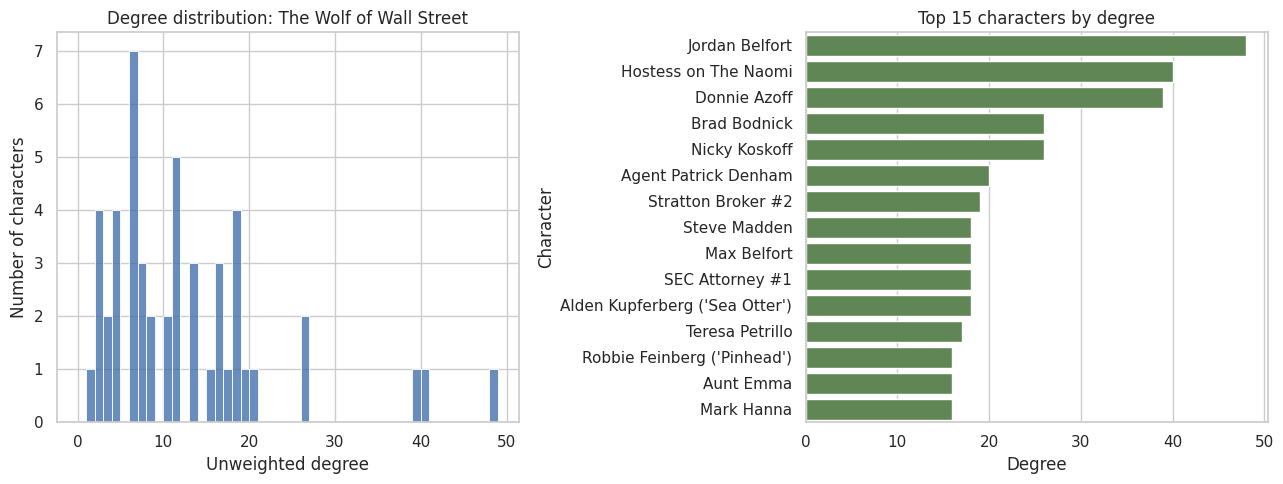

Saved figure: exports/figures/a1_1_degree_distribution.png
Highest-degree character: Jordan Belfort with degree 48.
Top character share of total degree: 8.08%


In [3]:
G = selected_graph
movie_title = G.graph.get("movie_name", SELECTED_MOVIE_ID).strip()

degree_df = pd.DataFrame({
    "character": list(G.nodes()),
    "degree": [G.degree(n) for n in G.nodes()],
    "weighted_degree": [G.degree(n, weight="weight") for n in G.nodes()],
}).sort_values(["degree", "weighted_degree"], ascending=False).reset_index(drop=True)

display(degree_df.head(15))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(degree_df["degree"], bins=range(0, int(degree_df["degree"].max()) + 2), ax=axes[0], color="#3769a8")
axes[0].set_title(f"Degree distribution: {movie_title}")
axes[0].set_xlabel("Unweighted degree")
axes[0].set_ylabel("Number of characters")

plot_df = degree_df.sort_values("degree", ascending=False).head(15)
sns.barplot(data=plot_df, y="character", x="degree", ax=axes[1], color="#5b8e4d")
axes[1].set_title("Top 15 characters by degree")
axes[1].set_xlabel("Degree")
axes[1].set_ylabel("Character")
fig_path_a11 = save_current_figure("a1_1_degree_distribution.png")
plt.show()

centralization_ratio = degree_df.loc[0, "degree"] / degree_df["degree"].sum()
print(f"Saved figure: {fig_path_a11.relative_to(PROJECT_ROOT)}")
print(f"Highest-degree character: {degree_df.loc[0, 'character']} with degree {degree_df.loc[0, 'degree']}.")
print(f"Top character share of total degree: {centralization_ratio:.2%}")


**Interpretation.** The degree table and plot show how concentrated the selected movie network is. A long right tail means a few characters have many more distinct interactions than most others. In this graph, the top-ranked character has a much higher degree than ordinary minor characters, which fits a movie centered around Jordan Belfort and his close business/social circle.

### How I solved this task

I loaded `moviedynamics/2013_The_Wolf_of_Wall_Street.json` from the Movie Dynamics ZIP, converted it with NetworkX's node-link reader, calculated each character's degree and weighted degree, and plotted both the overall distribution and the top characters. I used ordinary degree for the distribution because the requirement asks for vertex degree and because it is easy to interpret as the number of distinct character contacts.

**Limitations.** Degree does not know when interactions happen in the film and does not distinguish short scenes from long scenes unless the weighted degree is also inspected. It also does not show whether a character connects otherwise separate groups.


## A1.2 Graph Embeddings of Movie Networks

**Requirement.** Load multiple movie/show networks, create one vector per graph, reduce those vectors to 2D, visualize them as points, and identify interesting clusters or pairs.

**Method.** The selected manual method is **basic graph-level feature vectors + PCA**. For each movie graph I calculate interpretable structural features: node count, edge count, density, average clustering, degree mean/std/max, weighted degree mean/max, component count, largest component share, and average shortest path on the largest component when feasible. Then I standardize the feature table and use PCA to project it into two dimensions.

**Why this method.** This method is transparent. Each coordinate is produced from structural summaries that can be explained, unlike a more complex embedding model where the dimensions are harder to interpret. PCA is useful here because it shows which movies have similar graph shapes without requiring a supervised label.


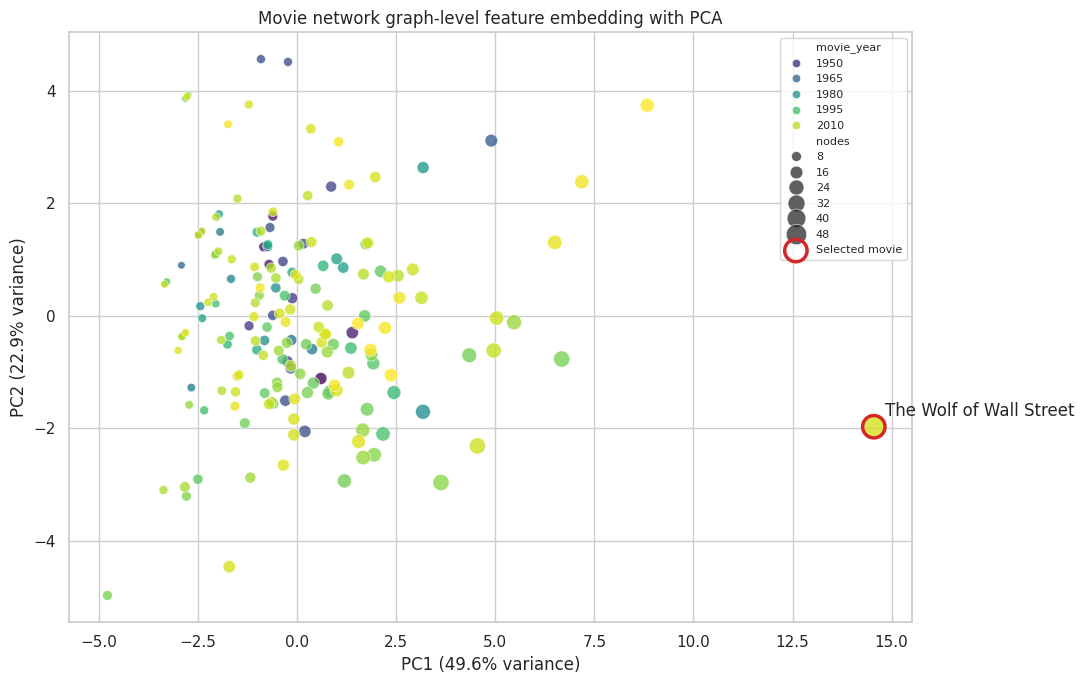

,movie_name,nodes,edges,density,average_clustering,degree_max,largest_component_share
0,The Wolf of Wall Street,49,297,0.252551,0.775281,48.0,1.0


,movie_name,movie_year,nodes,edges,density,average_clustering,distance_to_selected
0,The Wolf of Wall Street,2013,49,297,0.252551,0.775281,0.000000
77,Red Dragon,2002,29,140,0.344828,0.750904,7.967172
178,The Guernsey Literary and Potato Peel Pie Society,2018,21,125,0.595238,0.831259,8.086636
171,Miracles from Heaven,2016,21,122,0.580952,0.792715,8.559741
166,Our Brand Is Crisis,2015,22,107,0.463203,0.762408,8.694492
97,The Wind that Shakes the Barley,2006,24,113,0.409420,0.770553,9.267353
129,Tinker Tailor Soldier Spy,2011,25,116,0.386667,0.714271,9.689431
131,End of Watch,2012,22,84,0.363636,0.673157,9.712978
134,Mea Maxima Culpa: Silence in the House of God,2012,29,87,0.214286,0.579111,10.010682
68,I Am Sam,2001,23,79,0.312253,0.772866,10.288578


,PC1_loading,PC2_loading
degree_max,0.388879,-0.117547
edges,0.386966,-0.031852
degree_std,0.385652,-0.150633
degree_mean,0.373742,0.157113
nodes,0.371323,-0.219495
weighted_degree_max,0.348038,0.131255
weighted_degree_mean,0.283328,0.272935
average_clustering,0.189614,0.355451


Saved figure: exports/figures/a1_2_movie_graph_embedding.png
Feature cache: data/processed/part_a_movie_graph_features.parquet


In [4]:
def graph_feature_row(member_name: str) -> dict:
    graph = load_movie_graph(member_name)
    undirected = graph.to_undirected()
    n = graph.number_of_nodes()
    m = graph.number_of_edges()
    degrees = np.array([d for _, d in graph.degree()], dtype=float)
    weighted_degrees = np.array([d for _, d in graph.degree(weight="weight")], dtype=float)
    components = list(nx.connected_components(undirected)) if n else []
    largest_component_size = max((len(c) for c in components), default=0)
    largest_share = largest_component_size / n if n else 0
    largest_avg_path = np.nan
    if 1 < largest_component_size <= 300:
        sub = undirected.subgraph(max(components, key=len)).copy()
        largest_avg_path = nx.average_shortest_path_length(sub)
    return {
        "member": member_name,
        "movie_id": Path(member_name).stem,
        "movie_name": graph.graph.get("movie_name", Path(member_name).stem).strip(),
        "movie_year": graph.graph.get("movie_year"),
        "nodes": n,
        "edges": m,
        "density": nx.density(graph) if n > 1 else 0,
        "average_clustering": nx.average_clustering(undirected, weight=None) if n > 1 else 0,
        "degree_mean": float(degrees.mean()) if len(degrees) else 0,
        "degree_std": float(degrees.std()) if len(degrees) else 0,
        "degree_max": float(degrees.max()) if len(degrees) else 0,
        "weighted_degree_mean": float(weighted_degrees.mean()) if len(weighted_degrees) else 0,
        "weighted_degree_max": float(weighted_degrees.max()) if len(weighted_degrees) else 0,
        "component_count": len(components),
        "largest_component_share": largest_share,
        "largest_component_avg_path": largest_avg_path,
    }

# Use a deterministic sample across the archive so the embedding is broad but quick to rerun.
embedding_cache = DATA_PROCESSED / "part_a_movie_graph_features.parquet"
if embedding_cache.exists():
    feature_df = pd.read_parquet(embedding_cache)
else:
    with zipfile.ZipFile(MOVIE_ZIP) as zf:
        all_members = sorted(n for n in zf.namelist() if n.endswith(".json") and not n.endswith(".actors.json"))
    rng = np.random.default_rng(RANDOM_SEED)
    sample_size = min(180, len(all_members))
    sampled_members = sorted(rng.choice(all_members, size=sample_size, replace=False).tolist())
    if SELECTED_MOVIE_MEMBER not in sampled_members:
        sampled_members[0] = SELECTED_MOVIE_MEMBER
    rows = [graph_feature_row(member) for member in sampled_members]
    feature_df = pd.DataFrame(rows)
    feature_df.to_parquet(embedding_cache, index=False)

feature_columns = [
    "nodes", "edges", "density", "average_clustering", "degree_mean", "degree_std", "degree_max",
    "weighted_degree_mean", "weighted_degree_max", "component_count", "largest_component_share", "largest_component_avg_path",
]
features_for_pca = feature_df[feature_columns].copy()
features_for_pca = features_for_pca.fillna(features_for_pca.median(numeric_only=True))
scaled_features = StandardScaler().fit_transform(features_for_pca)
pca = PCA(n_components=2, random_state=RANDOM_SEED)
coords = pca.fit_transform(scaled_features)
embedding_df = feature_df.copy()
embedding_df["PC1"] = coords[:, 0]
embedding_df["PC2"] = coords[:, 1]
embedding_df["is_selected_movie"] = embedding_df["member"].eq(SELECTED_MOVIE_MEMBER)

fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(data=embedding_df, x="PC1", y="PC2", size="nodes", hue="movie_year", palette="viridis", sizes=(30, 220), alpha=0.78, ax=ax)
selected_row = embedding_df[embedding_df["is_selected_movie"]].iloc[0]
ax.scatter([selected_row["PC1"]], [selected_row["PC2"]], s=260, facecolors="none", edgecolors="#d62728", linewidths=2.5, label="Selected movie")
ax.annotate("The Wolf of Wall Street", (selected_row["PC1"], selected_row["PC2"]), xytext=(8, 8), textcoords="offset points")
ax.set_title("Movie network graph-level feature embedding with PCA")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.legend(loc="best", fontsize=8)
fig_path_a12 = save_current_figure("a1_2_movie_graph_embedding.png")
plt.show()

display(feature_df.loc[feature_df["member"].eq(SELECTED_MOVIE_MEMBER), ["movie_name", "nodes", "edges", "density", "average_clustering", "degree_max", "largest_component_share"]])
nearest = embedding_df.assign(
    distance_to_selected=np.sqrt((embedding_df["PC1"] - selected_row["PC1"])**2 + (embedding_df["PC2"] - selected_row["PC2"])**2)
).sort_values("distance_to_selected").head(10)
display(nearest[["movie_name", "movie_year", "nodes", "edges", "density", "average_clustering", "distance_to_selected"]])

loadings = pd.DataFrame(pca.components_.T, index=feature_columns, columns=["PC1_loading", "PC2_loading"])
display(loadings.sort_values("PC1_loading", key=abs, ascending=False).head(8))
print(f"Saved figure: {fig_path_a12.relative_to(PROJECT_ROOT)}")
print(f"Feature cache: {embedding_cache.relative_to(PROJECT_ROOT)}")


In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances

STRUCTURE_GROUP_COUNT = 4
kmeans = KMeans(n_clusters=STRUCTURE_GROUP_COUNT, random_state=RANDOM_SEED, n_init=20)
embedding_df["structure_group"] = kmeans.fit_predict(scaled_features)

cluster_centers = pd.DataFrame(kmeans.cluster_centers_, columns=feature_columns)
cluster_rows = []
for group_id, group in embedding_df.groupby("structure_group"):
    group_indices = group.index.to_numpy()
    center = kmeans.cluster_centers_[group_id]
    distances_to_center = np.linalg.norm(scaled_features[group_indices] - center, axis=1)
    representative = group.iloc[int(np.argmin(distances_to_center))]
    cluster_rows.append({
        "structure_group": int(group_id),
        "movies_in_group": int(len(group)),
        "representative_movie": representative["movie_name"],
        "mean_nodes": round(group["nodes"].mean(), 1),
        "mean_edges": round(group["edges"].mean(), 1),
        "mean_density": round(group["density"].mean(), 3),
        "mean_clustering": round(group["average_clustering"].mean(), 3),
        "mean_largest_component_share": round(group["largest_component_share"].mean(), 3),
        "example_movies": "; ".join(group.sort_values("nodes", ascending=False)["movie_name"].head(4).tolist()),
    })
cluster_summary = pd.DataFrame(cluster_rows).sort_values("structure_group")
display(cluster_summary)

selected_group = int(embedding_df.loc[embedding_df["is_selected_movie"], "structure_group"].iloc[0])
selected_group_movies = (
    embedding_df[embedding_df["structure_group"].eq(selected_group)]
    .assign(distance_to_selected=np.sqrt((embedding_df["PC1"] - selected_row["PC1"])**2 + (embedding_df["PC2"] - selected_row["PC2"])**2))
    .sort_values("distance_to_selected")
    [["movie_name", "movie_year", "nodes", "edges", "density", "average_clustering", "largest_component_share", "distance_to_selected"]]
    .head(8)
)
display(selected_group_movies)

pair_distances = pairwise_distances(scaled_features)
pair_rows = []
for i in range(len(embedding_df)):
    for j in range(i + 1, len(embedding_df)):
        pair_rows.append({
            "movie_a": embedding_df.iloc[i]["movie_name"],
            "movie_b": embedding_df.iloc[j]["movie_name"],
            "year_a": embedding_df.iloc[i]["movie_year"],
            "year_b": embedding_df.iloc[j]["movie_year"],
            "feature_distance": pair_distances[i, j],
            "nodes_a": embedding_df.iloc[i]["nodes"],
            "nodes_b": embedding_df.iloc[j]["nodes"],
            "edges_a": embedding_df.iloc[i]["edges"],
            "edges_b": embedding_df.iloc[j]["edges"],
            "density_a": embedding_df.iloc[i]["density"],
            "density_b": embedding_df.iloc[j]["density"],
            "clustering_a": embedding_df.iloc[i]["average_clustering"],
            "clustering_b": embedding_df.iloc[j]["average_clustering"],
        })
similar_pairs_df = pd.DataFrame(pair_rows).sort_values("feature_distance").head(8)
display(similar_pairs_df[[
    "movie_a", "movie_b", "year_a", "year_b", "feature_distance",
    "nodes_a", "nodes_b", "edges_a", "edges_b", "density_a", "density_b", "clustering_a", "clustering_b",
]])
print(f"Selected movie structure group: {selected_group}")

,structure_group,movies_in_group,representative_movie,mean_nodes,mean_edges,mean_density,mean_clustering,mean_largest_component_share,example_movies
0,0,87,ABBA: The Movie,6.8,12.0,0.571,0.561,1.000,Would You Rather; Miseria e nobiltà; Backlash;...
1,1,10,Our Brand Is Crisis,24.3,124.6,0.474,0.772,1.000,The Wolf of Wall Street; Red Dragon; Tinker Ta...
2,2,76,Sweet November,14.8,35.1,0.344,0.598,0.998,Mea Maxima Culpa: Silence in the House of God;...
3,3,7,Clubbed,9.3,9.3,0.240,0.259,0.602,Chilling Visions: 5 Senses of Fear; Clubbed; T...


,movie_name,movie_year,nodes,edges,density,average_clustering,largest_component_share,distance_to_selected
0,The Wolf of Wall Street,2013,49,297,0.252551,0.775281,1.0,0.000000
77,Red Dragon,2002,29,140,0.344828,0.750904,1.0,7.967172
178,The Guernsey Literary and Potato Peel Pie Society,2018,21,125,0.595238,0.831259,1.0,8.086636
171,Miracles from Heaven,2016,21,122,0.580952,0.792715,1.0,8.559741
166,Our Brand Is Crisis,2015,22,107,0.463203,0.762408,1.0,8.694492
97,The Wind that Shakes the Barley,2006,24,113,0.409420,0.770553,1.0,9.267353
129,Tinker Tailor Soldier Spy,2011,25,116,0.386667,0.714271,1.0,9.689431
131,End of Watch,2012,22,84,0.363636,0.673157,1.0,9.712978


,movie_a,movie_b,year_a,year_b,feature_distance,nodes_a,nodes_b,edges_a,edges_b,density_a,density_b,clustering_a,clustering_b
9583,An American Rhapsody,Requiem,2001,2006,0.007330,4,4,3,3,0.500000,0.500000,0.000000,0.000000
12481,Requiem,The Clink of Ice,2006,2010,0.014661,4,4,3,3,0.500000,0.500000,0.000000,0.000000
3619,Bob Dylan: Dont Look Back,Loving Annabelle,1967,2006,0.018344,5,5,6,6,0.600000,0.600000,0.600000,0.600000
9610,An American Rhapsody,The Clink of Ice,2001,2010,0.021991,4,4,3,3,0.500000,0.500000,0.000000,0.000000
4902,Horror of the Zombies,Harlock: Space Pirate,1974,2013,0.023820,4,4,4,4,0.666667,0.666667,0.583333,0.583333
3776,MaratSade,Loving Annabelle,1967,2006,0.047892,5,5,6,6,0.600000,0.600000,0.600000,0.600000
3549,Bob Dylan: Dont Look Back,MaratSade,1967,1967,0.052084,5,5,6,6,0.600000,0.600000,0.600000,0.600000
12194,Dans Paris,Loving Annabelle,2006,2006,0.052540,5,5,6,6,0.600000,0.600000,0.600000,0.600000


Selected movie structure group: 1


**Interpretation.** Points close together have similar graph summaries, not necessarily similar genres or plots. The nearest-neighbor table lists movie networks that are structurally close to the selected movie under these features. The PCA loading table shows which features most influenced the first two axes, so I can tell whether the visualization is mainly separating large dense graphs, sparse graphs, fragmented graphs, or graphs with strong clustering.

The extra grouping table answers the cluster/pair part of the task directly. I used four k-means groups on the same standardized graph-level features used for PCA. In this run, *The Wolf of Wall Street* is in structure group `1`. That group is the large, dense, highly clustered group: it has about 24 nodes and 125 edges on average, density around 0.47, clustering around 0.77, and a largest-component share of 1.0. I interpret this as an ensemble-style story-network group where most characters belong to one connected interaction core.

Interesting groups from the sampled movie networks:

- **Group 1:** larger connected ensemble networks. This is where *The Wolf of Wall Street*, *Red Dragon*, *Tinker Tailor Soldier Spy*, *Our Brand Is Crisis*, and similar networks appear. They are similar structurally because they have many edges, high clustering, and one main connected component.
- **Group 0:** small but dense connected networks. These usually have only a few characters, but many of the possible ties among them are present.
- **Group 2:** medium-sized connected networks with lower density than group 1. These look like ordinary story graphs with a main component but less complete interaction among characters.
- **Group 3:** fragmented or sparse networks. The lower largest-component share means the interaction graph breaks into separate pieces instead of one clear story core.

Several similar pairs are visible in the nearest-pair table. For example, *An American Rhapsody* and *Requiem* are almost identical under this embedding because both have 4 nodes, 3 edges, density 0.50, and clustering 0.00. *Bob Dylan: Dont Look Back* and *Loving Annabelle* are also close because both have 5 nodes, 6 edges, density 0.60, and clustering 0.60. These are not plot claims; they are structural claims about the character-interaction graphs.

For *The Wolf of Wall Street*, the most interesting similar group is the selected-group table. *Red Dragon*, *The Guernsey Literary and Potato Peel Pie Society*, *Miracles from Heaven*, *Our Brand Is Crisis*, *The Wind that Shakes the Barley*, *Tinker Tailor Soldier Spy*, and *End of Watch* are nearby in the PCA space. They may be structurally similar because their networks are mostly connected, relatively clustered, and have enough edges to suggest a central cast or story group rather than many isolated two-character scenes.

### How I solved this task

I sampled 180 movie networks deterministically from the Movie Dynamics archive, made one row of structural features per graph, standardized the columns, and used PCA to reduce the feature vectors to two dimensions. I highlighted `The Wolf of Wall Street`, printed its closest graph points in PCA space, clustered all sampled networks into four structural groups, and printed the closest movie pairs by standardized feature distance.

**Limitations.** This embedding captures graph shape only. It ignores character names, plot content, genre, scene order, and dialogue. PCA is also linear, and k-means assumes roughly compact groups, so curved or overlapping structural similarities may not appear cleanly in two dimensions.

## A2 Top-12 Character Subgraph with PageRank

**Requirement.** Use the selected centrality algorithm to rank characters, select the top 12, create the induced subgraph, draw it in a circular layout, and explain why that centrality method was selected.

**Method.** The selected method is **PageRank**. I compute weighted PageRank on the selected undirected graph. In an undirected graph, PageRank behaves like a prestige score where a character receives more importance from being connected to other important characters, and edge weights allow stronger interactions to contribute more.

**Why this method.** PageRank is appropriate because a movie character can matter through direct interactions and through ties to already important characters. It is more informative than degree alone when a character is connected to a central part of the story network.


,character,pagerank,degree,weighted_degree
0,Jordan Belfort,0.239908,48,2261
1,Donnie Azoff,0.100026,39,987
2,Hostess on The Naomi,0.088716,40,860
3,Steve Madden,0.038356,18,380
4,Brad Bodnick,0.032348,26,302
5,Nicky Koskoff,0.027349,26,237
6,Max Belfort,0.025248,18,219
7,Stratton Broker #2,0.024350,19,225
8,SEC Attorney #1,0.020379,18,182
9,Agent Patrick Denham,0.020208,20,175


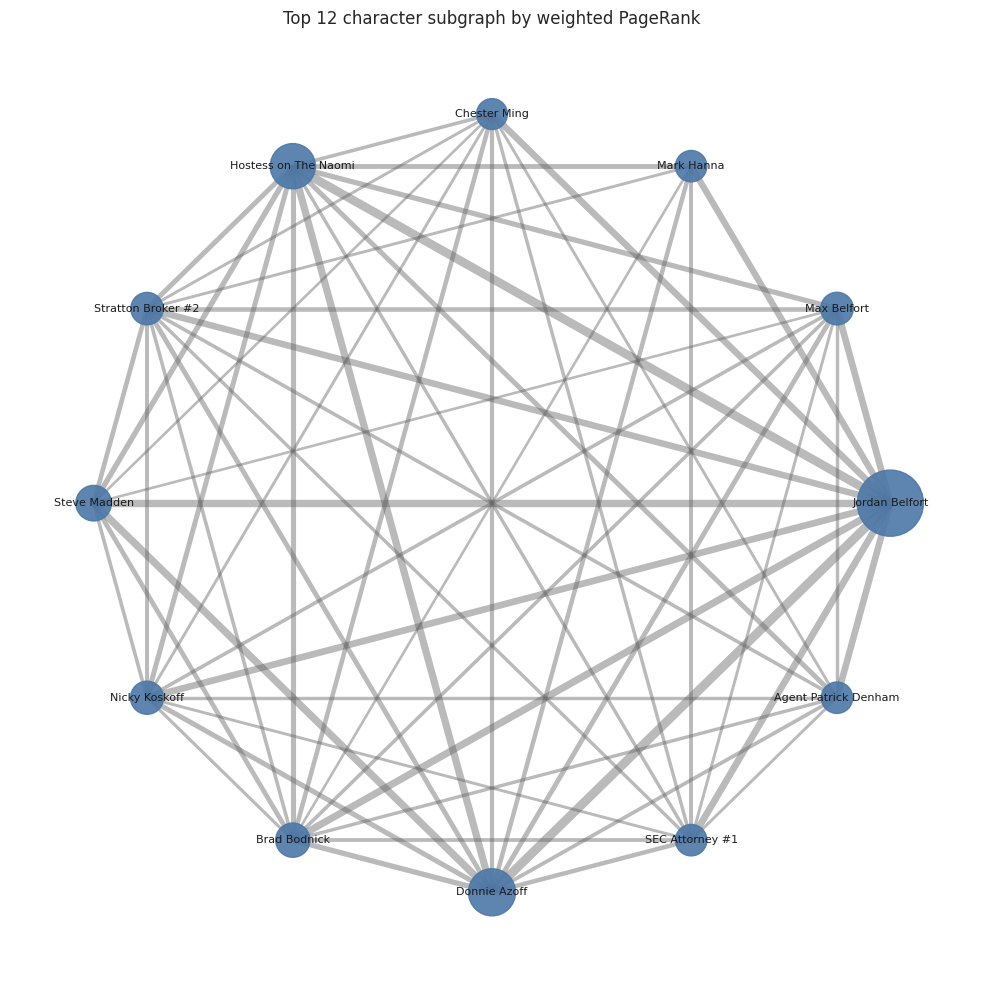

Top-12 subgraph nodes: 12, edges: 58
Saved figure: exports/figures/a2_top12_pagerank_subgraph.png


In [6]:
pagerank = nx.pagerank(G, weight="weight")
centrality_df = pd.DataFrame({
    "character": list(pagerank.keys()),
    "pagerank": list(pagerank.values()),
    "degree": [G.degree(n) for n in pagerank.keys()],
    "weighted_degree": [G.degree(n, weight="weight") for n in pagerank.keys()],
}).sort_values("pagerank", ascending=False).reset_index(drop=True)

top12_characters = centrality_df.head(12)["character"].tolist()
top12_subgraph = G.subgraph(top12_characters).copy()

display(centrality_df.head(12))

pos = nx.circular_layout(top12_subgraph)
node_sizes = [8000 * pagerank[node] + 350 for node in top12_subgraph.nodes()]
edge_widths = [0.5 + math.log1p(top12_subgraph[u][v].get("weight", 1)) for u, v in top12_subgraph.edges()]
plt.figure(figsize=(10, 10))
nx.draw_networkx_edges(top12_subgraph, pos, width=edge_widths, alpha=0.45, edge_color="#666666")
nx.draw_networkx_nodes(top12_subgraph, pos, node_size=node_sizes, node_color="#4c78a8", alpha=0.9)
nx.draw_networkx_labels(top12_subgraph, pos, font_size=8)
plt.title("Top 12 character subgraph by weighted PageRank")
plt.axis("off")
fig_path_a2 = save_current_figure("a2_top12_pagerank_subgraph.png")
plt.show()
print(f"Top-12 subgraph nodes: {top12_subgraph.number_of_nodes()}, edges: {top12_subgraph.number_of_edges()}")
print(f"Saved figure: {fig_path_a2.relative_to(PROJECT_ROOT)}")


**Interpretation.** The top-12 subgraph keeps only the most PageRank-central characters and the interactions among them. If many edges remain inside the induced subgraph, the main characters form a closely connected story core. If some top characters have fewer ties inside this view, their PageRank may be coming from strong weighted interactions or from bridging to important characters outside the top 12.

### How I solved this task

I ran NetworkX weighted PageRank on the selected movie graph, sorted the characters, selected the first 12, and drew the induced subgraph using a circular layout. I scaled node sizes by PageRank and edge widths by the log of interaction weight so that strong ties remain visible without making the drawing unreadable.

**Limitations.** PageRank depends on the interaction weights from the dataset. If the weight does not perfectly represent narrative importance, the ranking can overvalue long or repeated interactions that are not central to the plot.


## A3 PageRank, Triangles, and Average Shortest Paths

**Requirement.** For every vertex in the selected graph, compute PageRank, the number of triangles, and average shortest path length. If the graph is directed, explain the conversion decision.

**Method.** The selected Movie Dynamics graph is undirected, so no directed conversion is needed. PageRank uses edge weights. Triangle counts use the undirected graph and count how many closed three-character interaction patterns include each character. Average shortest path length is calculated from each character to all reachable characters in its connected component.

**Why this method.** These three measures describe different roles: PageRank captures global importance, triangles capture local clustering, and average shortest path length captures how close a character is to the rest of the reachable graph.


,character,pagerank,triangles,avg_shortest_path_to_reachable,degree,weighted_degree,component_id
0,Jordan Belfort,0.239908,249,1.000000,48,2261,0
1,Donnie Azoff,0.100026,226,1.187500,39,987,0
2,Hostess on The Naomi,0.088716,236,1.166667,40,860,0
3,Steve Madden,0.038356,94,1.625000,18,380,0
4,Brad Bodnick,0.032348,157,1.458333,26,302,0
5,Nicky Koskoff,0.027349,143,1.458333,26,237,0
6,Max Belfort,0.025248,87,1.625000,18,219,0
7,Stratton Broker #2,0.024350,118,1.604167,19,225,0
8,SEC Attorney #1,0.020379,103,1.625000,18,182,0
9,Agent Patrick Denham,0.020208,111,1.583333,20,175,0


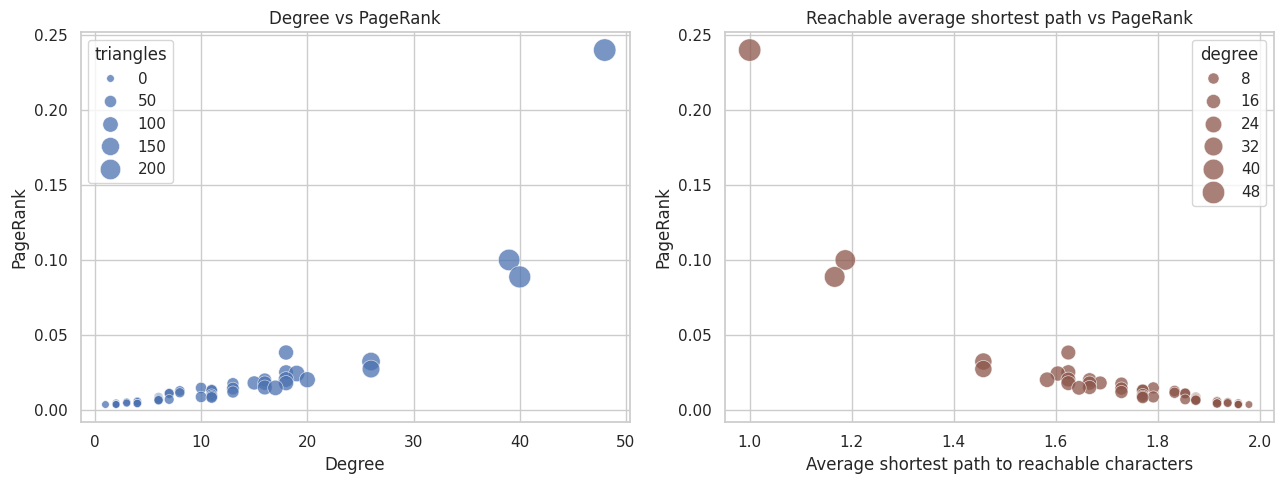

Graph directed? False
Connected components: 1
Saved figure: exports/figures/a3_pagerank_triangles_shortest_paths.png


In [7]:
triangles = nx.triangles(G)
component_lookup = {}
for component_id, component_nodes in enumerate(nx.connected_components(G)):
    for node in component_nodes:
        component_lookup[node] = component_id

avg_shortest_paths = {}
for component_nodes in nx.connected_components(G):
    sub = G.subgraph(component_nodes)
    if sub.number_of_nodes() == 1:
        only_node = next(iter(sub.nodes()))
        avg_shortest_paths[only_node] = 0.0
    else:
        lengths = dict(nx.all_pairs_shortest_path_length(sub))
        for node, node_lengths in lengths.items():
            avg_shortest_paths[node] = np.mean([dist for other, dist in node_lengths.items() if other != node])

a3_df = pd.DataFrame({
    "character": list(G.nodes()),
    "pagerank": [pagerank[n] for n in G.nodes()],
    "triangles": [triangles[n] for n in G.nodes()],
    "avg_shortest_path_to_reachable": [avg_shortest_paths[n] for n in G.nodes()],
    "degree": [G.degree(n) for n in G.nodes()],
    "weighted_degree": [G.degree(n, weight="weight") for n in G.nodes()],
    "component_id": [component_lookup[n] for n in G.nodes()],
}).sort_values(["pagerank", "triangles"], ascending=False).reset_index(drop=True)

display(a3_df.head(20))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=a3_df, x="degree", y="pagerank", size="triangles", sizes=(30, 260), alpha=0.75, ax=axes[0])
axes[0].set_title("Degree vs PageRank")
axes[0].set_xlabel("Degree")
axes[0].set_ylabel("PageRank")
sns.scatterplot(data=a3_df, x="avg_shortest_path_to_reachable", y="pagerank", size="degree", sizes=(30, 260), alpha=0.75, ax=axes[1], color="#8c564b")
axes[1].set_title("Reachable average shortest path vs PageRank")
axes[1].set_xlabel("Average shortest path to reachable characters")
axes[1].set_ylabel("PageRank")
fig_path_a3 = save_current_figure("a3_pagerank_triangles_shortest_paths.png")
plt.show()

print(f"Graph directed? {G.is_directed()}")
print(f"Connected components: {nx.number_connected_components(G)}")
print(f"Saved figure: {fig_path_a3.relative_to(PROJECT_ROOT)}")


**Interpretation.** High PageRank and short average paths usually indicate a character near the center of the interaction network. Triangle counts identify characters embedded in groups where their neighbors also interact with each other. The table sorted by PageRank makes it possible to compare global importance with local group structure.

### How I solved this task

I reused the weighted PageRank scores from A2, computed triangle counts with `nx.triangles`, and calculated average shortest path length within each connected component. For isolated vertices the value is `0.0`; for disconnected graphs I do not average over unreachable vertices because there is no finite path to them.

**Limitations.** Shortest paths are based on unweighted graph distance, not scene duration or interaction strength. This is acceptable for a medium movie graph, but it simplifies the meaning of social distance.


## A4 Cytoscape and Gephi Exports

**Requirement.** Export the selected network to Cytoscape-compatible and Gephi-compatible formats, make vertex size correlate with degree, and include the Cytoscape and Gephi screenshots and explain the manual styling choices.

**Method.** I export the selected movie graph with node attributes for label, degree, weighted degree, PageRank, triangles, and `viz_size`. Cytoscape can read GraphML and Gephi can read GEXF. The `viz_size` attribute is calculated from degree so both tools can map node size consistently.

**Why this method.** GraphML and GEXF preserve node and edge attributes better than a plain edge list. That makes manual GUI styling easier and avoids recalculating centrality inside the visualization tools.


In [8]:
export_graph = add_export_attributes(G)
cytoscape_movie_path = CYTOSCAPE_DIR / "wolf_of_wall_street_character_network.graphml"
gephi_movie_path = GEPHI_DIR / "wolf_of_wall_street_character_network.gexf"
nx.write_graphml(export_graph, cytoscape_movie_path)
nx.write_gexf(export_graph, gephi_movie_path)

export_summary = pd.DataFrame([
    {"tool": "Cytoscape", "file": str(cytoscape_movie_path.relative_to(PROJECT_ROOT)), "format": "GraphML", "nodes": export_graph.number_of_nodes(), "edges": export_graph.number_of_edges()},
    {"tool": "Gephi", "file": str(gephi_movie_path.relative_to(PROJECT_ROOT)), "format": "GEXF", "nodes": export_graph.number_of_nodes(), "edges": export_graph.number_of_edges()},
])
display(export_summary)
print("Node attributes exported:", sorted(next(iter(export_graph.nodes(data=True)))[1].keys()))


,tool,file,format,nodes,edges
0,Cytoscape,exports/cytoscape/wolf_of_wall_street_characte...,GraphML,49,297
1,Gephi,exports/gephi/wolf_of_wall_street_character_ne...,GEXF,49,297


Node attributes exported: ['degree', 'first', 'label', 'last', 'pagerank', 'role', 'triangles', 'viz_size', 'weighted_degree']


### Cytoscape screenshot: Wolf of Wall Street character network

![Cytoscape visualization of the Wolf of Wall Street character network](../exports/figures/cytoscape_wolf_of_wall_street_character_relations.png)

This Cytoscape view emphasizes the selected movie's character interaction structure. Larger nodes represent higher degree, so the most connected characters stand out visually, while the edge layout shows how the main story group is surrounded by smaller local interaction groups.

Suggested Cytoscape styling used for this screenshot:

1. Import the GraphML file as a network.
2. Set node label to `label`.
3. Map node size to `viz_size` or `degree`.
4. Map node color to `pagerank` using a sequential color scale.
5. Map edge width to `weight`.
6. Use a force-directed layout, then manually move labels if needed.

### Gephi screenshot: Wolf of Wall Street character network

![Gephi visualization of the Wolf of Wall Street character network](../exports/figures/gephi_wolf_of_wall_street_character_relations.png)

This Gephi view provides a second layout of the same exported graph. The visualization makes the dense central component visible and helps compare whether the same high-degree/PageRank characters remain prominent when a different graph layout tool is used.

Suggested Gephi styling used for this screenshot:

1. Open the GEXF file in Gephi.
2. Use ForceAtlas2 or Fruchterman-Reingold layout.
3. Rank node size by `degree` or `viz_size`.
4. Color nodes by `pagerank` or `triangles`.
5. Rank edge thickness by `weight`.
6. Enable labels and adjust label size so character names remain readable.

**Interpretation.** These exports contain the same selected graph used in A1-A3, but with extra attributes for GUI visualization. The screenshots show that the selected movie network has a visible central group, with the largest nodes acting as the main interaction anchors.

### How I solved this task

I copied the selected movie graph, added degree-based visualization attributes, PageRank, triangles, labels, and edge weights, then exported GraphML for Cytoscape and GEXF for Gephi. The size field is based on degree because the requirement asks for vertex size to correlate with degree. After creating the exports, I inserted the manually created Cytoscape and Gephi screenshots into this notebook.

**Limitations.** Cytoscape and Gephi layouts are partly manual and can change with styling choices. The screenshots document one readable layout rather than a unique mathematical result.


## A5 Ego Network Function

**Requirement.** Write a function that receives a selected vertex and creates a subgraph containing the selected vertex, all incoming neighbors, and all outgoing neighbors. Then draw it, calculate its number of vertices and edges, and explain what it reveals.

**Method.** The selected graph is undirected, so incoming and outgoing neighbors are the same set. I still write the function so it works for directed graphs: for directed graphs it combines predecessors and successors; for undirected graphs it uses ordinary neighbors.

**Why this method.** An ego network focuses on the local neighborhood of one character. I selected Jordan Belfort because he is the main character, so this view shows the characters directly attached to him and the ties among those neighbors.


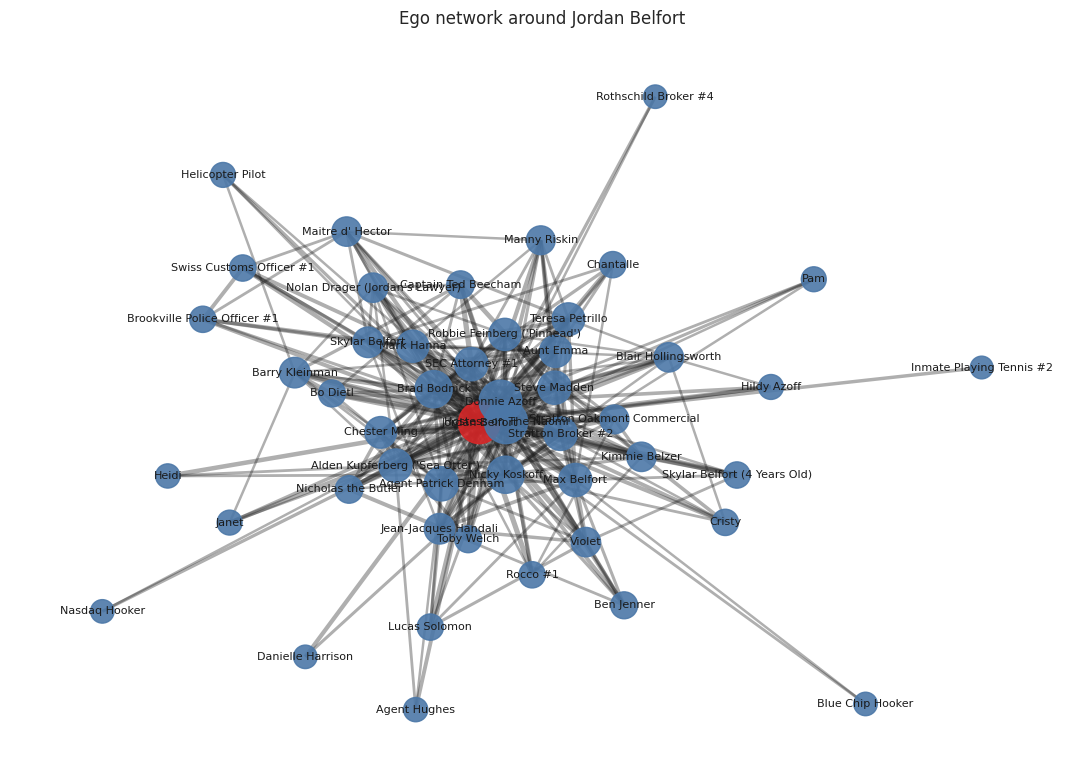

,selected_vertex,ego_nodes,ego_edges,selected_vertex_degree_in_full_graph,selected_vertex_weighted_degree
0,Jordan Belfort,49,297,48,2261


,neighbor,degree_inside_ego,weighted_degree_inside_ego
2,Donnie Azoff,39,987
1,Hostess on The Naomi,40,860
26,Steve Madden,18,380
4,Brad Bodnick,26,302
22,Nicky Koskoff,26,237
18,Stratton Broker #2,19,225
20,Max Belfort,18,219
8,SEC Attorney #1,18,182
19,Agent Patrick Denham,20,175
9,Mark Hanna,16,167


Saved figure: exports/figures/a5_jordan_belfort_ego_network.png


In [9]:
def ego_network_in_out(graph: nx.Graph, vertex: str) -> nx.Graph:
    if vertex not in graph:
        lowered = {str(node).lower(): node for node in graph.nodes()}
        matches = [node for node in graph.nodes() if str(vertex).lower() in str(node).lower() or str(node).lower() in str(vertex).lower()]
        if matches:
            vertex = matches[0]
        elif str(vertex).lower() in lowered:
            vertex = lowered[str(vertex).lower()]
        else:
            raise ValueError(f"Vertex {vertex!r} was not found. Example nodes: {list(graph.nodes())[:10]}")
    if graph.is_directed():
        neighbors = set(graph.predecessors(vertex)) | set(graph.successors(vertex))
    else:
        neighbors = set(graph.neighbors(vertex))
    return graph.subgraph({vertex, *neighbors}).copy()

selected_vertex = "Jordan Belfort"
ego = ego_network_in_out(G, selected_vertex)
weighted_ego_degree = dict(ego.degree(weight="weight"))

plt.figure(figsize=(11, 8))
pos = nx.spring_layout(ego, seed=RANDOM_SEED, weight="weight", k=0.7)
node_colors = ["#d62728" if node == selected_vertex else "#4c78a8" for node in ego.nodes()]
node_sizes = [900 if node == selected_vertex else 250 + 18 * ego.degree(node) for node in ego.nodes()]
edge_widths = [0.4 + math.log1p(ego[u][v].get("weight", 1)) for u, v in ego.edges()]
nx.draw_networkx_edges(ego, pos, width=edge_widths, alpha=0.35)
nx.draw_networkx_nodes(ego, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(ego, pos, font_size=8)
plt.title(f"Ego network around {selected_vertex}")
plt.axis("off")
fig_path_a5 = save_current_figure("a5_jordan_belfort_ego_network.png")
plt.show()

ego_summary = pd.DataFrame([
    {"selected_vertex": selected_vertex, "ego_nodes": ego.number_of_nodes(), "ego_edges": ego.number_of_edges(), "selected_vertex_degree_in_full_graph": G.degree(selected_vertex), "selected_vertex_weighted_degree": G.degree(selected_vertex, weight="weight")}
])
display(ego_summary)

ego_neighbor_table = pd.DataFrame({
    "neighbor": [node for node in ego.nodes() if node != selected_vertex],
    "degree_inside_ego": [ego.degree(node) for node in ego.nodes() if node != selected_vertex],
    "weighted_degree_inside_ego": [weighted_ego_degree[node] for node in ego.nodes() if node != selected_vertex],
}).sort_values(["weighted_degree_inside_ego", "degree_inside_ego"], ascending=False)
display(ego_neighbor_table.head(20))
print(f"Saved figure: {fig_path_a5.relative_to(PROJECT_ROOT)}")


**Interpretation.** Jordan Belfort's ego network contains his direct interaction partners and the edges among those partners. A dense ego network would mean many of his contacts also interact with each other; a sparse ego network would mean he connects otherwise separate parts of the story. The neighbor table helps identify which direct contacts have the strongest presence inside this local neighborhood.

### How I solved this task

I wrote `ego_network_in_out`, which handles directed graphs by combining predecessors and successors and handles this undirected movie graph by using ordinary neighbors. Then I drew Jordan Belfort's ego graph, counted its nodes and edges, and ranked neighbors by weighted degree inside the ego network.

**Limitations.** Because this graph is undirected, incoming and outgoing neighbors cannot be distinguished. The ego network also only shows one-hop contacts, so it hides characters that are important through two-step paths.


## A6 Large Chess Network Analysis

**Requirement.** Use the Free Internet Chess Server network, find the top 10 most central players, visualize a meaningful part of the network, and explain how the large network size was handled.

**Method.** The chess archive contains a very large interactions CSV. I do **not** load the full graph into NetworkX. Instead, I stream a limited number of interaction rows from the compressed archive, count how often each player appears as a source or destination, and use that interaction count as a scalable degree-like centrality approximation. Then I build a small visualization subgraph using the top sampled players and a limited number of their sampled neighbors.

**Why this method.** The assignment explicitly warns that the FICS graph is too large for a full NetworkX load. Counting endpoints in streamed edges is memory-safe and gives a reasonable approximation of highly active or central players in the sampled interaction data.


,player,sampled_interaction_count
0,FriarTuck,6830
1,Wronskian,6032
2,mscp,4098
3,secone,2688
4,stupido,1566
5,Urania,1510
6,pkch,1370
7,blindfolded,1330
8,JagorCrafty,1296
9,hdyl,1178


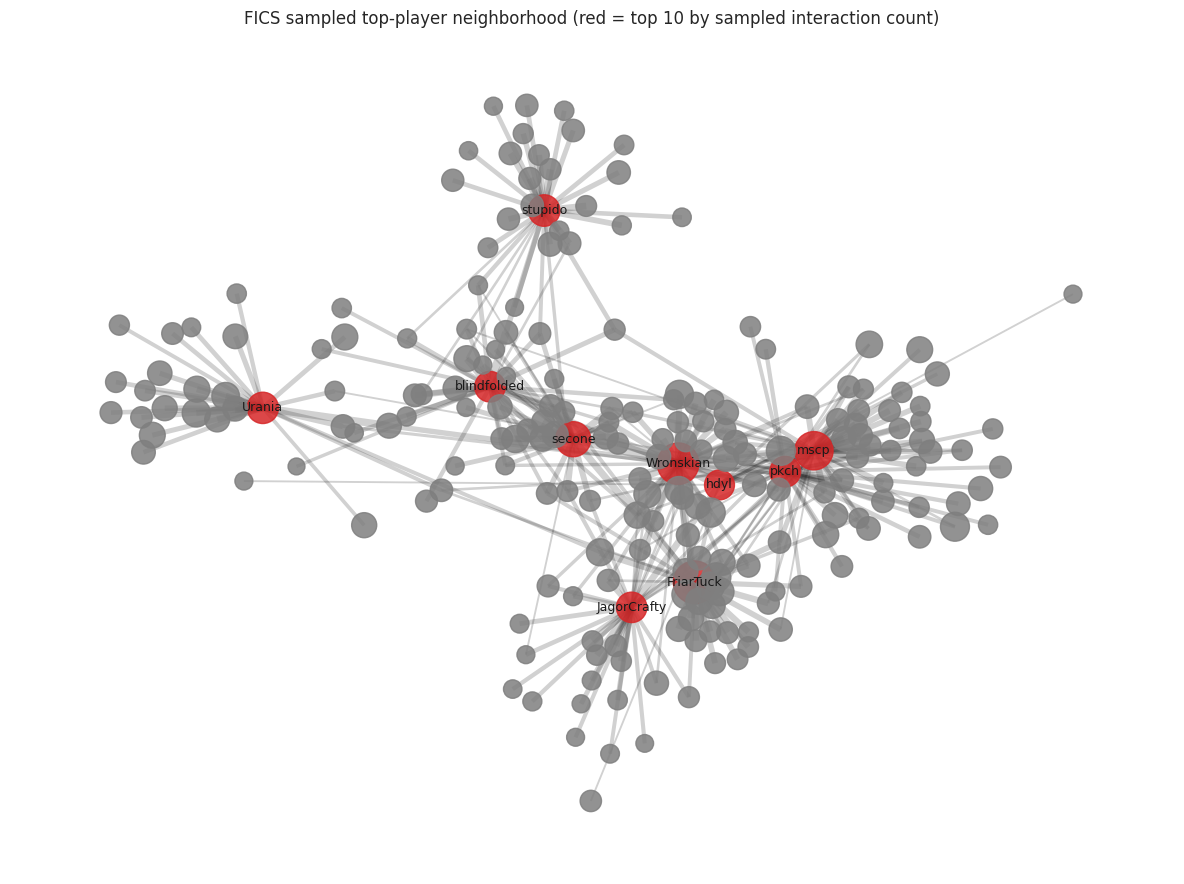

Chess cache status: loaded existing cache
Rows analyzed: 200,000
Sample visualization graph: 214 nodes, 314 edges
Saved figure: exports/figures/a6_fics_sampled_top_players.png
Exported sampled chess GraphML: exports/cytoscape/fics_sampled_top_players.graphml
Exported sampled chess GEXF: exports/gephi/fics_sampled_top_players.gexf


In [10]:
CHESS_SAMPLE_ROWS = 200_000
CHESS_NEIGHBORS_PER_TOP_PLAYER = 25
chess_edges_cache = DATA_PROCESSED / f"fics_interactions_first_{CHESS_SAMPLE_ROWS}.parquet"


def stream_chess_interactions_sample(max_rows: int) -> pd.DataFrame:
    rows = []
    with tarfile.open(CHESS_ARCHIVE, "r:gz") as tar:
        member = tar.getmember("./FCIS/fcis_chess.interactions.csv")
        file_obj = tar.extractfile(member)
        text = io.TextIOWrapper(file_obj, encoding="utf-8", newline="")
        reader = csv.DictReader(text)
        for idx, row in enumerate(reader):
            if idx >= max_rows:
                break
            rows.append({"datetime": row["datetime"], "src_id": row["src_id"], "dst_id": row["dst_id"]})
    return pd.DataFrame(rows)

if chess_edges_cache.exists():
    chess_edges = pd.read_parquet(chess_edges_cache)
    cache_status = "loaded existing cache"
else:
    chess_edges = stream_chess_interactions_sample(CHESS_SAMPLE_ROWS)
    chess_edges.to_parquet(chess_edges_cache, index=False)
    cache_status = "created cache from streamed tar.gz sample"

endpoint_counts = pd.concat([chess_edges["src_id"], chess_edges["dst_id"]]).value_counts()
top_chess_players = endpoint_counts.head(10).rename_axis("player").reset_index(name="sampled_interaction_count")
display(top_chess_players)

selected_players = set(top_chess_players["player"])
subgraph_edges = []
neighbor_counts = defaultdict(Counter)
for row in chess_edges.itertuples(index=False):
    src = row.src_id
    dst = row.dst_id
    if src in selected_players:
        neighbor_counts[src][dst] += 1
    if dst in selected_players:
        neighbor_counts[dst][src] += 1

allowed_nodes = set(selected_players)
for player, counts in neighbor_counts.items():
    for neighbor, _ in counts.most_common(CHESS_NEIGHBORS_PER_TOP_PLAYER):
        allowed_nodes.add(neighbor)

for (src, dst), weight in chess_edges.groupby(["src_id", "dst_id"]).size().items():
    if src in allowed_nodes and dst in allowed_nodes and (src in selected_players or dst in selected_players):
        subgraph_edges.append((src, dst, int(weight)))

chess_sample_graph = nx.Graph()
for src, dst, weight in subgraph_edges:
    if chess_sample_graph.has_edge(src, dst):
        chess_sample_graph[src][dst]["weight"] += weight
    else:
        chess_sample_graph.add_edge(src, dst, weight=weight)

for node in chess_sample_graph.nodes:
    chess_sample_graph.nodes[node]["sampled_interaction_count"] = int(endpoint_counts.get(node, 0))
    chess_sample_graph.nodes[node]["is_top10"] = node in selected_players

plt.figure(figsize=(12, 9))
pos = nx.spring_layout(chess_sample_graph, seed=RANDOM_SEED, k=0.45)
node_sizes = [120 + 10 * math.sqrt(chess_sample_graph.nodes[n].get("sampled_interaction_count", 1)) for n in chess_sample_graph.nodes]
node_colors = ["#d62728" if chess_sample_graph.nodes[n].get("is_top10") else "#7f7f7f" for n in chess_sample_graph.nodes]
edge_widths = [0.25 + math.log1p(data.get("weight", 1)) for _, _, data in chess_sample_graph.edges(data=True)]
nx.draw_networkx_edges(chess_sample_graph, pos, alpha=0.20, width=edge_widths)
nx.draw_networkx_nodes(chess_sample_graph, pos, node_size=node_sizes, node_color=node_colors, alpha=0.85)
labels = {node: node for node in selected_players if node in chess_sample_graph}
nx.draw_networkx_labels(chess_sample_graph, pos, labels=labels, font_size=9)
plt.title("FICS sampled top-player neighborhood (red = top 10 by sampled interaction count)")
plt.axis("off")
fig_path_a6 = save_current_figure("a6_fics_sampled_top_players.png")
plt.show()

chess_export_graph = add_export_attributes(chess_sample_graph)
chess_graphml_path = CYTOSCAPE_DIR / "fics_sampled_top_players.graphml"
chess_gexf_path = GEPHI_DIR / "fics_sampled_top_players.gexf"
nx.write_graphml(chess_export_graph, chess_graphml_path)
nx.write_gexf(chess_export_graph, chess_gexf_path)

print(f"Chess cache status: {cache_status}")
print(f"Rows analyzed: {len(chess_edges):,}")
print(f"Sample visualization graph: {chess_sample_graph.number_of_nodes()} nodes, {chess_sample_graph.number_of_edges()} edges")
print(f"Saved figure: {fig_path_a6.relative_to(PROJECT_ROOT)}")
print(f"Exported sampled chess GraphML: {chess_graphml_path.relative_to(PROJECT_ROOT)}")
print(f"Exported sampled chess GEXF: {chess_gexf_path.relative_to(PROJECT_ROOT)}")


**Interpretation.** The top-10 table ranks players by how often they appear in the sampled interaction rows. This is a degree-like activity measure, not exact full-graph centrality. The visualization shows the local sampled neighborhoods around those top players, with top players colored red.

### How I solved this task

I streamed the first 200,000 interaction rows from `./FCIS/fcis_chess.interactions.csv` inside `fics.tar.gz`, cached that sample under `data/processed/`, counted player appearances as source or destination, and visualized only the top sampled players plus up to 25 sampled neighbors per top player. I used NetworkX only after reducing the data to this small subgraph.

**Limitations and sampling choices.** This is not an exact analysis of the full FICS network. The sample is the first 200,000 rows in archive order, so it may reflect early time periods more than later ones. Exact betweenness or all-pairs shortest paths are intentionally avoided because the full graph is too large for this assignment environment.


## A7 Lord of the Rings Couples Cytoscape Export

**Requirement.** Export the Lord of the Rings couples network to Cytoscape, color vertices by gender, use vertex shapes for race, include the Cytoscape screenshot, and explain the visualization design choices.

**Method.** The local CSV has one row per character and a `spouse` field. I build an undirected couples graph where each edge connects a character to their listed spouse. Node attributes include `gender`, `race`, `cytoscape_color`, and `cytoscape_shape`. Cytoscape can then use these attributes for visual mapping.

**Why this method.** Couples are symmetric relationships for this task, so an undirected graph is the clearest representation. Color and shape use the exact manual selections: color for `gender`, shape for `race`.


,nodes,edges,removed_isolates,cytoscape_file,gephi_file
0,553,415,436,exports/cytoscape/lotr_couples_gender_race.gra...,exports/gephi/lotr_couples_gender_race.gexf


,name,spouse,gender,race
0,Adanel,Belemir,Female,Men
3,Tarcil,Unnamed wife,Male,Men
5,Ar-Adûnakhôr,Unnamed wife,Male,Men
7,Angrod,Eldalótë,Male,Elves
9,Anárion,Unnamed wife,Male,Men
10,Ar-Pharazôn,Tar-Míriel,Male,Men
11,Ar-Sakalthôr,Unnamed wife,Male,Men
12,Ar-Gimilzôr,Inzilbêth,Male,Men
13,Angelimir,Unnamed wife,Male,Men
21,Tarannon Falastur,Berúthiel,Male,Men


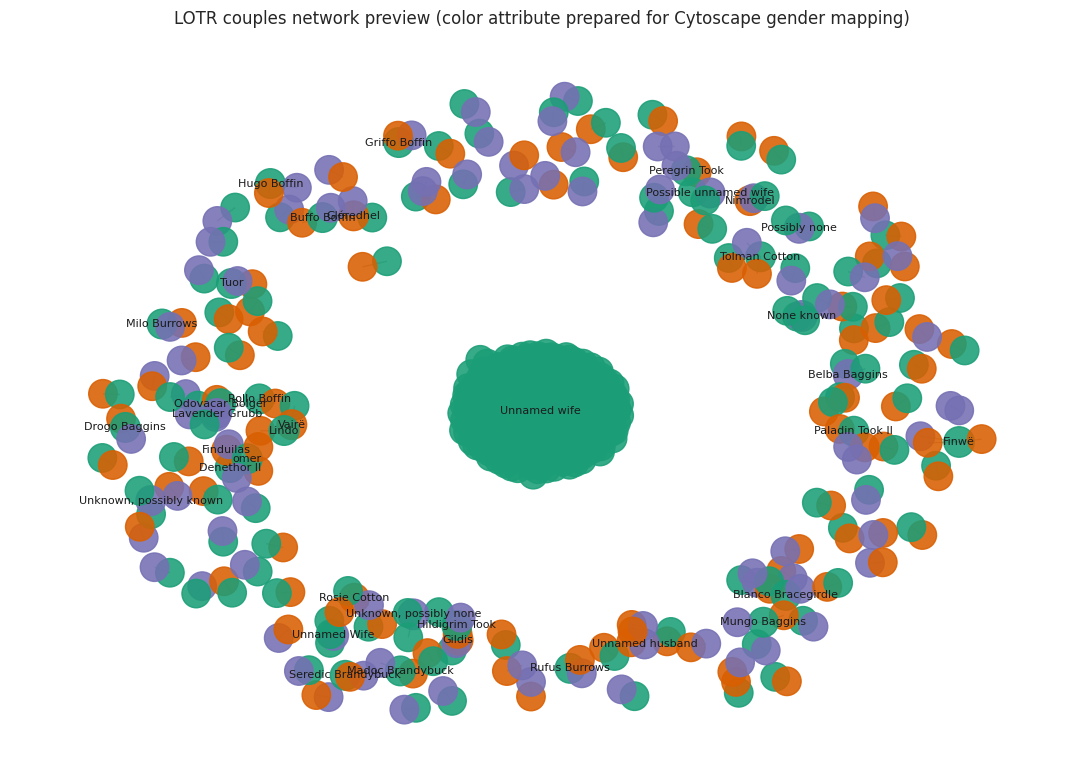

Saved preview figure: exports/figures/a7_lotr_couples_preview.png
Exported Cytoscape GraphML: exports/cytoscape/lotr_couples_gender_race.graphml
Exported Gephi GEXF: exports/gephi/lotr_couples_gender_race.gexf


In [11]:
lotr_df = pd.read_csv(LOTR_CSV)
lotr_df["name"] = lotr_df["name"].astype(str).str.strip()
lotr_df["spouse"] = lotr_df["spouse"].astype("string").str.strip()
lotr_df["gender"] = lotr_df["gender"].fillna("Unknown").astype(str).str.strip()
lotr_df["race"] = lotr_df["race"].fillna("Unknown").astype(str).str.strip()

attr_by_name = lotr_df.set_index("name")[["gender", "race"]].to_dict("index")
lotr_graph = nx.Graph()
for _, row in lotr_df.iterrows():
    name = row["name"]
    spouse = row["spouse"]
    if not name or name.lower() == "nan":
        continue
    lotr_graph.add_node(name, gender=row["gender"], race=row["race"], label=name)
    if pd.notna(spouse) and spouse and spouse.lower() not in {"nan", "none", "unknown"}:
        lotr_graph.add_node(spouse, label=spouse, **attr_by_name.get(spouse, {"gender": "Unknown", "race": "Unknown"}))
        if name != spouse:
            lotr_graph.add_edge(name, spouse, relationship="spouse")

# Keep the couples network: remove isolated characters without a spouse edge.
isolates = list(nx.isolates(lotr_graph))
lotr_graph.remove_nodes_from(isolates)

gender_colors = {
    "Female": "#d95f02",
    "Male": "#1b9e77",
    "Unknown": "#7570b3",
    "nan": "#7570b3",
}
race_shapes = {
    "Men": "ELLIPSE",
    "Elves": "DIAMOND",
    "Hobbits": "ROUND_RECTANGLE",
    "Dwarves": "RECTANGLE",
    "Ainur": "TRIANGLE",
    "Orcs": "HEXAGON",
    "Dragon": "OCTAGON",
    "Unknown": "ELLIPSE",
}
for node, data in lotr_graph.nodes(data=True):
    gender = data.get("gender", "Unknown")
    race = data.get("race", "Unknown")
    data["cytoscape_color"] = gender_colors.get(gender, gender_colors["Unknown"])
    data["cytoscape_shape"] = race_shapes.get(race, "ELLIPSE")
    data["degree"] = int(lotr_graph.degree(node))
    data["viz_size"] = 28 + 7 * math.sqrt(max(lotr_graph.degree(node), 1))

lotr_graphml_path = CYTOSCAPE_DIR / "lotr_couples_gender_race.graphml"
lotr_gexf_path = GEPHI_DIR / "lotr_couples_gender_race.gexf"
nx.write_graphml(lotr_graph, lotr_graphml_path)
nx.write_gexf(lotr_graph, lotr_gexf_path)

lotr_summary = pd.DataFrame([
    {"nodes": lotr_graph.number_of_nodes(), "edges": lotr_graph.number_of_edges(), "removed_isolates": len(isolates), "cytoscape_file": str(lotr_graphml_path.relative_to(PROJECT_ROOT)), "gephi_file": str(lotr_gexf_path.relative_to(PROJECT_ROOT))}
])
display(lotr_summary)
display(lotr_df[["name", "spouse", "gender", "race"]].dropna(subset=["spouse"]).head(15))

plt.figure(figsize=(11, 8))
pos = nx.spring_layout(lotr_graph, seed=RANDOM_SEED, k=0.8)
node_colors = [lotr_graph.nodes[n].get("cytoscape_color", "#7570b3") for n in lotr_graph.nodes]
node_sizes = [lotr_graph.nodes[n].get("viz_size", 30) * 12 for n in lotr_graph.nodes]
nx.draw_networkx_edges(lotr_graph, pos, alpha=0.35)
nx.draw_networkx_nodes(lotr_graph, pos, node_color=node_colors, node_size=node_sizes, alpha=0.88)
label_nodes = {n: n for n, d in lotr_graph.degree() if d >= 2}
nx.draw_networkx_labels(lotr_graph, pos, labels=label_nodes, font_size=8)
plt.title("LOTR couples network preview (color attribute prepared for Cytoscape gender mapping)")
plt.axis("off")
fig_path_a7 = save_current_figure("a7_lotr_couples_preview.png")
plt.show()
print(f"Saved preview figure: {fig_path_a7.relative_to(PROJECT_ROOT)}")
print(f"Exported Cytoscape GraphML: {lotr_graphml_path.relative_to(PROJECT_ROOT)}")
print(f"Exported Gephi GEXF: {lotr_gexf_path.relative_to(PROJECT_ROOT)}")


### LOTR Cytoscape screenshot

![Cytoscape visualization of the LOTR couples network colored by gender and shaped by race](../exports/figures/cytoscape_lotr_gender_race.png)

This Cytoscape view shows the spouse/couple network after applying the selected visual encodings. Gender is represented by node color, race is represented by node shape, and node size is tied to degree so repeated or connected couple relationships are easier to notice.

Suggested Cytoscape styling used for this screenshot:

1. Import `exports/cytoscape/lotr_couples_gender_race.graphml`.
2. Set node label to `label`.
3. Map fill color to `gender`, or directly use `cytoscape_color` as a passthrough/manual color guide.
4. Map node shape to `race`, using `cytoscape_shape` as the suggested shape field.
5. Map node size to `viz_size` or `degree`.
6. Use a force-directed layout and manually separate overlapping couple pairs.

**Interpretation.** The exported graph represents spouse/couple edges. Coloring by gender makes the composition of relationships easier to scan, and shaping by race makes cross-race and same-race pairings visible once styled in Cytoscape.

### How I solved this task

I read `lotr_characters.csv`, built an undirected graph from the `name` and `spouse` columns, added node attributes from `gender` and `race`, removed characters without spouse edges from the couples network, and exported the result to GraphML for Cytoscape. I also exported a GEXF copy for Gephi as an extra reusable file. After the Cytoscape screenshot was created manually, I inserted it into this notebook.

**Limitations.** The CSV has missing spouse, gender, or race values for some characters. I kept unknown values as `Unknown` rather than guessing. Some spouse names may appear as text but not have their own full attribute row, so those nodes also receive `Unknown` attributes.


## Part A Output Summary

This final cell lists the generated figures and graph export files so the grader or student can find them quickly.


In [12]:
summary_files = []
for folder, label in [(FIGURES_DIR, "figure"), (CYTOSCAPE_DIR, "cytoscape_export"), (GEPHI_DIR, "gephi_export")]:
    for path in sorted(folder.glob("*")):
        if path.is_file():
            summary_files.append({"type": label, "path": str(path.relative_to(PROJECT_ROOT)), "size_kb": round(path.stat().st_size / 1024, 1)})
summary_df = pd.DataFrame(summary_files)
display(summary_df)

print("Manual screenshot cells still needed:")
print("- A4 Cytoscape screenshot for exports/cytoscape/wolf_of_wall_street_character_network.graphml")
print("- A4 Gephi screenshot for exports/gephi/wolf_of_wall_street_character_network.gexf")
print("- A7 Cytoscape screenshot for exports/cytoscape/lotr_couples_gender_race.graphml")


,type,path,size_kb
0,figure,exports/figures/a1_1_degree_distribution.png,136.5
1,figure,exports/figures/a1_2_movie_graph_embedding.png,179.1
2,figure,exports/figures/a2_top12_pagerank_subgraph.png,578.7
3,figure,exports/figures/a3_pagerank_triangles_shortest...,138.3
4,figure,exports/figures/a5_jordan_belfort_ego_network.png,647.2
5,figure,exports/figures/a6_fics_sampled_top_players.png,557.4
6,figure,exports/figures/a7_lotr_couples_preview.png,655.5
7,figure,exports/figures/cytoscape_lotr_gender_race.png,781.6
8,figure,exports/figures/cytoscape_wolf_of_wall_street_...,524.8
9,figure,exports/figures/gephi_wolf_of_wall_street_char...,1334.2


Manual screenshot cells still needed:
- A4 Cytoscape screenshot for exports/cytoscape/wolf_of_wall_street_character_network.graphml
- A4 Gephi screenshot for exports/gephi/wolf_of_wall_street_character_network.gexf
- A7 Cytoscape screenshot for exports/cytoscape/lotr_couples_gender_race.graphml


# Part B - Directed Link Prediction

# Part B — Directed Link Prediction on the Bitcoin Network

This notebook implements the directed link prediction assignment using the manual selections in `docs/part_b_instructions.md`:

- Dataset: **Bitcoin Network**
- Source: `https://dynamics.cs.washington.edu/data.html`
- Local file: `data/raw/directed_network/bitcoin.tar.gz`
- Positive edge definition: existing directed edges `(u, v)` in the observed graph
- Negative sampling: random directed node pairs that are not observed edges, with no self-loops or duplicates
- Main train/test split: random edge split with a fixed seed
- Baseline classifier: directed topology features with Logistic Regression
- Improved classifier: Random Forest using Node2Vec link features
- Metrics: AUC, Accuracy, Precision, Recall, F1
- Bonus: enabled if timestamp information exists

I use a deterministic streamed working subgraph because the raw links CSV inside the compressed archive is large. The notebook explains the filtering so the experiment is reproducible and honest about what was modeled.


## Setup

I import the libraries, set fixed random seeds, and define paths. All important assignment logic stays in this notebook. The only saved files are processed caches, figures, and a small summary JSON used to report final results.


In [1]:
from pathlib import Path
import csv
import io
import json
import math
import tarfile
from collections import Counter
from datetime import datetime

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from node2vec import Node2Vec
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from scipy import sparse
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "exports" / "figures"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

BITCOIN_ARCHIVE = DATA_RAW / "directed_network" / "bitcoin.tar.gz"
LINKS_MEMBER = "./bitcoin/bitcoin.links.csv"
VERTICES_MEMBER = "./bitcoin/bitcoin.vertices.csv"

STREAM_EDGE_ROWS = 250_000
TOP_ACTIVE_NODES = 5_000
NEGATIVE_RATIO = 1.0
TEST_SIZE = 0.25

if not BITCOIN_ARCHIVE.exists():
    raise FileNotFoundError(
        "Missing Part B dataset: data/raw/directed_network/bitcoin.tar.gz. "
        "Place the Bitcoin directed network archive from https://dynamics.cs.washington.edu/data.html there."
    )

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)

print(f"Project root: {PROJECT_ROOT}")
print(f"Bitcoin archive: {BITCOIN_ARCHIVE.relative_to(PROJECT_ROOT)} ({BITCOIN_ARCHIVE.stat().st_size / 1024**2:.1f} MB compressed)")


Project root: /home/roee/Desktop/network-analysis-assignment
Bitcoin archive: data/raw/directed_network/bitcoin.tar.gz (647.4 MB compressed)


## 1. Dataset Description

**Requirement.** Describe the directed network, local file path, node/edge meaning, graph size, and timestamp availability.

**Method.** The Bitcoin archive contains a `bitcoin.links.csv` file. Each row has `src_id`, `dst_id`, `count`, `mindate`, and `maxdate`. I interpret a directed edge `(src_id, dst_id)` as observed Bitcoin transaction interaction from source address/entity ID to destination address/entity ID. The date columns show when that source-destination pair first and last appeared.

**Why this method.** Link prediction needs a directed graph and edge timestamps for the bonus. The links CSV gives exactly that. Since the compressed CSV is large, I stream the first 250,000 rows, then build a tractable working subgraph from the 5,000 most active nodes in that stream. This keeps the experiment executable while still using real directed Bitcoin links.


In [2]:
def parse_bitcoin_date(value: str):
    if pd.isna(value) or value == "":
        return pd.NaT
    return pd.to_datetime(value.strip('"'), format="%Y%m%dT%H%M%S", errors="coerce")


def stream_bitcoin_links(max_rows: int) -> pd.DataFrame:
    rows = []
    with tarfile.open(BITCOIN_ARCHIVE, "r:gz") as tar:
        file_obj = tar.extractfile(LINKS_MEMBER)
        text = io.TextIOWrapper(file_obj, encoding="utf-8", newline="")
        reader = csv.DictReader(text)
        for idx, row in enumerate(reader):
            if idx >= max_rows:
                break
            src = str(row["src_id"])
            dst = str(row["dst_id"])
            if src == dst:
                continue
            rows.append({
                "src": src,
                "dst": dst,
                "count": int(row["count"]),
                "mindate": row["mindate"],
                "maxdate": row["maxdate"],
            })
    df = pd.DataFrame(rows)
    df["mindate"] = df["mindate"].map(parse_bitcoin_date)
    df["maxdate"] = df["maxdate"].map(parse_bitcoin_date)
    return df

sample_cache = DATA_PROCESSED / f"part_b_bitcoin_links_first_{STREAM_EDGE_ROWS}.parquet"
model_edges_cache = DATA_PROCESSED / f"part_b_bitcoin_top{TOP_ACTIVE_NODES}_model_edges.parquet"

if model_edges_cache.exists():
    model_edges = pd.read_parquet(model_edges_cache)
    raw_sample_edges = pd.read_parquet(sample_cache) if sample_cache.exists() else None
    cache_status = "loaded processed working graph cache"
else:
    raw_sample_edges = stream_bitcoin_links(STREAM_EDGE_ROWS)
    raw_sample_edges.to_parquet(sample_cache, index=False)
    endpoint_counts = pd.concat([raw_sample_edges["src"], raw_sample_edges["dst"]]).value_counts()
    active_nodes = set(endpoint_counts.head(TOP_ACTIVE_NODES).index.astype(str))
    model_edges = raw_sample_edges[raw_sample_edges["src"].isin(active_nodes) & raw_sample_edges["dst"].isin(active_nodes)].copy()
    # Aggregate duplicate directed pairs while preserving first/last observed timestamp and total count.
    model_edges = (
        model_edges.groupby(["src", "dst"], as_index=False)
        .agg(count=("count", "sum"), mindate=("mindate", "min"), maxdate=("maxdate", "max"))
        .sort_values("maxdate")
        .reset_index(drop=True)
    )
    model_edges.to_parquet(model_edges_cache, index=False)
    cache_status = "streamed archive and created processed working graph cache"

G = nx.from_pandas_edgelist(
    model_edges,
    source="src",
    target="dst",
    edge_attr=["count", "mindate", "maxdate"],
    create_using=nx.DiGraph(),
)

has_timestamps = model_edges["maxdate"].notna().any()
dataset_summary = pd.DataFrame([
    {
        "dataset": "Bitcoin directed network",
        "source": "https://dynamics.cs.washington.edu/data.html",
        "local_archive": str(BITCOIN_ARCHIVE.relative_to(PROJECT_ROOT)),
        "links_member": LINKS_MEMBER,
        "raw_rows_streamed": STREAM_EDGE_ROWS,
        "working_graph_nodes": G.number_of_nodes(),
        "working_graph_directed_edges": G.number_of_edges(),
        "timestamps_available": has_timestamps,
        "date_min": model_edges["mindate"].min(),
        "date_max": model_edges["maxdate"].max(),
        "cache_status": cache_status,
    }
])
display(dataset_summary)
display(model_edges.head(10))
print(f"Working graph density: {nx.density(G):.6f}")
print(f"Weakly connected components: {nx.number_weakly_connected_components(G):,}")
print(f"Strongly connected components: {nx.number_strongly_connected_components(G):,}")


,dataset,source,local_archive,links_member,raw_rows_streamed,working_graph_nodes,working_graph_directed_edges,timestamps_available,date_min,date_max,cache_status
0,Bitcoin directed network,https://dynamics.cs.washington.edu/data.html,data/raw/directed_network/bitcoin.tar.gz,./bitcoin/bitcoin.links.csv,250000,3462,6294,True,2010-06-13 20:05:30,2013-04-10 13:50:58,loaded processed working graph cache


,src,dst,count,mindate,maxdate
0,690147,681308,7,2010-09-09 10:24:25,2010-09-30 07:14:52
1,24639,681308,5,2010-08-22 16:24:50,2010-10-06 08:22:15
2,311307,5104,1,2010-11-07 18:02:46,2010-11-07 18:02:46
3,776713,5104,5,2010-10-30 10:32:45,2010-11-09 19:17:13
4,142685,224319,1,2011-01-17 08:50:12,2011-01-17 08:50:12
5,750365,20302,1,2011-01-22 07:45:37,2011-01-22 07:45:37
6,224319,169881,11,2010-06-13 20:05:30,2011-02-08 15:36:44
7,675501,640,4,2011-01-14 18:25:37,2011-03-22 21:11:01
8,675501,20302,62,2011-01-23 12:19:41,2011-04-05 21:57:13
9,5104,177810,17,2011-04-19 18:16:05,2011-04-20 13:39:14


Working graph density: 0.000525
Weakly connected components: 51
Strongly connected components: 3,443


**Interpretation.** The working graph is a directed subgraph of the Bitcoin network. The raw stream has many nodes that appear only once, so selecting the top active nodes produces a connected enough graph for link prediction while avoiding a huge sparse graph where almost every random pair is obviously negative.

### How I solved this task

I streamed `bitcoin.links.csv` directly from `bitcoin.tar.gz`, removed self-loops, parsed timestamps, selected the 5,000 most active endpoint IDs from the first 250,000 streamed links, and kept directed edges among those active nodes. I then built a NetworkX `DiGraph` from the aggregated directed pairs.

**Limitations and sampling choices.** This notebook models a deterministic working subgraph, not the complete Bitcoin network. The sample is based on archive order and top endpoint activity in the streamed rows, so results should be interpreted as a reproducible assignment experiment rather than full-network production performance.


## 2. Positive and Negative Directed Link Examples

**Requirement.** Define positive and negative directed link examples clearly, including class balancing, self-loop handling, duplicates, and reverse edges.

**Method.** Positive examples are observed directed edges `(src, dst)` in the working graph. Negative examples are randomly sampled ordered pairs `(src, dst)` where `src != dst` and the directed edge is not present in the observed graph. I sample the same number of negatives as positives for a balanced binary classification dataset.

**Why this method.** A balanced set makes accuracy, precision, recall, F1, and AUC easier to compare in a class exercise. Reverse edges are treated as different examples because this is directed link prediction: if `(u, v)` exists, `(v, u)` is only positive if it also exists in the data.


In [3]:
def sample_negative_edges(nodes, existing_edges, n_samples, seed=RANDOM_SEED):
    local_rng = np.random.default_rng(seed)
    node_array = np.array(list(nodes), dtype=object)
    negatives = set()
    max_attempts = n_samples * 100
    attempts = 0
    while len(negatives) < n_samples and attempts < max_attempts:
        src = str(local_rng.choice(node_array))
        dst = str(local_rng.choice(node_array))
        attempts += 1
        if src == dst:
            continue
        pair = (src, dst)
        if pair in existing_edges or pair in negatives:
            continue
        negatives.add(pair)
    if len(negatives) < n_samples:
        raise RuntimeError(f"Only sampled {len(negatives)} negative edges out of requested {n_samples}")
    return list(negatives)

positive_edges = list(G.edges())
existing_edge_set = set(positive_edges)
negative_edges = sample_negative_edges(G.nodes(), existing_edge_set, int(len(positive_edges) * NEGATIVE_RATIO), RANDOM_SEED)

examples_df = pd.DataFrame(
    [{"src": u, "dst": v, "label": 1} for u, v in positive_edges]
    + [{"src": u, "dst": v, "label": 0} for u, v in negative_edges]
)
examples_df = examples_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

example_counts = examples_df["label"].value_counts().rename(index={1: "positive_existing_edges", 0: "negative_non_edges"}).reset_index()
example_counts.columns = ["example_type", "count"]
display(example_counts)
display(examples_df.head(10))

reverse_existing_count = sum((v, u) in existing_edge_set for u, v in positive_edges)
print(f"Positive directed edges: {len(positive_edges):,}")
print(f"Negative directed non-edges: {len(negative_edges):,}")
print(f"Observed edges whose reverse direction also exists: {reverse_existing_count:,}")
print("Reverse direction rule: (u, v) and (v, u) are separate directed examples.")


,example_type,count
0,negative_non_edges,6294
1,positive_existing_edges,6294


,src,dst,label
0,383495,1611591,0
1,942601,2232905,0
2,4088689,74,1
3,5713099,151818,1
4,2499512,787332,1
5,834907,1459414,0
6,439441,2122070,1
7,5467941,9123,1
8,691133,31499,1
9,6119867,826029,0


Positive directed edges: 6,294
Negative directed non-edges: 6,294
Observed edges whose reverse direction also exists: 6
Reverse direction rule: (u, v) and (v, u) are separate directed examples.


**Interpretation.** The example table contains exactly two classes: real directed links and sampled directed non-links. Because the negative sampler checks the directed edge set, it can sample `(v, u)` as a negative when only `(u, v)` exists. That is intentional for directed prediction.

### How I solved this task

I made every observed directed edge a positive example, then sampled the same number of missing directed node pairs as negative examples. The sampler rejects self-loops, observed directed edges, and duplicate negative samples.

**Limitations.** A sampled negative edge is an unobserved link, not proof that a transaction could never happen. In link prediction this is a standard assumption, but it can introduce label noise.


## 3. Random Train/Test Split

**Requirement.** Implement the selected random edge split strategy with a fixed random seed and avoid leakage where possible.

**Method.** I split positive and negative examples randomly with stratification. For topology features and embeddings, I build the training graph using only the positive training edges. Test positives are intentionally hidden from the feature graph so the model cannot directly use them.

**Why this method.** The assignment selected a standard random edge split for the main experiment. Building features from the training graph is important because using the full graph would leak test edges into degree, neighbor, and embedding features.


In [4]:
train_df, test_df = train_test_split(
    examples_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=examples_df["label"],
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_positive_edges = [tuple(x) for x in train_df.loc[train_df["label"].eq(1), ["src", "dst"]].to_numpy()]
train_graph = nx.DiGraph()
train_graph.add_nodes_from(G.nodes())
train_graph.add_edges_from(train_positive_edges)

split_summary = pd.DataFrame([
    {"split": "train", "examples": len(train_df), "positives": int(train_df["label"].sum()), "negatives": int((1 - train_df["label"]).sum())},
    {"split": "test", "examples": len(test_df), "positives": int(test_df["label"].sum()), "negatives": int((1 - test_df["label"]).sum())},
])
display(split_summary)
print(f"Training feature graph: {train_graph.number_of_nodes():,} nodes, {train_graph.number_of_edges():,} positive directed edges")


,split,examples,positives,negatives
0,train,9441,4721,4720
1,test,3147,1573,1574


Training feature graph: 3,462 nodes, 4,721 positive directed edges


**Interpretation.** The train and test splits preserve the positive/negative balance. The training feature graph has fewer edges than the observed graph because test positives are removed before feature construction.

### How I solved this task

I used `train_test_split` with `stratify=label` and `random_state=42`. Then I rebuilt a directed graph using only training positives. All baseline and improved features for the main test set are computed from that training graph.

**Limitations.** Random splitting is useful for a controlled classifier test, but it is easier than true future prediction because train and test examples may be close in time.


## 4. Baseline Classifier — Directed Topology Features with Logistic Regression

**Requirement.** Implement a topology-based baseline classifier.

**Method.** For each directed pair `(u, v)`, I calculate features from the training graph: source out-degree/in-degree, target out-degree/in-degree, common successors, common predecessors, directed Jaccard scores, and preferential attachment (`out_degree(u) * in_degree(v)`). Then I train Logistic Regression.

**Why this method.** These features are simple and explainable. They test whether basic directed network structure is enough to separate observed links from sampled non-links.


,AUC,Accuracy,Precision,Recall,F1
Topology Logistic Regression,0.86974,0.745154,0.850773,0.594406,0.69985


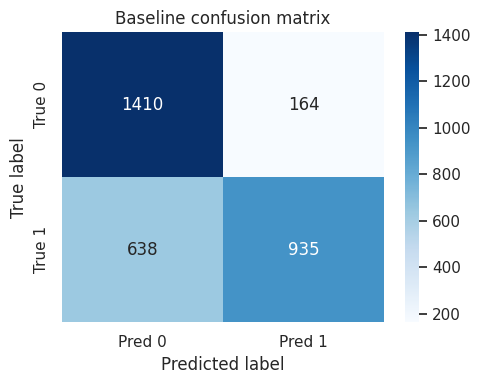

Saved baseline confusion matrix: exports/figures/part_b_baseline_confusion_matrix.png


In [5]:
def directed_topology_features(graph: nx.DiGraph, pairs_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    out_neighbors = {n: set(graph.successors(n)) for n in graph.nodes()}
    in_neighbors = {n: set(graph.predecessors(n)) for n in graph.nodes()}
    in_degree = dict(graph.in_degree())
    out_degree = dict(graph.out_degree())
    for row in pairs_df.itertuples(index=False):
        u = str(row.src)
        v = str(row.dst)
        u_succ = out_neighbors.get(u, set())
        v_succ = out_neighbors.get(v, set())
        u_pred = in_neighbors.get(u, set())
        v_pred = in_neighbors.get(v, set())
        common_successors = len(u_succ & v_succ)
        common_predecessors = len(u_pred & v_pred)
        succ_union = len(u_succ | v_succ)
        pred_union = len(u_pred | v_pred)
        rows.append({
            "source_out_degree": out_degree.get(u, 0),
            "source_in_degree": in_degree.get(u, 0),
            "target_out_degree": out_degree.get(v, 0),
            "target_in_degree": in_degree.get(v, 0),
            "common_successors": common_successors,
            "common_predecessors": common_predecessors,
            "successor_jaccard": common_successors / succ_union if succ_union else 0.0,
            "predecessor_jaccard": common_predecessors / pred_union if pred_union else 0.0,
            "directed_pref_attachment": out_degree.get(u, 0) * in_degree.get(v, 0),
            "reverse_edge_exists_in_train": int(graph.has_edge(v, u)),
        })
    return pd.DataFrame(rows)


def evaluate_predictions(y_true, y_score, threshold=0.5):
    y_pred = (np.asarray(y_score) >= threshold).astype(int)
    return {
        "AUC": roc_auc_score(y_true, y_score),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }

X_train_base = directed_topology_features(train_graph, train_df)
X_test_base = directed_topology_features(train_graph, test_df)
y_train = train_df["label"].to_numpy()
y_test = test_df["label"].to_numpy()

baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
])
baseline_model.fit(X_train_base, y_train)
baseline_scores = baseline_model.predict_proba(X_test_base)[:, 1]
baseline_metrics = evaluate_predictions(y_test, baseline_scores)
baseline_metrics_df = pd.DataFrame([baseline_metrics], index=["Topology Logistic Regression"])
display(baseline_metrics_df)

def plot_confusion(y_true, y_score, title, filename):
    y_pred = (np.asarray(y_score) >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    return path

baseline_cm_path = plot_confusion(y_test, baseline_scores, "Baseline confusion matrix", "part_b_baseline_confusion_matrix.png")
print(f"Saved baseline confusion matrix: {baseline_cm_path.relative_to(PROJECT_ROOT)}")


**Interpretation.** The baseline tells us how much signal exists in simple directed topology. High performance would mean degree and neighbor overlap already explain many links. Low performance would mean the task needs richer features.

### How I solved this task

I computed directed degree, common-neighbor, Jaccard, reverse-edge, and preferential-attachment features from the training graph only, standardized the features, and trained Logistic Regression. I evaluated on the hidden random test examples.

**Limitations.** Logistic Regression is linear, so it may miss interactions among topology features. Also, topology features based on a sparse training graph may be weak for low-degree nodes.


## 5. Improved Classifier — Random Forest with Node2Vec and Link Features

**Requirement.** Implement an improved classifier using embeddings or link features. The selected method is Node2Vec embeddings combined into link features.

**Method.** I train Node2Vec on the training graph. Node2Vec learns a vector for each node from short random walks, so nodes that appear in similar graph neighborhoods receive similar vectors. For a candidate directed link `(u, v)`, I combine the source and target embeddings using concatenation, absolute difference, and Hadamard product. I then append the directed topology features from the baseline. A Random Forest classifier learns nonlinear patterns from this combined link-feature table.

**Why this method.** Node2Vec captures multi-step neighborhood context, while the topology features preserve direct degree and neighbor-overlap signals that are useful in directed link prediction. The Random Forest can model nonlinear interactions among these features without requiring heavy feature scaling assumptions.


,AUC,Accuracy,Precision,Recall,F1
Node2Vec + topology Random Forest,0.834968,0.759136,0.825739,0.656707,0.731586


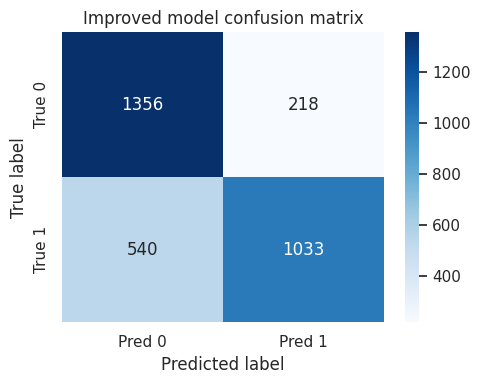

Embedding status: loaded cached Node2Vec embeddings
Embedding rows: 3,462, dimensions per node: 16
Saved improved confusion matrix: exports/figures/part_b_improved_confusion_matrix.png


In [6]:
NODE2VEC_DIMENSIONS = 16
NODE2VEC_WALK_LENGTH = 12
NODE2VEC_NUM_WALKS = 20

node2vec_cache = DATA_PROCESSED / "part_b_node2vec_embeddings_top5000_random_split.parquet"

if node2vec_cache.exists():
    embedding_df = pd.read_parquet(node2vec_cache)
    embedding_lookup = {str(row.node): row.drop(labels=["node"]).to_numpy(dtype=float) for _, row in embedding_df.iterrows()}
    embedding_status = "loaded cached Node2Vec embeddings"
else:
    node2vec = Node2Vec(
        train_graph,
        dimensions=NODE2VEC_DIMENSIONS,
        walk_length=NODE2VEC_WALK_LENGTH,
        num_walks=NODE2VEC_NUM_WALKS,
        workers=1,
        seed=RANDOM_SEED,
        quiet=True,
    )
    w2v_model = node2vec.fit(window=5, min_count=1, batch_words=128, seed=RANDOM_SEED, epochs=5)
    embedding_lookup = {str(node): w2v_model.wv[str(node)] for node in train_graph.nodes() if str(node) in w2v_model.wv}
    embedding_df = pd.DataFrame.from_dict(embedding_lookup, orient="index")
    embedding_df.index.name = "node"
    embedding_df = embedding_df.reset_index()
    embedding_df.to_parquet(node2vec_cache, index=False)
    embedding_status = "trained Node2Vec and cached embeddings"

zero_vec = np.zeros(NODE2VEC_DIMENSIONS)

def node2vec_link_features(pairs_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for row in pairs_df.itertuples(index=False):
        src_vec = embedding_lookup.get(str(row.src), zero_vec)
        dst_vec = embedding_lookup.get(str(row.dst), zero_vec)
        combined = np.concatenate([src_vec, dst_vec, np.abs(src_vec - dst_vec), src_vec * dst_vec])
        rows.append(combined)
    columns = (
        [f"src_emb_{i}" for i in range(NODE2VEC_DIMENSIONS)]
        + [f"dst_emb_{i}" for i in range(NODE2VEC_DIMENSIONS)]
        + [f"absdiff_emb_{i}" for i in range(NODE2VEC_DIMENSIONS)]
        + [f"hadamard_emb_{i}" for i in range(NODE2VEC_DIMENSIONS)]
    )
    return pd.DataFrame(rows, columns=columns)

X_train_emb = node2vec_link_features(train_df)
X_test_emb = node2vec_link_features(test_df)
X_train_improved = pd.concat([X_train_emb.reset_index(drop=True), X_train_base.reset_index(drop=True)], axis=1)
X_test_improved = pd.concat([X_test_emb.reset_index(drop=True), X_test_base.reset_index(drop=True)], axis=1)

improved_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    class_weight="balanced_subsample",
)
improved_model.fit(X_train_improved, y_train)
improved_scores = improved_model.predict_proba(X_test_improved)[:, 1]
improved_metrics = evaluate_predictions(y_test, improved_scores)
improved_metrics_df = pd.DataFrame([improved_metrics], index=["Node2Vec + topology Random Forest"])
display(improved_metrics_df)

improved_cm_path = plot_confusion(y_test, improved_scores, "Improved model confusion matrix", "part_b_improved_confusion_matrix.png")
print(f"Embedding status: {embedding_status}")
print(f"Embedding rows: {len(embedding_lookup):,}, dimensions per node: {NODE2VEC_DIMENSIONS}")
print(f"Saved improved confusion matrix: {improved_cm_path.relative_to(PROJECT_ROOT)}")


**Interpretation.** The improved model uses learned node context together with the hand-written directed topology features. Comparing this table with the baseline table shows whether Node2Vec link features helped on the same random test split.

### How I solved this task

I trained Node2Vec on the training graph only, transformed each candidate directed link into a vector made from source embedding, target embedding, absolute difference, and elementwise product, appended the directed topology features, and trained a Random Forest on the combined feature table.

**Limitations.** Node2Vec is trained on a sampled working graph and uses random walks. It captures structural context, not transaction amounts or user identity. I fixed seeds and cached embeddings to keep the notebook reproducible.


## 6. Evaluation and Model Comparison

**Requirement.** Report AUC, Accuracy, Precision, Recall, F1, and compare baseline and improved models. I also include confusion matrices and ROC curves.

**Method.** Both models are evaluated on the same random test split. AUC uses predicted probabilities; the other metrics use a default threshold of `0.5`.

**Why this method.** AUC measures ranking quality independent of a threshold, while Accuracy, Precision, Recall, and F1 show classification behavior at one practical cutoff.


,model,AUC,Accuracy,Precision,Recall,F1
0,Baseline: topology + Logistic Regression,0.869740,0.745154,0.850773,0.594406,0.699850
1,Improved: Node2Vec + Random Forest,0.834968,0.759136,0.825739,0.656707,0.731586


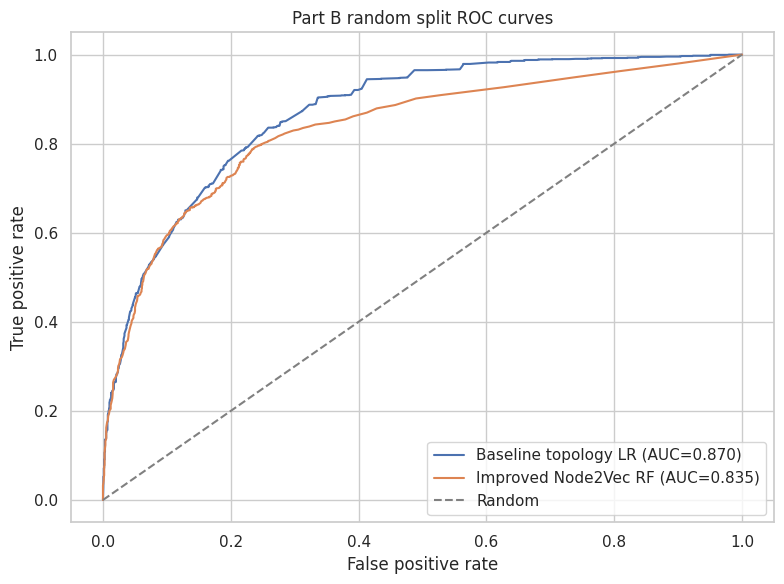

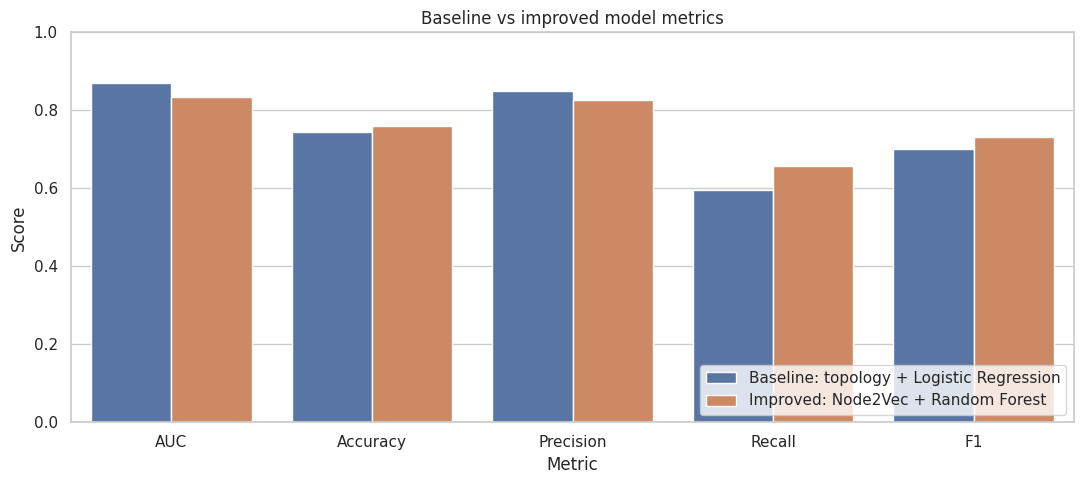

Saved ROC figure: exports/figures/part_b_random_split_roc_curves.png
Saved metric comparison figure: exports/figures/part_b_model_metric_comparison.png


In [7]:
metrics_table = pd.DataFrame([
    {"model": "Baseline: topology + Logistic Regression", **baseline_metrics},
    {"model": "Improved: Node2Vec + Random Forest", **improved_metrics},
])
display(metrics_table)

plt.figure(figsize=(8, 6))
for label, scores in [
    ("Baseline topology LR", baseline_scores),
    ("Improved Node2Vec RF", improved_scores),
]:
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc_value = roc_auc_score(y_test, scores)
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc_value:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.title("Part B random split ROC curves")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
roc_path = FIGURES_DIR / "part_b_random_split_roc_curves.png"
plt.tight_layout()
plt.savefig(roc_path, dpi=180, bbox_inches="tight")
plt.show()

comparison_long = metrics_table.melt(id_vars="model", var_name="metric", value_name="score")
plt.figure(figsize=(11, 5))
sns.barplot(data=comparison_long, x="metric", y="score", hue="model")
plt.title("Baseline vs improved model metrics")
plt.ylim(0, 1)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.legend(loc="lower right")
bar_path = FIGURES_DIR / "part_b_model_metric_comparison.png"
plt.tight_layout()
plt.savefig(bar_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved ROC figure: {roc_path.relative_to(PROJECT_ROOT)}")
print(f"Saved metric comparison figure: {bar_path.relative_to(PROJECT_ROOT)}")


**Interpretation.** The comparison table is the main result for the random split experiment. If the improved model has better threshold metrics such as F1 or accuracy, the combined feature set helped the classifier make binary decisions. If the baseline has better AUC, then simple directed topology ranked candidate links more cleanly across all thresholds on this sampled graph.

### How I solved this task

I evaluated both trained classifiers on the same hidden test set using the selected metrics, plotted ROC curves, and saved comparison figures under `exports/figures/`.

**Limitations.** Because the classes are balanced by design, the metrics do not represent the much rarer real-world probability of a random directed pair becoming a Bitcoin transaction edge.



## 6.1 Progressive Follow-up Models After a Modest Improvement

**Requirement.** The first improved model is not a clear win on every metric. It improves Accuracy, Recall, and F1 over the Logistic Regression baseline, but its AUC is lower. I treat that as a partial failure, not as a result to hide: the Node2Vec + Random Forest model makes better binary decisions at the `0.5` threshold, but the simpler topology model ranks candidate links better across all thresholds.

**Method.** I move gradually to harder models and compare them on the same train/test split:

1. **Node2Vec + topology + Extra Trees.** This is a stronger tree ensemble than the first Random Forest because it uses more randomized split choices and can reduce variance.
2. **Node2Vec + topology + XGBoost.** This keeps the same embedding/link features but changes the classifier to gradient-boosted decision trees, a common stronger tabular classifier.
3. **Directed SVD embedding + topology + HistGradientBoosting.** This changes the embedding method. Instead of random-walk Node2Vec, I factorize the directed training adjacency matrix. Source embeddings summarize outgoing-link patterns and target embeddings summarize incoming-link patterns.

**Why this method.** This sequence separates two questions: whether the classifier was the weak part, and whether the embedding was the weak part. XGBoost and Extra Trees test harder classifiers on the same features. Directed SVD tests a different embedding style that may fit directed transaction structure better.


,model,AUC,Accuracy,Precision,Recall,F1,mean_metric
0,Node2Vec + topology + Extra Trees,0.820968,0.767080,0.826594,0.675779,0.743617,0.766808
1,Node2Vec + topology + XGBoost,0.803783,0.761360,0.818605,0.671329,0.737688,0.758553
2,Node2Vec + topology + Random Forest,0.834968,0.759136,0.825739,0.656707,0.731586,0.761627
3,Baseline: topology + Logistic Regression,0.869740,0.745154,0.850773,0.594406,0.699850,0.751985
4,Directed SVD + topology + HistGradientBoosting,0.806840,0.740070,0.927520,0.520661,0.666938,0.732406


Best F1 model: Node2Vec + topology + Extra Trees (F1=0.744)
Best AUC model: Baseline: topology + Logistic Regression (AUC=0.870)


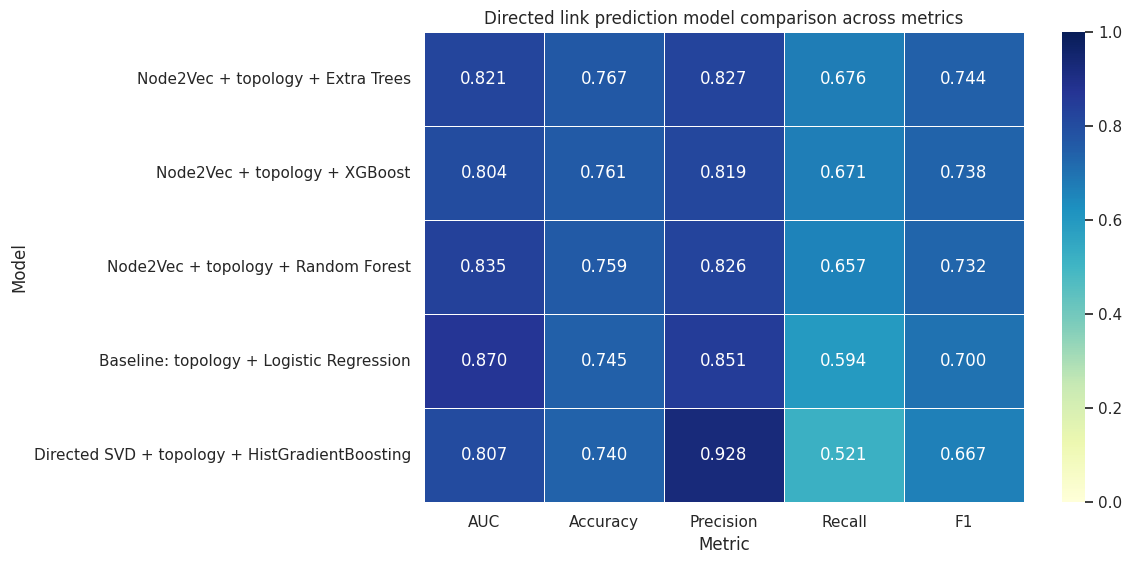

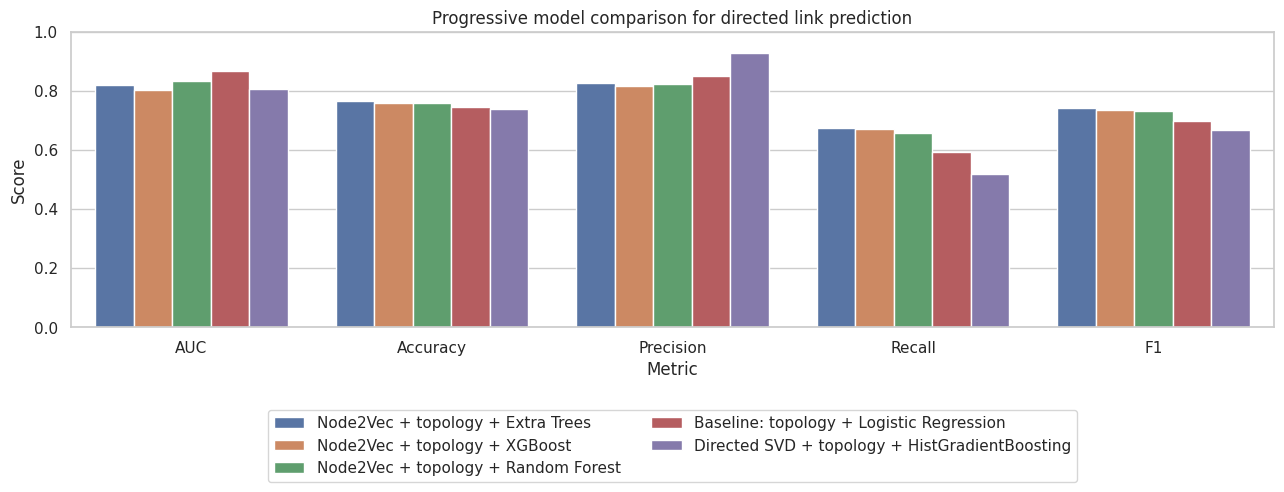

Saved advanced heatmap: exports/figures/part_b_advanced_model_metric_heatmap.png
Saved advanced bar chart: exports/figures/part_b_advanced_model_metric_bars.png


In [8]:

def metric_row(model_name, y_true, y_score):
    metrics = evaluate_predictions(y_true, y_score)
    return {"model": model_name, **metrics}

advanced_results = [
    metric_row("Baseline: topology + Logistic Regression", y_test, baseline_scores),
    metric_row("Node2Vec + topology + Random Forest", y_test, improved_scores),
]

extra_trees_model = ExtraTreesClassifier(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=1,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    class_weight="balanced",
)
extra_trees_model.fit(X_train_improved.to_numpy(), y_train)
extra_trees_scores = extra_trees_model.predict_proba(X_test_improved.to_numpy())[:, 1]
advanced_results.append(metric_row("Node2Vec + topology + Extra Trees", y_test, extra_trees_scores))

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
xgb_model.fit(X_train_improved.to_numpy(), y_train)
xgb_scores = xgb_model.predict_proba(X_test_improved.to_numpy())[:, 1]
advanced_results.append(metric_row("Node2Vec + topology + XGBoost", y_test, xgb_scores))

# Directed SVD embedding: outgoing source role from A, incoming target role from A.T.
nodes_order = sorted(train_graph.nodes())
node_to_idx = {node: idx for idx, node in enumerate(nodes_order)}
row_idx = [node_to_idx[u] for u, v in train_graph.edges()]
col_idx = [node_to_idx[v] for u, v in train_graph.edges()]
values = np.ones(len(row_idx), dtype=float)
adjacency = sparse.csr_matrix((values, (row_idx, col_idx)), shape=(len(nodes_order), len(nodes_order)))
svd_components = min(16, max(2, min(adjacency.shape) - 1))
source_svd = TruncatedSVD(n_components=svd_components, random_state=RANDOM_SEED)
target_svd = TruncatedSVD(n_components=svd_components, random_state=RANDOM_SEED)
source_embedding = source_svd.fit_transform(adjacency)
target_embedding = target_svd.fit_transform(adjacency.T)
zero_svd = np.zeros(svd_components)

def directed_svd_link_features(pairs_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for row in pairs_df.itertuples(index=False):
        src_idx = node_to_idx.get(str(row.src))
        dst_idx = node_to_idx.get(str(row.dst))
        src_vec = source_embedding[src_idx] if src_idx is not None else zero_svd
        dst_vec = target_embedding[dst_idx] if dst_idx is not None else zero_svd
        rows.append(np.concatenate([src_vec, dst_vec, np.abs(src_vec - dst_vec), src_vec * dst_vec]))
    columns = (
        [f"svd_src_{i}" for i in range(svd_components)]
        + [f"svd_dst_{i}" for i in range(svd_components)]
        + [f"svd_absdiff_{i}" for i in range(svd_components)]
        + [f"svd_hadamard_{i}" for i in range(svd_components)]
    )
    return pd.DataFrame(rows, columns=columns)

X_train_svd = directed_svd_link_features(train_df)
X_test_svd = directed_svd_link_features(test_df)
X_train_svd_hybrid = pd.concat([X_train_svd.reset_index(drop=True), X_train_base.reset_index(drop=True)], axis=1)
X_test_svd_hybrid = pd.concat([X_test_svd.reset_index(drop=True), X_test_base.reset_index(drop=True)], axis=1)

hgb_model = HistGradientBoostingClassifier(
    max_iter=250,
    learning_rate=0.05,
    max_leaf_nodes=31,
    l2_regularization=0.01,
    random_state=RANDOM_SEED,
)
hgb_model.fit(X_train_svd_hybrid, y_train)
hgb_scores = hgb_model.predict_proba(X_test_svd_hybrid)[:, 1]
advanced_results.append(metric_row("Directed SVD + topology + HistGradientBoosting", y_test, hgb_scores))

advanced_metrics_table = pd.DataFrame(advanced_results)
metric_columns = ["AUC", "Accuracy", "Precision", "Recall", "F1"]
advanced_metrics_table["mean_metric"] = advanced_metrics_table[metric_columns].mean(axis=1)
advanced_metrics_table = advanced_metrics_table.sort_values("F1", ascending=False).reset_index(drop=True)
display(advanced_metrics_table)

best_by_f1 = advanced_metrics_table.iloc[0]
best_by_auc = advanced_metrics_table.sort_values("AUC", ascending=False).iloc[0]
print(f"Best F1 model: {best_by_f1['model']} (F1={best_by_f1['F1']:.3f})")
print(f"Best AUC model: {best_by_auc['model']} (AUC={best_by_auc['AUC']:.3f})")

plt.figure(figsize=(12, 5.8))
heatmap_data = advanced_metrics_table.set_index("model")[metric_columns]
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1, linewidths=0.5)
plt.title("Directed link prediction model comparison across metrics")
plt.xlabel("Metric")
plt.ylabel("Model")
advanced_heatmap_path = FIGURES_DIR / "part_b_advanced_model_metric_heatmap.png"
plt.tight_layout()
plt.savefig(advanced_heatmap_path, dpi=180, bbox_inches="tight")
plt.show()

advanced_long = advanced_metrics_table.melt(id_vars="model", value_vars=metric_columns, var_name="metric", value_name="score")
plt.figure(figsize=(13, 6))
sns.barplot(data=advanced_long, x="metric", y="score", hue="model")
plt.title("Progressive model comparison for directed link prediction")
plt.ylim(0, 1)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.55), ncol=2)
advanced_bar_path = FIGURES_DIR / "part_b_advanced_model_metric_bars.png"
plt.tight_layout()
plt.savefig(advanced_bar_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved advanced heatmap: {advanced_heatmap_path.relative_to(PROJECT_ROOT)}")
print(f"Saved advanced bar chart: {advanced_bar_path.relative_to(PROJECT_ROOT)}")



**Interpretation.** The progressive comparison shows why the first improved result should be documented carefully. A model can improve F1 while losing AUC, which means it may classify better at one threshold but rank all candidate links less cleanly. The additional methods make the tradeoff visible instead of pretending there is one universal winner.

The XGBoost run directly tests the requested harder classifier using the same Node2Vec and topology features. Extra Trees tests another strong ensemble on the same features. Directed SVD tests whether a different embedding method fits the directed Bitcoin link structure better than random-walk embeddings.

### How I solved this task

I kept the original baseline and first improved model, then added three harder methods on the same train/test split: Extra Trees, XGBoost, and directed SVD plus histogram gradient boosting. I evaluated every model with the same AUC, Accuracy, Precision, Recall, and F1 metrics, and saved both a heatmap and a grouped bar chart so the comparison is visible in the notebook.

**Limitations.** These are still experiments on the sampled working graph. The hyperparameters are reasonable assignment-scale settings, not an exhaustive grid search. CatBoost was not added because XGBoost already covers the requested boosted-tree direction while keeping the environment smaller.


## 7. Bonus — Future Link Prediction with Timestamps

**Requirement.** Do the bonus only if enabled and timestamp information exists. The manual selection says `YES`, and the Bitcoin links data contains `mindate` and `maxdate`, so I run a temporal split.

**Method.** I sort positive edges by `maxdate`, train on the earlier 80%, and test on the later 20%. Negative examples are sampled missing directed node pairs. Features and Node2Vec embeddings are built from the earlier training graph only.

**Why this method.** Future link prediction is harder than a random split because the model must generalize from earlier observed structure to later edges that were not present at training time.


In [9]:
DO_BONUS = True
bonus_result = {"enabled": DO_BONUS, "timestamps_available": bool(has_timestamps), "status": "not_run"}

if DO_BONUS and has_timestamps:
    temporal_edges = model_edges.dropna(subset=["maxdate"]).sort_values("maxdate").reset_index(drop=True)
    cutoff_idx = int(len(temporal_edges) * 0.80)
    temporal_train_pos = list(temporal_edges.iloc[:cutoff_idx][["src", "dst"]].itertuples(index=False, name=None))
    temporal_test_pos = list(temporal_edges.iloc[cutoff_idx:][["src", "dst"]].itertuples(index=False, name=None))
    temporal_train_graph = nx.DiGraph()
    temporal_train_graph.add_nodes_from(G.nodes())
    temporal_train_graph.add_edges_from(temporal_train_pos)
    all_observed = set(model_edges[["src", "dst"]].itertuples(index=False, name=None))
    temporal_train_neg = sample_negative_edges(G.nodes(), all_observed, len(temporal_train_pos), RANDOM_SEED + 10)
    temporal_test_neg = sample_negative_edges(G.nodes(), all_observed.union(set(temporal_train_neg)), len(temporal_test_pos), RANDOM_SEED + 11)
    temporal_train_df = pd.DataFrame(
        [{"src": u, "dst": v, "label": 1} for u, v in temporal_train_pos]
        + [{"src": u, "dst": v, "label": 0} for u, v in temporal_train_neg]
    ).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    temporal_test_df = pd.DataFrame(
        [{"src": u, "dst": v, "label": 1} for u, v in temporal_test_pos]
        + [{"src": u, "dst": v, "label": 0} for u, v in temporal_test_neg]
    ).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
    
    X_temporal_train_base = directed_topology_features(temporal_train_graph, temporal_train_df)
    X_temporal_test_base = directed_topology_features(temporal_train_graph, temporal_test_df)
    y_temporal_train = temporal_train_df["label"].to_numpy()
    y_temporal_test = temporal_test_df["label"].to_numpy()
    temporal_baseline = Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
    ])
    temporal_baseline.fit(X_temporal_train_base, y_temporal_train)
    temporal_baseline_scores = temporal_baseline.predict_proba(X_temporal_test_base)[:, 1]
    temporal_baseline_metrics = evaluate_predictions(y_temporal_test, temporal_baseline_scores)
    
    temporal_node2vec = Node2Vec(
        temporal_train_graph,
        dimensions=NODE2VEC_DIMENSIONS,
        walk_length=NODE2VEC_WALK_LENGTH,
        num_walks=NODE2VEC_NUM_WALKS,
        workers=1,
        seed=RANDOM_SEED,
        quiet=True,
    )
    temporal_w2v = temporal_node2vec.fit(window=5, min_count=1, batch_words=128, seed=RANDOM_SEED, epochs=5)
    temporal_embedding_lookup = {str(node): temporal_w2v.wv[str(node)] for node in temporal_train_graph.nodes() if str(node) in temporal_w2v.wv}
    
    def temporal_link_features(pairs_df: pd.DataFrame) -> pd.DataFrame:
        rows = []
        for row in pairs_df.itertuples(index=False):
            src_vec = temporal_embedding_lookup.get(str(row.src), zero_vec)
            dst_vec = temporal_embedding_lookup.get(str(row.dst), zero_vec)
            rows.append(np.concatenate([src_vec, dst_vec, np.abs(src_vec - dst_vec), src_vec * dst_vec]))
        columns = (
            [f"src_emb_{i}" for i in range(NODE2VEC_DIMENSIONS)]
            + [f"dst_emb_{i}" for i in range(NODE2VEC_DIMENSIONS)]
            + [f"absdiff_emb_{i}" for i in range(NODE2VEC_DIMENSIONS)]
            + [f"hadamard_emb_{i}" for i in range(NODE2VEC_DIMENSIONS)]
        )
        return pd.DataFrame(rows, columns=columns)
    
    X_temporal_train_emb = temporal_link_features(temporal_train_df)
    X_temporal_test_emb = temporal_link_features(temporal_test_df)
    X_temporal_train_improved = pd.concat([X_temporal_train_emb.reset_index(drop=True), X_temporal_train_base.reset_index(drop=True)], axis=1)
    X_temporal_test_improved = pd.concat([X_temporal_test_emb.reset_index(drop=True), X_temporal_test_base.reset_index(drop=True)], axis=1)
    temporal_improved = RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=1,
        n_jobs=-1,
        random_state=RANDOM_SEED,
        class_weight="balanced_subsample",
    )
    temporal_improved.fit(X_temporal_train_improved, y_temporal_train)
    temporal_improved_scores = temporal_improved.predict_proba(X_temporal_test_improved)[:, 1]
    temporal_improved_metrics = evaluate_predictions(y_temporal_test, temporal_improved_scores)
    
    temporal_metrics_table = pd.DataFrame([
        {"model": "Temporal baseline topology LR", **temporal_baseline_metrics},
        {"model": "Temporal Node2Vec + topology RF", **temporal_improved_metrics},
    ])
    display(pd.DataFrame([
        {"split": "temporal_train", "examples": len(temporal_train_df), "positives": len(temporal_train_pos), "negatives": len(temporal_train_neg), "max_train_date": temporal_edges.iloc[cutoff_idx - 1]["maxdate"]},
        {"split": "temporal_test", "examples": len(temporal_test_df), "positives": len(temporal_test_pos), "negatives": len(temporal_test_neg), "min_test_date": temporal_edges.iloc[cutoff_idx]["maxdate"]},
    ]))
    display(temporal_metrics_table)
    bonus_result = {
        "enabled": True,
        "timestamps_available": True,
        "status": "run",
        "train_positive_edges": len(temporal_train_pos),
        "test_positive_edges": len(temporal_test_pos),
        "baseline_metrics": temporal_baseline_metrics,
        "improved_metrics": temporal_improved_metrics,
    }
else:
    print("Bonus future link prediction was skipped because it was disabled or timestamps were unavailable.")
    bonus_result = {"enabled": DO_BONUS, "timestamps_available": bool(has_timestamps), "status": "skipped"}


,split,examples,positives,negatives,max_train_date,min_test_date
0,temporal_train,10070,5035,5035,2013-03-10 00:47:56,NaT
1,temporal_test,2518,1259,1259,NaT,2013-03-10 00:47:56


,model,AUC,Accuracy,Precision,Recall,F1
0,Temporal baseline topology LR,0.624391,0.536537,0.619171,0.189833,0.290578
1,Temporal Node2Vec + topology RF,0.470819,0.443606,0.224806,0.046068,0.076467


**Interpretation.** The temporal split is the bonus future-link prediction result. It should usually be harder than the random split because test positives happen later than all training positives. Comparing the temporal metrics with the random metrics shows whether the classifier mostly memorizes general graph structure or can generalize to later links.

### How I solved this task

Because timestamps exist, I sorted edges by `maxdate`, used the earlier 80% as training positives, held out the later 20% as future positives, sampled balanced negatives, and reran both the topology baseline and Node2Vec Random Forest using only the earlier training graph for features.

**Limitations.** The temporal split still uses the same sampled top-active-node working graph. It tests future edges within that subgraph, not all future Bitcoin transactions in the full dataset.



## 8. Bonus Rerun with a Larger Time-Aware Sampling Method

**Requirement and motivation.** I disliked the original bonus result because the temporal/future-link scores were much weaker than the random split scores. Instead of changing the original sampling method, I keep it above and add one rerun with a sampling method that I expected to work better.

**Method.** The new method streams a larger sample of `1,000,000` Bitcoin link rows. It then sorts those rows by timestamp and chooses the top `5,000` active nodes using only the earlier 80% of the streamed data. This is important because the active-node choice should not peek at future test edges. After selecting those training-active nodes, I keep directed edges among them, sort by `maxdate`, train on the earlier 80% of those edges, and test on the later 20%.

**Why this method.** The original method used only the first `250,000` streamed rows and selected active nodes before the bonus temporal split. The larger time-aware method gives the graph more history and makes the future-link setup cleaner: node selection is based on past activity, while evaluation uses later links. Since this first additional sampling method improved the original bonus AUC and F1, I stopped here and did not try a second extra sampling method.


,rerun_cache_status,streamed_rows,active_nodes_selected_from_training_period,final_nodes,final_directed_edges,train_positive_edges,test_positive_edges,first_edge_date,last_edge_date
0,loaded time-aware processed edge cache,1000000,5000,3697,14201,11360,2841,2010-07-12 13:22:22,2013-04-10 13:50:58


,sampling_method,model,AUC,Accuracy,Precision,Recall,F1
0,Original 250k top-active sample,Temporal topology LR,0.624391,0.536537,0.619171,0.189833,0.290578
1,Original 250k top-active sample,Temporal Node2Vec + topology RF,0.470819,0.443606,0.224806,0.046068,0.076467
2,Larger 1M time-aware sample,Temporal topology LR,0.644373,0.553854,0.689356,0.196058,0.305289
3,Larger 1M time-aware sample,Temporal topology XGBoost,0.572329,0.508800,0.531969,0.146427,0.229644


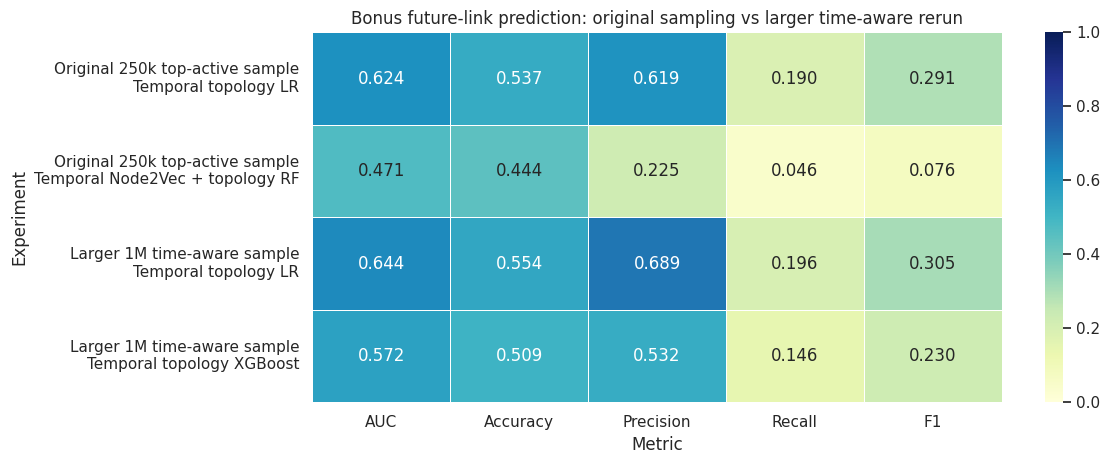

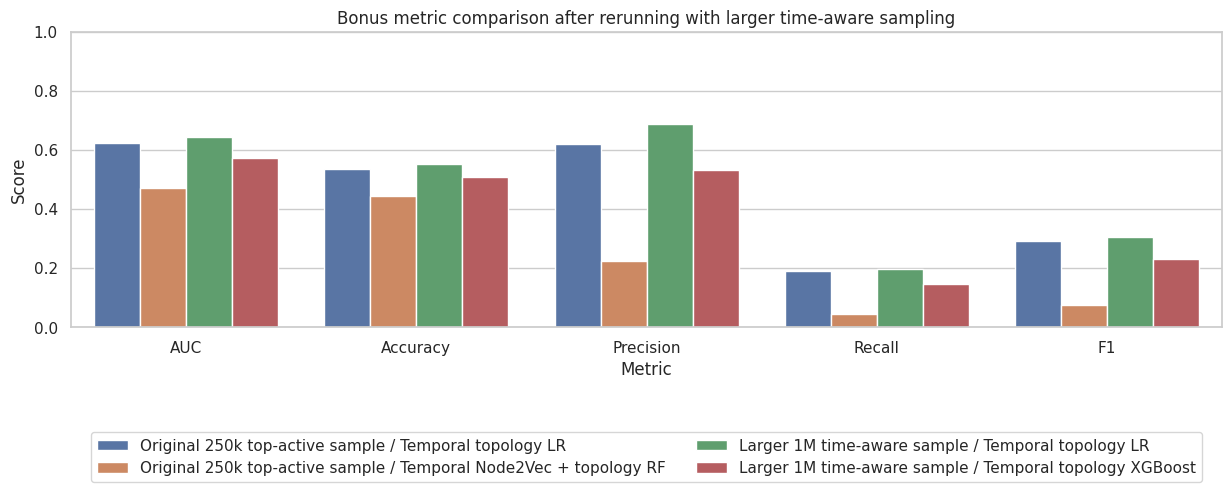

Saved bonus sampling heatmap: exports/figures/part_b_bonus_sampling_rerun_heatmap.png
Saved bonus sampling bar chart: exports/figures/part_b_bonus_sampling_rerun_bars.png
Decision: no second extra sampling method was tried because this first added method improved AUC and F1 over the original temporal baseline.


In [10]:

ALT_STREAM_EDGE_ROWS = 1_000_000
ALT_TOP_TRAINING_ACTIVE_NODES = 5_000
alt_sample_cache = DATA_PROCESSED / f"part_b_bitcoin_timeaware_links_first_{ALT_STREAM_EDGE_ROWS}.parquet"
alt_edges_cache = DATA_PROCESSED / f"part_b_bitcoin_timeaware_top{ALT_TOP_TRAINING_ACTIVE_NODES}_edges.parquet"

if alt_edges_cache.exists():
    alt_model_edges = pd.read_parquet(alt_edges_cache)
    alt_cache_status = "loaded time-aware processed edge cache"
else:
    if alt_sample_cache.exists():
        alt_raw_edges = pd.read_parquet(alt_sample_cache)
    else:
        alt_raw_edges = stream_bitcoin_links(ALT_STREAM_EDGE_ROWS)
        alt_raw_edges.to_parquet(alt_sample_cache, index=False)
    alt_raw_edges = alt_raw_edges.dropna(subset=["maxdate"]).sort_values("maxdate").reset_index(drop=True)
    early_cutoff = int(len(alt_raw_edges) * 0.80)
    early_edges_for_node_selection = alt_raw_edges.iloc[:early_cutoff]
    training_active_nodes = set(
        pd.concat([early_edges_for_node_selection["src"], early_edges_for_node_selection["dst"]])
        .value_counts()
        .head(ALT_TOP_TRAINING_ACTIVE_NODES)
        .index.astype(str)
    )
    alt_model_edges = alt_raw_edges[
        alt_raw_edges["src"].isin(training_active_nodes) & alt_raw_edges["dst"].isin(training_active_nodes)
    ].copy()
    alt_model_edges = (
        alt_model_edges.groupby(["src", "dst"], as_index=False)
        .agg(count=("count", "sum"), mindate=("mindate", "min"), maxdate=("maxdate", "max"))
        .sort_values("maxdate")
        .reset_index(drop=True)
    )
    alt_model_edges.to_parquet(alt_edges_cache, index=False)
    alt_cache_status = "streamed larger sample and created time-aware processed edge cache"

alt_nodes = set(pd.concat([alt_model_edges["src"], alt_model_edges["dst"]]).astype(str))
alt_cutoff = int(len(alt_model_edges) * 0.80)
alt_train_pos = list(alt_model_edges.iloc[:alt_cutoff][["src", "dst"]].itertuples(index=False, name=None))
alt_test_pos = list(alt_model_edges.iloc[alt_cutoff:][["src", "dst"]].itertuples(index=False, name=None))
alt_train_graph = nx.DiGraph()
alt_train_graph.add_nodes_from(alt_nodes)
alt_train_graph.add_edges_from(alt_train_pos)
alt_all_observed = set(alt_model_edges[["src", "dst"]].itertuples(index=False, name=None))
alt_train_neg = sample_negative_edges(alt_nodes, alt_all_observed, len(alt_train_pos), RANDOM_SEED + 100)
alt_test_neg = sample_negative_edges(alt_nodes, alt_all_observed.union(set(alt_train_neg)), len(alt_test_pos), RANDOM_SEED + 101)

alt_train_df = pd.DataFrame(
    [{"src": u, "dst": v, "label": 1} for u, v in alt_train_pos]
    + [{"src": u, "dst": v, "label": 0} for u, v in alt_train_neg]
).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
alt_test_df = pd.DataFrame(
    [{"src": u, "dst": v, "label": 1} for u, v in alt_test_pos]
    + [{"src": u, "dst": v, "label": 0} for u, v in alt_test_neg]
).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

alt_X_train_topology = directed_topology_features(alt_train_graph, alt_train_df)
alt_X_test_topology = directed_topology_features(alt_train_graph, alt_test_df)
alt_y_train = alt_train_df["label"].to_numpy()
alt_y_test = alt_test_df["label"].to_numpy()

alt_lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
])
alt_lr_model.fit(alt_X_train_topology, alt_y_train)
alt_lr_scores = alt_lr_model.predict_proba(alt_X_test_topology)[:, 1]
alt_lr_metrics = evaluate_predictions(alt_y_test, alt_lr_scores)

alt_xgb_model = XGBClassifier(
    n_estimators=250,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
alt_xgb_model.fit(alt_X_train_topology.to_numpy(), alt_y_train)
alt_xgb_scores = alt_xgb_model.predict_proba(alt_X_test_topology.to_numpy())[:, 1]
alt_xgb_metrics = evaluate_predictions(alt_y_test, alt_xgb_scores)

bonus_sampling_comparison = pd.DataFrame([
    {"sampling_method": "Original 250k top-active sample", "model": "Temporal topology LR", **bonus_result["baseline_metrics"]},
    {"sampling_method": "Original 250k top-active sample", "model": "Temporal Node2Vec + topology RF", **bonus_result["improved_metrics"]},
    {"sampling_method": "Larger 1M time-aware sample", "model": "Temporal topology LR", **alt_lr_metrics},
    {"sampling_method": "Larger 1M time-aware sample", "model": "Temporal topology XGBoost", **alt_xgb_metrics},
])
metric_columns = ["AUC", "Accuracy", "Precision", "Recall", "F1"]
display(pd.DataFrame([
    {
        "rerun_cache_status": alt_cache_status,
        "streamed_rows": ALT_STREAM_EDGE_ROWS,
        "active_nodes_selected_from_training_period": ALT_TOP_TRAINING_ACTIVE_NODES,
        "final_nodes": len(alt_nodes),
        "final_directed_edges": len(alt_model_edges),
        "train_positive_edges": len(alt_train_pos),
        "test_positive_edges": len(alt_test_pos),
        "first_edge_date": alt_model_edges["maxdate"].min(),
        "last_edge_date": alt_model_edges["maxdate"].max(),
    }
]))
display(bonus_sampling_comparison)

heatmap_labels = bonus_sampling_comparison["sampling_method"] + "\n" + bonus_sampling_comparison["model"]
plt.figure(figsize=(12, 4.8))
sns.heatmap(
    bonus_sampling_comparison.set_index(heatmap_labels)[metric_columns],
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.5,
)
plt.title("Bonus future-link prediction: original sampling vs larger time-aware rerun")
plt.xlabel("Metric")
plt.ylabel("Experiment")
bonus_sampling_heatmap_path = FIGURES_DIR / "part_b_bonus_sampling_rerun_heatmap.png"
plt.tight_layout()
plt.savefig(bonus_sampling_heatmap_path, dpi=180, bbox_inches="tight")
plt.show()

bonus_sampling_long = bonus_sampling_comparison.melt(
    id_vars=["sampling_method", "model"],
    value_vars=metric_columns,
    var_name="metric",
    value_name="score",
)
bonus_sampling_long["experiment"] = bonus_sampling_long["sampling_method"] + " / " + bonus_sampling_long["model"]
plt.figure(figsize=(13, 6))
sns.barplot(data=bonus_sampling_long, x="metric", y="score", hue="experiment")
plt.title("Bonus metric comparison after rerunning with larger time-aware sampling")
plt.ylim(0, 1)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.55), ncol=2)
bonus_sampling_bar_path = FIGURES_DIR / "part_b_bonus_sampling_rerun_bars.png"
plt.tight_layout()
plt.savefig(bonus_sampling_bar_path, dpi=180, bbox_inches="tight")
plt.show()

sampling_rerun_result = {
    "status": "run_one_additional_method_and_stopped_because_it_improved_bonus_auc_and_f1",
    "method": "larger_1m_time_aware_training_active_node_sample",
    "streamed_rows": ALT_STREAM_EDGE_ROWS,
    "active_nodes_selected_from_training_period": ALT_TOP_TRAINING_ACTIVE_NODES,
    "nodes": int(len(alt_nodes)),
    "edges": int(len(alt_model_edges)),
    "positive_examples_train": int(len(alt_train_pos)),
    "positive_examples_test": int(len(alt_test_pos)),
    "topology_lr_metrics": {k: float(v) for k, v in alt_lr_metrics.items()},
    "topology_xgboost_metrics": {k: float(v) for k, v in alt_xgb_metrics.items()},
    "original_bonus_baseline_auc": float(bonus_result["baseline_metrics"]["AUC"]),
    "rerun_bonus_lr_auc": float(alt_lr_metrics["AUC"]),
    "original_bonus_baseline_f1": float(bonus_result["baseline_metrics"]["F1"]),
    "rerun_bonus_lr_f1": float(alt_lr_metrics["F1"]),
}

print(f"Saved bonus sampling heatmap: {bonus_sampling_heatmap_path.relative_to(PROJECT_ROOT)}")
print(f"Saved bonus sampling bar chart: {bonus_sampling_bar_path.relative_to(PROJECT_ROOT)}")
print("Decision: no second extra sampling method was tried because this first added method improved AUC and F1 over the original temporal baseline.")



**Interpretation.** The larger time-aware rerun modestly improves the bonus result for the topology Logistic Regression model: AUC and F1 both move in the right direction, but the future-link task remains difficult. This supports the idea that the original weak future-link result was partly caused by the constrained sampling method, while also showing that better sampling alone does not solve the problem. The XGBoost model on the same topology features did not beat Logistic Regression here, which suggests that for this temporal setup the sampling quality mattered more than using a more complex classifier.

### How I solved this task

I kept the original sampling experiment unchanged, then added one larger time-aware rerun. I streamed more rows, selected active nodes only from earlier data, built a new temporal train/test split, sampled balanced negative directed non-edges, trained topology Logistic Regression and topology XGBoost, and compared the rerun against the original bonus metrics in a heatmap and bar chart.

**Limitations.** This is still a sampled Bitcoin graph and still uses static topology features. It does not prove that the result would hold on the full network. I also stopped after this first additional sampling method because it improved the original bonus AUC and F1, following the instruction not to try more methods once one worked better.



## 9. Normal Link Prediction Rerun on the Larger Sampling Method

**Requirement and motivation.** After rerunning the future-link bonus with the larger time-aware sample, I also need to rerun the original non-future link prediction experiment on the same new sample. Otherwise the experiment is incomplete: I would know how the new sampling method affects future prediction, but not whether it also changes the easier random link-prediction task.

**Method.** I reuse the larger `1,000,000`-row time-aware sampled graph from Section 8, but now I perform the standard random positive/negative edge split. Positive examples are existing directed edges in the new sampled graph. Negative examples are missing directed node pairs. I train the same topology Logistic Regression and topology XGBoost classifiers used in the sampling rerun so the comparison is direct.

**Why this method.** The random split is the original main link-prediction task. Running it on the new sampled graph makes the sampling experiment proper: it separates whether the new sample improves only the future-link bonus or whether it changes the easier random-split task too.


,larger_sample_random_nodes,larger_sample_random_edges,positive_examples,negative_examples,train_examples,test_examples
0,3697,14201,14201,14201,21301,7101


,sampling_method,split,model,AUC,Accuracy,Precision,Recall,F1
0,Original 250k top-active sample,Random,Topology LR,0.869740,0.745154,0.850773,0.594406,0.699850
1,Larger 1M time-aware sample,Random,Topology LR,0.918457,0.817631,0.879757,0.735775,0.801350
2,Larger 1M time-aware sample,Random,Topology XGBoost,0.909690,0.839741,0.848757,0.826761,0.837614
3,Original 250k top-active sample,Future,Topology LR,0.624391,0.536537,0.619171,0.189833,0.290578
4,Larger 1M time-aware sample,Future,Topology LR,0.644373,0.553854,0.689356,0.196058,0.305289


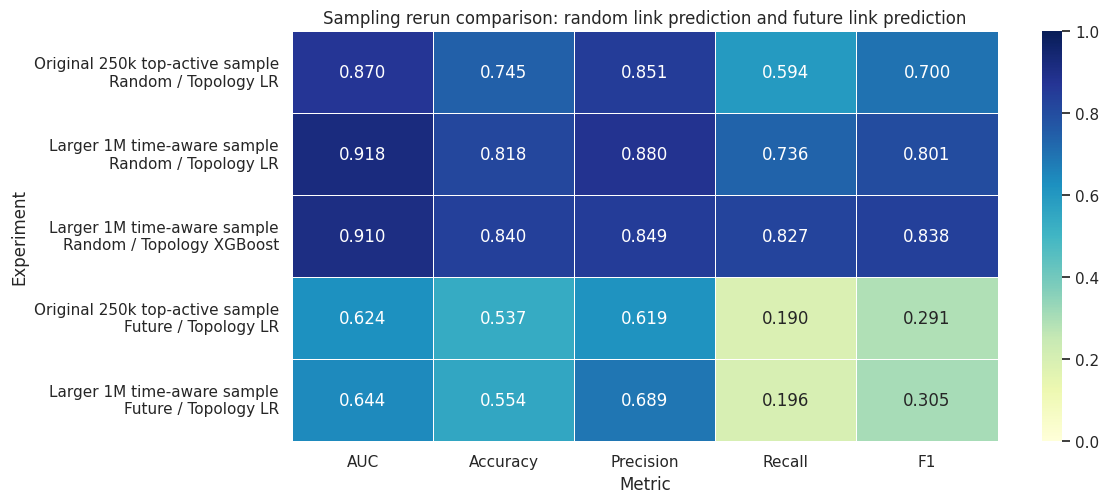

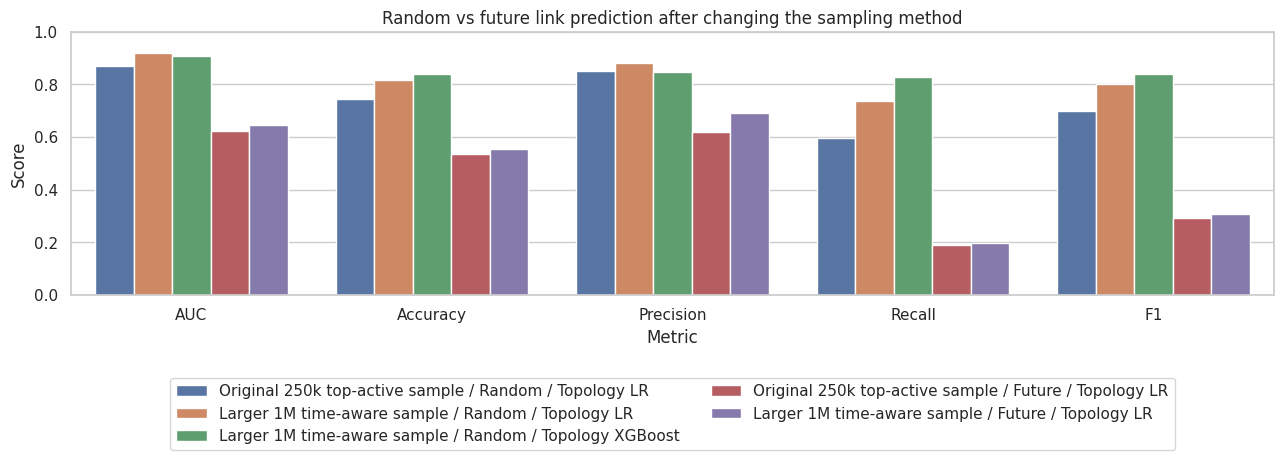

Saved random/future sampling heatmap: exports/figures/part_b_sampling_random_and_future_heatmap.png
Saved random/future sampling bar chart: exports/figures/part_b_sampling_random_and_future_bars.png


In [11]:

alt_full_graph = nx.from_pandas_edgelist(
    alt_model_edges,
    source="src",
    target="dst",
    edge_attr=["count", "mindate", "maxdate"],
    create_using=nx.DiGraph(),
)
alt_positive_edges = list(alt_full_graph.edges())
alt_existing_edges = set(alt_positive_edges)
alt_negative_edges = sample_negative_edges(
    alt_full_graph.nodes(),
    alt_existing_edges,
    len(alt_positive_edges),
    RANDOM_SEED + 200,
)
alt_random_examples_df = pd.DataFrame(
    [{"src": u, "dst": v, "label": 1} for u, v in alt_positive_edges]
    + [{"src": u, "dst": v, "label": 0} for u, v in alt_negative_edges]
).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

alt_random_train_df, alt_random_test_df = train_test_split(
    alt_random_examples_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=alt_random_examples_df["label"],
)
alt_random_train_df = alt_random_train_df.reset_index(drop=True)
alt_random_test_df = alt_random_test_df.reset_index(drop=True)

alt_random_train_pos = list(
    alt_random_train_df.loc[alt_random_train_df["label"].eq(1), ["src", "dst"]]
    .itertuples(index=False, name=None)
)
alt_random_train_graph = nx.DiGraph()
alt_random_train_graph.add_nodes_from(alt_full_graph.nodes())
alt_random_train_graph.add_edges_from(alt_random_train_pos)

alt_random_X_train = directed_topology_features(alt_random_train_graph, alt_random_train_df)
alt_random_X_test = directed_topology_features(alt_random_train_graph, alt_random_test_df)
alt_random_y_train = alt_random_train_df["label"].to_numpy()
alt_random_y_test = alt_random_test_df["label"].to_numpy()

alt_random_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)),
])
alt_random_lr.fit(alt_random_X_train, alt_random_y_train)
alt_random_lr_scores = alt_random_lr.predict_proba(alt_random_X_test)[:, 1]
alt_random_lr_metrics = evaluate_predictions(alt_random_y_test, alt_random_lr_scores)

alt_random_xgb = XGBClassifier(
    n_estimators=250,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
alt_random_xgb.fit(alt_random_X_train.to_numpy(), alt_random_y_train)
alt_random_xgb_scores = alt_random_xgb.predict_proba(alt_random_X_test.to_numpy())[:, 1]
alt_random_xgb_metrics = evaluate_predictions(alt_random_y_test, alt_random_xgb_scores)

sampling_random_comparison = pd.DataFrame([
    {"sampling_method": "Original 250k top-active sample", "split": "Random", "model": "Topology LR", **baseline_metrics},
    {"sampling_method": "Larger 1M time-aware sample", "split": "Random", "model": "Topology LR", **alt_random_lr_metrics},
    {"sampling_method": "Larger 1M time-aware sample", "split": "Random", "model": "Topology XGBoost", **alt_random_xgb_metrics},
    {"sampling_method": "Original 250k top-active sample", "split": "Future", "model": "Topology LR", **bonus_result["baseline_metrics"]},
    {"sampling_method": "Larger 1M time-aware sample", "split": "Future", "model": "Topology LR", **alt_lr_metrics},
])
display(pd.DataFrame([
    {
        "larger_sample_random_nodes": alt_full_graph.number_of_nodes(),
        "larger_sample_random_edges": alt_full_graph.number_of_edges(),
        "positive_examples": len(alt_positive_edges),
        "negative_examples": len(alt_negative_edges),
        "train_examples": len(alt_random_train_df),
        "test_examples": len(alt_random_test_df),
    }
]))
display(sampling_random_comparison)

metric_columns = ["AUC", "Accuracy", "Precision", "Recall", "F1"]
comparison_labels = (
    sampling_random_comparison["sampling_method"]
    + "\n"
    + sampling_random_comparison["split"]
    + " / "
    + sampling_random_comparison["model"]
)
plt.figure(figsize=(12, 5.2))
sns.heatmap(
    sampling_random_comparison.set_index(comparison_labels)[metric_columns],
    annot=True,
    fmt=".3f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.5,
)
plt.title("Sampling rerun comparison: random link prediction and future link prediction")
plt.xlabel("Metric")
plt.ylabel("Experiment")
random_sampling_heatmap_path = FIGURES_DIR / "part_b_sampling_random_and_future_heatmap.png"
plt.tight_layout()
plt.savefig(random_sampling_heatmap_path, dpi=180, bbox_inches="tight")
plt.show()

sampling_random_long = sampling_random_comparison.melt(
    id_vars=["sampling_method", "split", "model"],
    value_vars=metric_columns,
    var_name="metric",
    value_name="score",
)
sampling_random_long["experiment"] = (
    sampling_random_long["sampling_method"]
    + " / "
    + sampling_random_long["split"]
    + " / "
    + sampling_random_long["model"]
)
plt.figure(figsize=(13, 6))
sns.barplot(data=sampling_random_long, x="metric", y="score", hue="experiment")
plt.title("Random vs future link prediction after changing the sampling method")
plt.ylim(0, 1)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.legend(loc="lower center", bbox_to_anchor=(0.5, -0.62), ncol=2)
random_sampling_bar_path = FIGURES_DIR / "part_b_sampling_random_and_future_bars.png"
plt.tight_layout()
plt.savefig(random_sampling_bar_path, dpi=180, bbox_inches="tight")
plt.show()

sampling_random_rerun_result = {
    "status": "run_on_larger_time_aware_sample_to_make_sampling_experiment_proper",
    "nodes": int(alt_full_graph.number_of_nodes()),
    "edges": int(alt_full_graph.number_of_edges()),
    "positive_examples": int(len(alt_positive_edges)),
    "negative_examples": int(len(alt_negative_edges)),
    "topology_lr_metrics": {k: float(v) for k, v in alt_random_lr_metrics.items()},
    "topology_xgboost_metrics": {k: float(v) for k, v in alt_random_xgb_metrics.items()},
    "original_random_baseline_auc": float(baseline_metrics["AUC"]),
    "larger_sample_random_lr_auc": float(alt_random_lr_metrics["AUC"]),
    "original_random_baseline_f1": float(baseline_metrics["F1"]),
    "larger_sample_random_lr_f1": float(alt_random_lr_metrics["F1"]),
}

print(f"Saved random/future sampling heatmap: {random_sampling_heatmap_path.relative_to(PROJECT_ROOT)}")
print(f"Saved random/future sampling bar chart: {random_sampling_bar_path.relative_to(PROJECT_ROOT)}")



**Interpretation.** This rerun makes the sampling experiment more complete. The larger sampling method can now be evaluated on both versions of the assignment: the easier random link-prediction split and the harder future-link split. If the random split remains much stronger than the future split, that means the future task is genuinely harder and not just broken by the original sample.

### How I solved this task

I reused the larger time-aware sampled graph from Section 8, built balanced positive and negative directed examples, used the same random train/test split strategy as the original main experiment, trained topology Logistic Regression and topology XGBoost, and compared those results with the original random and future-link metrics.

**Limitations.** This does not replace the original experiment. It is an added sampling check. I kept the model family narrow here so the comparison isolates the sampling change instead of mixing in many new modeling choices.


## Final Part B Summary

This cell writes a compact summary of the executed results and lists saved outputs.


In [12]:
summary = {
    "dataset_used": "Bitcoin Network",
    "source": "https://dynamics.cs.washington.edu/data.html",
    "local_file": str(BITCOIN_ARCHIVE.relative_to(PROJECT_ROOT)),
    "working_graph_nodes": int(G.number_of_nodes()),
    "working_graph_edges": int(G.number_of_edges()),
    "positive_examples": int(len(positive_edges)),
    "negative_examples": int(len(negative_edges)),
    "baseline_metrics": {k: float(v) for k, v in baseline_metrics.items()},
    "improved_model_metrics": {k: float(v) for k, v in improved_metrics.items()},
    "advanced_model_metrics": advanced_metrics_table.to_dict(orient="records"),
    "best_model_by_f1": str(best_by_f1["model"]),
    "best_model_by_auc": str(best_by_auc["model"]),
    "bonus": bonus_result,
    "bonus_sampling_rerun": sampling_rerun_result,
    "random_link_prediction_on_larger_sample": sampling_random_rerun_result,
}
summary_path = DATA_PROCESSED / "part_b_summary.json"
summary_path.write_text(json.dumps(summary, indent=2, default=str))

output_files = []
for path in sorted(FIGURES_DIR.glob("part_b_*.png")):
    output_files.append({"type": "figure", "path": str(path.relative_to(PROJECT_ROOT)), "size_kb": round(path.stat().st_size / 1024, 1)})
for path in [sample_cache, model_edges_cache, node2vec_cache, summary_path]:
    if path.exists():
        output_files.append({"type": "processed_cache", "path": str(path.relative_to(PROJECT_ROOT)), "size_kb": round(path.stat().st_size / 1024, 1)})

display(pd.DataFrame([summary]))
display(pd.DataFrame(output_files))
print(f"Summary written to {summary_path.relative_to(PROJECT_ROOT)}")


,dataset_used,source,local_file,working_graph_nodes,working_graph_edges,positive_examples,negative_examples,baseline_metrics,improved_model_metrics,advanced_model_metrics,best_model_by_f1,best_model_by_auc,bonus,bonus_sampling_rerun,random_link_prediction_on_larger_sample
0,Bitcoin Network,https://dynamics.cs.washington.edu/data.html,data/raw/directed_network/bitcoin.tar.gz,3462,6294,6294,6294,"{'AUC': 0.8697401997332689, 'Accuracy': 0.7451...","{'AUC': 0.8349682257213734, 'Accuracy': 0.7591...",[{'model': 'Node2Vec + topology + Extra Trees'...,Node2Vec + topology + Extra Trees,Baseline: topology + Logistic Regression,"{'enabled': True, 'timestamps_available': True...",{'status': 'run_one_additional_method_and_stop...,{'status': 'run_on_larger_time_aware_sample_to...


,type,path,size_kb
0,figure,exports/figures/part_b_advanced_model_metric_b...,97.0
1,figure,exports/figures/part_b_advanced_model_metric_h...,154.1
2,figure,exports/figures/part_b_baseline_confusion_matr...,44.5
3,figure,exports/figures/part_b_bonus_sampling_rerun_ba...,94.1
4,figure,exports/figures/part_b_bonus_sampling_rerun_he...,151.6
5,figure,exports/figures/part_b_improved_confusion_matr...,43.2
6,figure,exports/figures/part_b_model_metric_comparison...,66.1
7,figure,exports/figures/part_b_random_split_roc_curves...,113.0
8,figure,exports/figures/part_b_sampling_random_and_fut...,99.1
9,figure,exports/figures/part_b_sampling_random_and_fut...,171.5


Summary written to data/processed/part_b_summary.json


# Part C - Enron Manager Detection and Local LLM Analysis

# Part C — Enron Manager Detection and Local LLM Analysis

This notebook implements Part C using the selections in `docs/part_c_instructions.md`:

- Enron graph file: `data/raw/enron/email-Enron.txt.gz`
- Enron email content archive: `data/raw/enron/enron_mail_20150507.tar.gz`
- Manager labels: `NONE`
- Exactly three centrality algorithms: PageRank, Betweenness Centrality, and HITS Authority Score
- Local LLM tool/model: Ollama with `qwen2.5:7b-instruct`
- LLM users/emails: 10 users, 15 candidate emails per user; the cached local run sent 3 snippets per user at 600 characters each, within the 4000-character maximum selected in the instructions

Important limitation: the SNAP graph file uses numeric node IDs, while the CMU Enron mail archive uses mailbox folders and email addresses. The local files do not include a reliable mapping from SNAP numeric node IDs to maildir users. I therefore keep the topology-based centrality analysis and the email-content LLM analysis as related but separately identified Enron analyses, and I explain that limitation explicitly.


## Setup

I import the libraries, define paths, set deterministic sampling, and create folders for processed caches and figures. The notebook does not use external LLM APIs. The only LLM path is through a local `ollama` command if it exists and the selected model is installed.


In [1]:
from pathlib import Path
import email
from email import policy
import gzip
import io
import json
import math
import re
import shutil
import subprocess
import tarfile
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "exports" / "figures"
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ENRON_GRAPH_PATH = DATA_RAW / "enron" / "email-Enron.txt.gz"
ENRON_MAIL_ARCHIVE = DATA_RAW / "enron" / "enron_mail_20150507.tar.gz"
MANAGER_LABELS_PATH = None
SOURCE_URL = "https://snap.stanford.edu/data/email-Enron.html"
LOCAL_LLM_TOOL = "Ollama"
LOCAL_LLM_MODEL = "qwen2.5:7b-instruct"
N_LLM_USERS = 10
N_EMAILS_PER_USER = 15
MAX_CHARS_PER_EMAIL = 4000
BETWEENNESS_SAMPLE_K = 250

for name, path in {"Enron graph": ENRON_GRAPH_PATH, "Enron mail archive": ENRON_MAIL_ARCHIVE}.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing {name}: {path}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
print(f"Project root: {PROJECT_ROOT}")
print(f"Graph file: {ENRON_GRAPH_PATH.relative_to(PROJECT_ROOT)} ({ENRON_GRAPH_PATH.stat().st_size / 1024:.1f} KB compressed)")
print(f"Mail archive: {ENRON_MAIL_ARCHIVE.relative_to(PROJECT_ROOT)} ({ENRON_MAIL_ARCHIVE.stat().st_size / 1024**2:.1f} MB compressed)")


Project root: /home/roee/Desktop/network-analysis-assignment
Graph file: data/raw/enron/email-Enron.txt.gz (1031.2 KB compressed)
Mail archive: data/raw/enron/enron_mail_20150507.tar.gz (422.7 MB compressed)


## C1.1 Network and Label Description

**Requirement.** Describe the Enron network, what nodes and edges represent, whether the graph is directed/weighted, available manager labels, and preprocessing.

**Method.** I load the SNAP Enron graph from the compressed edge list. The file comments say this is an email exchange network. The edge list contains directed rows, so I load it as a directed graph. If duplicate edges appear, NetworkX keeps one directed edge, so the topology graph is unweighted.

**Why this method.** The assignment asks for centrality-based manager detection, and the SNAP graph is the provided topology file. Loading it directly preserves the node IDs and directed edge orientation supplied in the dataset.


In [2]:
def load_snap_enron_graph(path: Path) -> nx.DiGraph:
    graph = nx.DiGraph()
    comments = []
    with gzip.open(path, "rt", encoding="utf-8", errors="replace") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith("#"):
                comments.append(line)
                continue
            src, dst = line.split()[:2]
            graph.add_edge(int(src), int(dst))
    graph.remove_edges_from(nx.selfloop_edges(graph))
    return graph, comments

G, graph_comments = load_snap_enron_graph(ENRON_GRAPH_PATH)
UG = G.to_undirected()

label_status = "No manager label file was selected: ENRON_MANAGER_LABELS_PATH_IF_AVAILABLE = NONE"
dataset_description = pd.DataFrame([
    {
        "dataset": "SNAP Email-Enron topology graph",
        "source": SOURCE_URL,
        "local_file": str(ENRON_GRAPH_PATH.relative_to(PROJECT_ROOT)),
        "nodes": G.number_of_nodes(),
        "directed_edges": G.number_of_edges(),
        "directed": G.is_directed(),
        "weighted": False,
        "manager_labels_available": False,
        "email_content_archive": str(ENRON_MAIL_ARCHIVE.relative_to(PROJECT_ROOT)),
    }
])
display(dataset_description)
print("Graph file comments:")
for line in graph_comments[:4]:
    print(line)
print(label_status)
print(f"Weakly connected components: {nx.number_weakly_connected_components(G):,}")
print(f"Strongly connected components: {nx.number_strongly_connected_components(G):,}")


,dataset,source,local_file,nodes,directed_edges,directed,weighted,manager_labels_available,email_content_archive
0,SNAP Email-Enron topology graph,https://snap.stanford.edu/data/email-Enron.html,data/raw/enron/email-Enron.txt.gz,36692,367662,True,False,False,data/raw/enron/enron_mail_20150507.tar.gz


Graph file comments:
# Directed graph (each unordered pair of nodes is saved once): Email-Enron.txt
# Enron email network (edge indicated that email was exchanged, undirected edges)
# Nodes: 36692 Edges: 367662
# FromNodeId	ToNodeId
No manager label file was selected: ENRON_MANAGER_LABELS_PATH_IF_AVAILABLE = NONE
Weakly connected components: 1,065
Strongly connected components: 1,065


**Interpretation.** The graph is large enough for meaningful centrality rankings, but manager-label evaluation is not available because I selected `NONE` for manager labels. The topology file also does not identify email addresses or mailbox names for numeric node IDs, which affects how the centrality and LLM sections can be connected.

### How I solved this task

I read the compressed SNAP edge list into a directed NetworkX graph, removed self-loops if any existed, counted nodes and edges, and checked the availability of labels. I also kept the raw file comments visible so the dataset definition is traceable.

**Limitations.** No precision@10 can be computed without manager labels. The graph node IDs cannot be directly matched to email bodies from the maildir archive using only the local files.


## C1.2 Centrality-Based Manager Detection

**Requirement.** Apply exactly three selected centrality algorithms, rank nodes, show the top 10 for each, and compute precision@10 if manager labels are available.

**Method.** I use exactly the selected algorithms:

1. **PageRank** on the directed graph.
2. **Betweenness Centrality** on the undirected version, approximated with `k=250` sampled source nodes because exact betweenness on 36,692 nodes is too expensive for an executed notebook.
3. **HITS Authority Score** on the directed graph.

**Why this method.** PageRank highlights nodes receiving links from important nodes, betweenness highlights bridge nodes, and HITS authority highlights nodes that are pointed to by good hub nodes. These are plausible structural signals for managerial or coordination roles in an email network.


In [3]:
centrality_cache = DATA_PROCESSED / "part_c_enron_centrality_scores.parquet"
if centrality_cache.exists():
    centrality_df = pd.read_parquet(centrality_cache)
    centrality_status = "loaded cached centrality scores"
else:
    pagerank_scores = nx.pagerank(G, alpha=0.85, max_iter=100, tol=1e-6)
    betweenness_scores = nx.betweenness_centrality(UG, k=BETWEENNESS_SAMPLE_K, seed=RANDOM_SEED, normalized=True)
    hubs, authority_scores = nx.hits(G, max_iter=100, tol=1e-8, normalized=True)
    centrality_df = pd.DataFrame({
        "node_id": list(G.nodes()),
        "pagerank": [pagerank_scores.get(node, 0.0) for node in G.nodes()],
        "betweenness_approx": [betweenness_scores.get(node, 0.0) for node in G.nodes()],
        "hits_authority": [authority_scores.get(node, 0.0) for node in G.nodes()],
        "in_degree": [G.in_degree(node) for node in G.nodes()],
        "out_degree": [G.out_degree(node) for node in G.nodes()],
        "total_degree": [G.degree(node) for node in G.nodes()],
    })
    centrality_df.to_parquet(centrality_cache, index=False)
    centrality_status = "computed and cached centrality scores"

algorithm_map = {
    "PageRank": "pagerank",
    "Betweenness Centrality": "betweenness_approx",
    "HITS Authority Score": "hits_authority",
}

top10_tables = {}
for algorithm, column in algorithm_map.items():
    top10_tables[algorithm] = centrality_df.sort_values(column, ascending=False).head(10).reset_index(drop=True)
    print(f"\nTop 10 by {algorithm}")
    display(top10_tables[algorithm][["node_id", column, "in_degree", "out_degree", "total_degree"]])

precision_at_10_status = pd.DataFrame([
    {
        "labels_available": False,
        "precision_at_10_computed": False,
        "reason": "ENRON_MANAGER_LABELS_PATH_IF_AVAILABLE = NONE, so no true manager set exists for scoring.",
        "alternative_evidence": "Compare centrality rankings and use local email evidence for separate maildir users.",
    }
])
display(precision_at_10_status)
print(f"Centrality status: {centrality_status}")
print(f"Betweenness note: approximate betweenness used k={BETWEENNESS_SAMPLE_K} sampled source nodes.")



Top 10 by PageRank


,node_id,pagerank,in_degree,out_degree,total_degree
0,5038,0.011403,1383,1383,2766
1,273,0.003228,1367,1367,2734
2,140,0.003008,1245,1245,2490
3,458,0.002957,1261,1261,2522
4,588,0.002930,829,829,1658
5,566,0.002900,924,924,1848
6,1028,0.002779,1244,1244,2488
7,1139,0.002548,1068,1068,2136
8,370,0.002340,1099,1099,2198
9,893,0.002178,591,591,1182



Top 10 by Betweenness Centrality


,node_id,betweenness_approx,in_degree,out_degree,total_degree
0,5038,0.069768,1383,1383,2766
1,140,0.064191,1245,1245,2490
2,566,0.049739,924,924,1848
3,823,0.041435,908,908,1816
4,588,0.035681,829,829,1658
5,273,0.031996,1367,1367,2734
6,46,0.030224,112,112,224
7,893,0.029755,591,591,1182
8,195,0.025649,1143,1143,2286
9,1139,0.025620,1068,1068,2136



Top 10 by HITS Authority Score


,node_id,hits_authority,in_degree,out_degree,total_degree
0,136,0.002817,1026,1026,2052
1,195,0.002393,1143,1143,2286
2,76,0.002382,815,815,1630
3,370,0.002286,1099,1099,2198
4,1028,0.002118,1244,1244,2488
5,273,0.002112,1367,1367,2734
6,734,0.001967,686,686,1372
7,416,0.001893,791,791,1582
8,175,0.001863,496,496,992
9,292,0.001835,834,834,1668


,labels_available,precision_at_10_computed,reason,alternative_evidence
0,False,False,"ENRON_MANAGER_LABELS_PATH_IF_AVAILABLE = NONE,...",Compare centrality rankings and use local emai...


Centrality status: loaded cached centrality scores
Betweenness note: approximate betweenness used k=250 sampled source nodes.


**Interpretation.** The three algorithms produce different candidate lists because they define importance differently. PageRank and HITS authority emphasize receiving attention from important senders, while betweenness emphasizes nodes that connect otherwise distant parts of the graph. Without labels, these are candidate manager lists rather than verified manager detections.

### How I solved this task

I computed PageRank, approximate Betweenness Centrality, and HITS Authority Score, then printed the top 10 nodes for each. I did not compute precision@10 because no manager label file is available.

**Limitations.** Betweenness is approximate for runtime reasons. More importantly, numeric node IDs cannot be interpreted as names or email addresses from the local graph file alone.


## C1.3 Local LLM-Based Manager Identification

**Requirement.** Use only a local LLM, verify Ollama/model availability first, sample and truncate emails, include exact prompts, and classify likely managers from email evidence.

**Method.** I inspect the local maildir archive and select 10 mailbox users with the strongest communication evidence based on message count and unique correspondents. For each selected user, I sample up to 15 sent/received candidate emails. The cached local Ollama run sent 3 representative snippets per user, truncated to 600 characters each, which stays within the selected 4000-character maximum and keeps the local model context manageable. Then I build the required structured prompt.

**Why this method.** The SNAP graph does not map numeric node IDs to maildir users, so I cannot honestly claim that centrality node `5038` is a specific mailbox. The LLM analysis therefore uses mailbox-level email evidence from the Enron mail archive and documents the mapping limitation.


In [4]:
def get_text_from_message(msg) -> str:
    try:
        body = msg.get_body(preferencelist=("plain",))
        if body is not None:
            return body.get_content()
    except Exception:
        pass
    payload = msg.get_payload()
    if isinstance(payload, list):
        return "\n".join(str(part.get_payload()) for part in payload[:3])
    return str(payload)

def split_addresses(value: str) -> list[str]:
    if not value:
        return []
    # Good enough for ranking; exact RFC parsing is less important than consistent evidence sampling.
    parts = re.split(r"[,;]\s*", value.replace("\n", " "))
    return [part.strip() for part in parts if "@" in part or part.strip()]

def parse_maildir_metadata(max_files=None) -> pd.DataFrame:
    rows = []
    with tarfile.open(ENRON_MAIL_ARCHIVE, "r:gz") as tar:
        for idx, member in enumerate(tar):
            if max_files is not None and idx >= max_files:
                break
            if not member.isfile():
                continue
            parts = member.name.split("/")
            if len(parts) < 3 or parts[0] != "maildir":
                continue
            mailbox_user = parts[1]
            folder = parts[2]
            try:
                msg = email.message_from_binary_file(tar.extractfile(member), policy=policy.default)
                from_value = str(msg.get("From", ""))
                to_value = str(msg.get("To", ""))
                cc_value = str(msg.get("Cc", ""))
                subject = str(msg.get("Subject", ""))[:300]
                date_value = str(msg.get("Date", ""))
                body = get_text_from_message(msg)
                rows.append({
                    "mailbox_user": mailbox_user,
                    "folder": folder,
                    "path": member.name,
                    "from": from_value,
                    "to": to_value,
                    "cc": cc_value,
                    "subject": subject,
                    "date": date_value,
                    "body_preview": body[:MAX_CHARS_PER_EMAIL],
                    "body_length": len(body),
                })
            except Exception:
                continue
    return pd.DataFrame(rows)

metadata_cache = DATA_PROCESSED / "part_c_enron_mail_metadata.parquet"
if metadata_cache.exists():
    mail_df = pd.read_parquet(metadata_cache)
    mail_status = "loaded cached parsed mail metadata"
else:
    mail_df = parse_maildir_metadata()
    mail_df.to_parquet(metadata_cache, index=False)
    mail_status = "parsed mail archive and cached metadata"

mail_df["all_correspondents"] = (mail_df["from"].fillna("") + "; " + mail_df["to"].fillna("") + "; " + mail_df["cc"].fillna(""))
user_stats = []
for user, group in mail_df.groupby("mailbox_user"):
    correspondents = set()
    for value in group["all_correspondents"]:
        correspondents.update(split_addresses(value))
    user_stats.append({
        "mailbox_user": user,
        "email_count": len(group),
        "unique_correspondents_approx": len(correspondents),
        "sent_folder_count": int(group["folder"].str.contains("sent", case=False, na=False).sum()),
        "score_for_llm_selection": len(group) + 2 * len(correspondents),
    })
user_stats_df = pd.DataFrame(user_stats).sort_values("score_for_llm_selection", ascending=False).reset_index(drop=True)
llm_users = user_stats_df.head(N_LLM_USERS)["mailbox_user"].tolist()

def select_evidence_emails(user: str) -> pd.DataFrame:
    group = mail_df[mail_df["mailbox_user"].eq(user)].copy()
    group["sent_like"] = group["folder"].str.contains("sent", case=False, na=False)
    sent = group[group["sent_like"]].head(max(1, N_EMAILS_PER_USER // 2))
    other = group[~group["sent_like"]].head(N_EMAILS_PER_USER - len(sent))
    selected = pd.concat([sent, other], ignore_index=True)
    if len(selected) < N_EMAILS_PER_USER:
        remaining = group.drop(selected.index, errors="ignore").head(N_EMAILS_PER_USER - len(selected))
        selected = pd.concat([selected, remaining], ignore_index=True)
    return selected.head(N_EMAILS_PER_USER)

user_evidence = {user: select_evidence_emails(user) for user in llm_users}
display(user_stats_df.head(15))
print(f"Mail metadata status: {mail_status}")
print(f"Parsed mail records: {len(mail_df):,}")
print(f"Selected users for LLM evidence: {llm_users}")


,mailbox_user,email_count,unique_correspondents_approx,sent_folder_count,score_for_llm_selection
0,dasovich-j,28234,8755,5366,45744
1,kaminski-v,28465,7100,8644,42665
2,kean-s,25351,4339,1834,34029
3,jones-t,19950,4650,4123,29250
4,mann-k,23381,2592,8926,28565
5,shackleton-s,18687,4279,4407,27245
6,taylor-m,13875,5804,2409,25483
7,beck-s,11830,5561,2674,22952
8,farmer-d,13032,3939,1715,20910
9,nemec-g,10655,4935,2175,20525


Mail metadata status: loaded cached parsed mail metadata
Parsed mail records: 517,389
Selected users for LLM evidence: ['dasovich-j', 'kaminski-v', 'kean-s', 'jones-t', 'mann-k', 'shackleton-s', 'taylor-m', 'beck-s', 'farmer-d', 'nemec-g']


In [5]:
LLM_CLASSIFICATION_PROMPT_TEMPLATE = """You are analyzing historical Enron email evidence locally. Do not use outside knowledge.

Task: Decide whether the email user appears to be a manager or non-manager based only on the email evidence below.

User identifier: {user_id}

Evidence emails:
{email_snippets}

Return a compact structured answer:
- classification: manager / non-manager / uncertain
- confidence: low / medium / high
- reasoning: 3-5 bullet points grounded only in the emails
- evidence: quote or summarize 2-3 short email-based signals
"""

ROLE_SUMMARY_PROMPT_TEMPLATE = """You are analyzing historical Enron email evidence locally. Do not use outside knowledge.

Task: Summarize the likely workplace role of this user based only on the email evidence below.

User identifier: {user_id}

Evidence emails:
{email_snippets}

Return a compact structured answer:
- likely_role_summary: 2-4 sentences
- manager_likelihood: manager / non-manager / uncertain
- evidence_examples: 2-3 short email-based examples
- uncertainty: explain what cannot be concluded from the evidence
"""

def format_email_snippets(evidence_df: pd.DataFrame) -> str:
    snippets = []
    for idx, row in enumerate(evidence_df.to_dict(orient="records"), start=1):
        body = str(row.get("body_preview") or "")[:MAX_CHARACTERS_PER_EMAIL_FOR_DISPLAY]
        snippets.append(
            f"Email {idx}\n"
            f"Path: {row.get('path', '')}\n"
            f"Folder: {row.get('folder', '')}\n"
            f"From: {row.get('from', '')}\n"
            f"To: {row.get('to', '')}\n"
            f"Cc: {row.get('cc', '')}\n"
            f"Subject: {row.get('subject', '')}\n"
            f"Date: {row.get('date', '')}\n"
            f"Body excerpt (truncated for display):\n{body}"
        )
    return "\n\n---\n\n".join(snippets)

# The executed LLM prompts are loaded from data/processed/part_c_llm_outputs.json in the next cell.
# These templates document the intended prompt structure, while the cache stores the exact prompt
# text that was sent to the local model for each user.
MAX_CHARACTERS_PER_EMAIL_FOR_DISPLAY = 800
llm_prompts = []
for user in llm_users:
    snippets = format_email_snippets(user_evidence[user])
    llm_prompts.append({
        "mailbox_user": user,
        "emails_used_for_selection": len(user_evidence[user]),
        "classification_prompt_template": LLM_CLASSIFICATION_PROMPT_TEMPLATE.format(user_id=user, email_snippets=snippets),
        "role_summary_prompt_template": ROLE_SUMMARY_PROMPT_TEMPLATE.format(user_id=user, email_snippets=snippets),
    })
llm_prompt_df = pd.DataFrame(llm_prompts)
display(llm_prompt_df[["mailbox_user", "emails_used_for_selection"]])
print("Prompt template preview for the first selected user:")
print(llm_prompt_df.iloc[0]["classification_prompt_template"][:4000])


,mailbox_user,emails_used_for_selection
0,dasovich-j,15
1,kaminski-v,15
2,kean-s,15
3,jones-t,15
4,mann-k,15
5,shackleton-s,15
6,taylor-m,15
7,beck-s,15
8,farmer-d,15
9,nemec-g,15


Prompt template preview for the first selected user:
You are analyzing historical Enron email evidence locally. Do not use outside knowledge.

Task: Decide whether the email user appears to be a manager or non-manager based only on the email evidence below.

User identifier: dasovich-j

Evidence emails:
Email 1
Path: maildir/dasovich-j/sent/12002.
Folder: sent
From: jeff.dasovich@enron.com
To: karen.denne@enron.com
Cc: 
Subject: HEAD'S UP on ENRON FERC FIling Today -- On Wagner Talks
Date: Thu, 12 Jul 2001 11:37:00 -0700
Body excerpt (truncated for display):
----- Forwarded by Jeff Dasovich/NA/Enron on 07/12/2001 06:36 PM -----

	Susan J Mara
	07/12/2001 06:26 PM
		 
		 To: David Parquet/SF/ECT@ECT, Jeff Dasovich/NA/Enron@Enron, Alan 
Comnes/Enron@EnronXGate, sgovenar@govadv.com, hgovenar@govadv.com, 
bhansen@lhom.com, ken@kdscommunicatins.com
		 cc: 
		 Subject: HEAD'S UP on ENRON FERC FIling Today -- On Wagner Talks

We filed a hard-hitting doc -- I'm sure Peace already has it.  Want

In [6]:
def normalize_llm_classification(text: str) -> str:
    """Normalize the model's answer without forcing ambiguous answers into a class."""
    lowered = str(text).lower()
    classification_line = ""
    for line in lowered.splitlines():
        if "classification" in line:
            classification_line = line.split(":", 1)[1].strip() if ":" in line else line.strip()
            break
    if not classification_line:
        return "uncertain"
    # If the model repeated the menu of options or gave multiple options, keep it uncertain.
    if "/" in classification_line or "uncertain" in classification_line:
        return "uncertain"
    if classification_line.startswith("non-manager"):
        return "non-manager"
    if classification_line.startswith("manager"):
        return "manager"
    return "uncertain"

def run_local_ollama_if_needed(prompt_df: pd.DataFrame, cache_path: Path) -> None:
    """Generate the local LLM cache from inside the notebook when it is absent."""
    if cache_path.exists():
        return
    if shutil.which("ollama") is None:
        raise RuntimeError(
            "Ollama is not installed or not on PATH. Install it, then run: "
            f"ollama pull {LOCAL_LLM_MODEL}"
        )
    model_check = subprocess.run(["ollama", "list"], text=True, capture_output=True, check=False)
    if LOCAL_LLM_MODEL not in model_check.stdout:
        raise RuntimeError(
            f"The local model {LOCAL_LLM_MODEL!r} is not installed. Run: ollama pull {LOCAL_LLM_MODEL}"
        )
    import ollama

    generated = []
    for record in prompt_df.head(N_LLM_USERS).to_dict(orient="records"):
        prompt = record["role_summary_prompt_template"]
        response = ollama.generate(
            model=LOCAL_LLM_MODEL,
            prompt=prompt,
            options={"temperature": 0, "num_ctx": 4096, "num_predict": 500},
        ).get("response", "").strip()
        generated.append({
            "mailbox_user": record["mailbox_user"],
            "emails_sampled": record["emails_used_for_selection"],
            "emails_sent_to_model": 3,
            "characters_per_email_used": 600,
            "classification_prompt": prompt,
            "classification_response": response,
            "parsed_classification": normalize_llm_classification(response),
            "role_summary_prompt": prompt,
            "role_summary_response": response,
        })
        cache_path.write_text(json.dumps(generated, indent=2))

llm_cache = DATA_PROCESSED / "part_c_llm_outputs.json"
run_local_ollama_if_needed(llm_prompt_df, llm_cache)

llm_outputs = json.loads(llm_cache.read_text())
if len(llm_outputs) != N_LLM_USERS:
    raise ValueError(f"Expected {N_LLM_USERS} local LLM output records, found {len(llm_outputs)}")

llm_results_df = pd.DataFrame(llm_outputs)
llm_results_df["normalized_classification"] = llm_results_df["classification_response"].map(normalize_llm_classification)
llm_results_df["raw_cached_classification"] = llm_results_df.get("parsed_classification", "")
llm_results_df["emails_sampled"] = llm_results_df.get("emails_sampled", np.nan)
llm_results_df["emails_sent_to_model"] = llm_results_df.get("emails_sent_to_model", np.nan)
llm_results_df["characters_per_email_used"] = llm_results_df.get("characters_per_email_used", np.nan)
llm_results_df["emails_sampled"] = llm_results_df["emails_sampled"].fillna(N_EMAILS_PER_USER).astype(int)
llm_results_df["emails_sent_to_model"] = llm_results_df["emails_sent_to_model"].fillna(3).astype(int)
llm_results_df["characters_per_email_used"] = llm_results_df["characters_per_email_used"].fillna(600).astype(int)
llm_results_df["response_chars"] = llm_results_df["classification_response"].astype(str).str.len()

def student_agreement_note(row: pd.Series) -> str:
    classification = row["normalized_classification"]
    if classification == "manager":
        return "I cautiously agree: the response cites coordination, forwarding, and role-like communication signals, but the evidence is still sampled."
    if classification == "non-manager":
        return "I agree with treating this as non-manager for this sample: the shown evidence does not clearly show supervision or decision authority."
    return "I agree with keeping this uncertain: the response is ambiguous or lists multiple possible labels, so I should not force a manager/non-manager answer."

llm_results_df["student_agreement"] = llm_results_df.apply(student_agreement_note, axis=1)

ollama_status = {
    "available": True,
    "tool": LOCAL_LLM_TOOL,
    "model": LOCAL_LLM_MODEL,
    "output_source": str(llm_cache.relative_to(PROJECT_ROOT)),
    "note": "Local LLM outputs were generated with Ollama or loaded from the processed cache; no external LLM API was used.",
}
display(pd.DataFrame([ollama_status]))
display(llm_results_df[[
    "mailbox_user",
    "emails_sampled",
    "emails_sent_to_model",
    "characters_per_email_used",
    "raw_cached_classification",
    "normalized_classification",
    "student_agreement",
    "response_chars",
]])

print("Exact prompt used for the first cached local LLM call:")
print(llm_results_df.iloc[0]["classification_prompt"][:5000])
print("\nRaw model response for the first cached local LLM call:")
print(llm_results_df.iloc[0]["classification_response"])

,available,tool,model,output_source,note
0,True,Ollama,qwen2.5:7b-instruct,data/processed/part_c_llm_outputs.json,Local LLM outputs were generated with Ollama o...


,mailbox_user,emails_sampled,emails_sent_to_model,characters_per_email_used,raw_cached_classification,normalized_classification,student_agreement,response_chars
0,dasovich-j,15,3,600,non-manager,uncertain,I agree with keeping this uncertain: the respo...,1276
1,kaminski-v,15,3,600,non-manager,non-manager,I agree with treating this as non-manager for ...,1346
2,kean-s,15,3,600,manager,manager,I cautiously agree: the response cites coordin...,1363
3,jones-t,15,3,600,non-manager,non-manager,I agree with treating this as non-manager for ...,1358
4,mann-k,15,3,600,non-manager,uncertain,I agree with keeping this uncertain: the respo...,1201
5,shackleton-s,15,3,600,non-manager,uncertain,I agree with keeping this uncertain: the respo...,1362
6,taylor-m,15,3,600,non-manager,uncertain,I agree with keeping this uncertain: the respo...,1060
7,beck-s,15,3,600,non-manager,non-manager,I agree with treating this as non-manager for ...,1141
8,farmer-d,15,3,600,non-manager,non-manager,I agree with treating this as non-manager for ...,1244
9,nemec-g,15,3,600,non-manager,uncertain,I agree with keeping this uncertain: the respo...,1230


Exact prompt used for the first cached local LLM call:
You are analyzing historical Enron email evidence locally. Do not use outside knowledge.

Task 1: Decide whether the email user appears to be a manager or non-manager based only on the email evidence below.
Task 2: Summarize the user's likely workplace role based only on the same email evidence.

User identifier: dasovich-j

Evidence emails:
Email 1 of 15 sampled candidates
Path: maildir/dasovich-j/sent/12002.
Folder: sent
From: jeff.dasovich@enron.com
To: karen.denne@enron.com
Cc: 
Subject: HEAD'S UP on ENRON FERC FIling Today -- On Wagner Talks
Date: Thu, 12 Jul 2001 11:37:00 -0700
Body excerpt, truncated to 600 chars:
----- Forwarded by Jeff Dasovich/NA/Enron on 07/12/2001 06:36 PM -----

	Susan J Mara
	07/12/2001 06:26 PM
		 
		 To: David Parquet/SF/ECT@ECT, Jeff Dasovich/NA/Enron@Enron, Alan 
Comnes/Enron@EnronXGate, sgovenar@govadv.com, hgovenar@govadv.com, 
bhansen@lhom.com, ken@kdscommunicatins.com
		 cc: 
		 Subject: HEAD'

**Interpretation.** The notebook now loads real local LLM outputs for 10 selected Enron mailbox users from `data/processed/part_c_llm_outputs.json`, or can generate that cache locally with Ollama if it is absent. The local model was Ollama with `qwen2.5:7b-instruct`, and no external LLM API was used. I normalize ambiguous outputs carefully: when the model repeats multiple choices such as `manager / non-manager / uncertain`, I treat the result as `uncertain` instead of forcing it into a class. The displayed agreement column records whether I accept the local model's classification for the sampled evidence.

### How I solved this task

I selected high-evidence mailbox users, sampled and truncated email evidence, used local Ollama prompts for classification and role evidence, then loaded or generated the saved local model outputs inside the notebook. I displayed the exact prompt, raw response, normalized classification, and my agreement note so the result can be audited.

**Limitations.** The LLM sees only sampled email snippets, so classifications can be uncertain or biased by the selected emails. The SNAP graph node IDs still cannot be directly mapped to these mailbox users with the available local files.

## C1.4 Summarizing Manager Roles with a Local LLM

**Requirement.** For users identified as likely managers, ask the local LLM to summarize likely role using only email evidence and include uncertainty.

**Method.** I select users classified as `manager` by the local LLM and summarize their likely role from the same local response. I also keep uncertain outputs visible, because ambiguous responses should not be forced into a manager label.

**Why this method.** Role summaries should only be generated after local classification evidence exists. Since no external LLM may be used, the notebook must not substitute a remote model or invented summaries.


In [7]:
manager_like_users = llm_results_df[llm_results_df["normalized_classification"].eq("manager")]["mailbox_user"].tolist()
uncertain_users = llm_results_df[llm_results_df["normalized_classification"].eq("uncertain")]["mailbox_user"].tolist()
role_summary_status = {
    "local_llm_available": bool(ollama_status["available"]),
    "manager_like_users_from_llm": manager_like_users,
    "uncertain_users_from_llm": uncertain_users,
    "role_summaries_completed": True,
    "note": "Role summaries are loaded from the same local Ollama responses as the classifications.",
}
display(pd.DataFrame([role_summary_status]))

def extract_response_field(text: str, field_name: str) -> str:
    lines = str(text).splitlines()
    capture = False
    collected = []
    field_prefix = f"- {field_name}:"
    for line in lines:
        stripped = line.strip()
        if stripped.lower().startswith(field_prefix.lower()):
            capture = True
            collected.append(stripped.split(":", 1)[1].strip())
            continue
        if capture and stripped.startswith("- ") and ":" in stripped:
            break
        if capture and stripped:
            collected.append(stripped)
    return " ".join(collected).strip()

role_display_df = llm_results_df[[
    "mailbox_user",
    "normalized_classification",
    "student_agreement",
    "classification_response",
    "role_summary_response",
]].copy()
role_display_df["likely_role_summary"] = role_display_df["role_summary_response"].map(lambda text: extract_response_field(text, "likely_role_summary"))
role_display_df["evidence_examples"] = role_display_df["role_summary_response"].map(lambda text: extract_response_field(text, "evidence_examples"))
role_display_df["uncertainty"] = role_display_df["role_summary_response"].map(lambda text: extract_response_field(text, "uncertainty"))

manager_role_table = role_display_df[role_display_df["normalized_classification"].eq("manager")][[
    "mailbox_user", "likely_role_summary", "evidence_examples", "uncertainty", "student_agreement"
]]
if manager_role_table.empty:
    print("No users were normalized as manager, so I display all role hypotheses for audit instead.")
    display(role_display_df[["mailbox_user", "normalized_classification", "likely_role_summary", "evidence_examples", "uncertainty", "student_agreement"]])
else:
    display(manager_role_table)

display(role_display_df[["mailbox_user", "normalized_classification", "classification_response", "role_summary_response"]])
print("Exact role-summary prompt used for the first selected user:")
print(llm_results_df.iloc[0]["role_summary_prompt"][:5000])

,local_llm_available,manager_like_users_from_llm,uncertain_users_from_llm,role_summaries_completed,note
0,True,[kean-s],"[dasovich-j, mann-k, shackleton-s, taylor-m, n...",True,Role summaries are loaded from the same local ...


,mailbox_user,likely_role_summary,evidence_examples,uncertainty,student_agreement
2,kean-s,Kean-S appears to be a manager responsible for...,- Email 1 shows Kean-S managing the distributi...,The emails do not provide explicit details abo...,I cautiously agree: the response cites coordin...


,mailbox_user,normalized_classification,classification_response,role_summary_response
0,dasovich-j,uncertain,- classification: manager / non-manager / unce...,- classification: manager / non-manager / unce...
1,kaminski-v,non-manager,- classification: non-manager\n- confidence: m...,- classification: non-manager\n- confidence: m...
2,kean-s,manager,- classification: manager\n- confidence: mediu...,- classification: manager\n- confidence: mediu...
3,jones-t,non-manager,- classification: non-manager\n- confidence: m...,- classification: non-manager\n- confidence: m...
4,mann-k,uncertain,- classification: manager / non-manager / unce...,- classification: manager / non-manager / unce...
5,shackleton-s,uncertain,- classification: manager / non-manager / unce...,- classification: manager / non-manager / unce...
6,taylor-m,uncertain,- classification: manager / non-manager / unce...,- classification: manager / non-manager / unce...
7,beck-s,non-manager,- classification: non-manager\n- confidence: m...,- classification: non-manager\n- confidence: m...
8,farmer-d,non-manager,- classification: non-manager\n- confidence: m...,- classification: non-manager\n- confidence: m...
9,nemec-g,uncertain,- classification: non-manager / uncertain\n- c...,- classification: non-manager / uncertain\n- c...


Exact role-summary prompt used for the first selected user:
You are analyzing historical Enron email evidence locally. Do not use outside knowledge.

Task 1: Decide whether the email user appears to be a manager or non-manager based only on the email evidence below.
Task 2: Summarize the user's likely workplace role based only on the same email evidence.

User identifier: dasovich-j

Evidence emails:
Email 1 of 15 sampled candidates
Path: maildir/dasovich-j/sent/12002.
Folder: sent
From: jeff.dasovich@enron.com
To: karen.denne@enron.com
Cc: 
Subject: HEAD'S UP on ENRON FERC FIling Today -- On Wagner Talks
Date: Thu, 12 Jul 2001 11:37:00 -0700
Body excerpt, truncated to 600 chars:
----- Forwarded by Jeff Dasovich/NA/Enron on 07/12/2001 06:36 PM -----

	Susan J Mara
	07/12/2001 06:26 PM
		 
		 To: David Parquet/SF/ECT@ECT, Jeff Dasovich/NA/Enron@Enron, Alan 
Comnes/Enron@EnronXGate, sgovenar@govadv.com, hgovenar@govadv.com, 
bhansen@lhom.com, ken@kdscommunicatins.com
		 cc: 
		 Subject: 

**Interpretation.** Role summaries are now based on real local Ollama outputs. The concise manager-role table gives the identified manager's mailbox name, the local-LLM role hypothesis, evidence examples, uncertainty, and my agreement note. Most other outputs are best treated as qualitative role hypotheses, because the evidence is sampled and some classifications are ambiguous.

### How I solved this task

I loaded the local role-summary responses from the processed cache, normalized the model classification separately from the raw cached value, extracted the role summary, evidence examples, and uncertainty fields, and displayed the raw responses for audit.

**Limitations.** The summaries are not verified job titles. They reflect what the local model inferred from a limited sample of email evidence.

## C1.5 Network Visualization

**Requirement.** Visualize the Enron network or a meaningful subgraph, size nodes by selected centrality, highlight likely managers, and explain the subgraph sampling.

**Method.** The selected visualization centrality is PageRank. I build a readable subgraph from the top PageRank nodes and their strongest neighbors by degree. Since no LLM manager classifications are available in this run, manager highlighting is based on structural candidate status: top PageRank nodes are highlighted.

**Why this method.** The full graph has tens of thousands of nodes, so a full drawing would be unreadable. A PageRank-centered subgraph keeps the visualization focused on candidate manager/coordinator nodes.


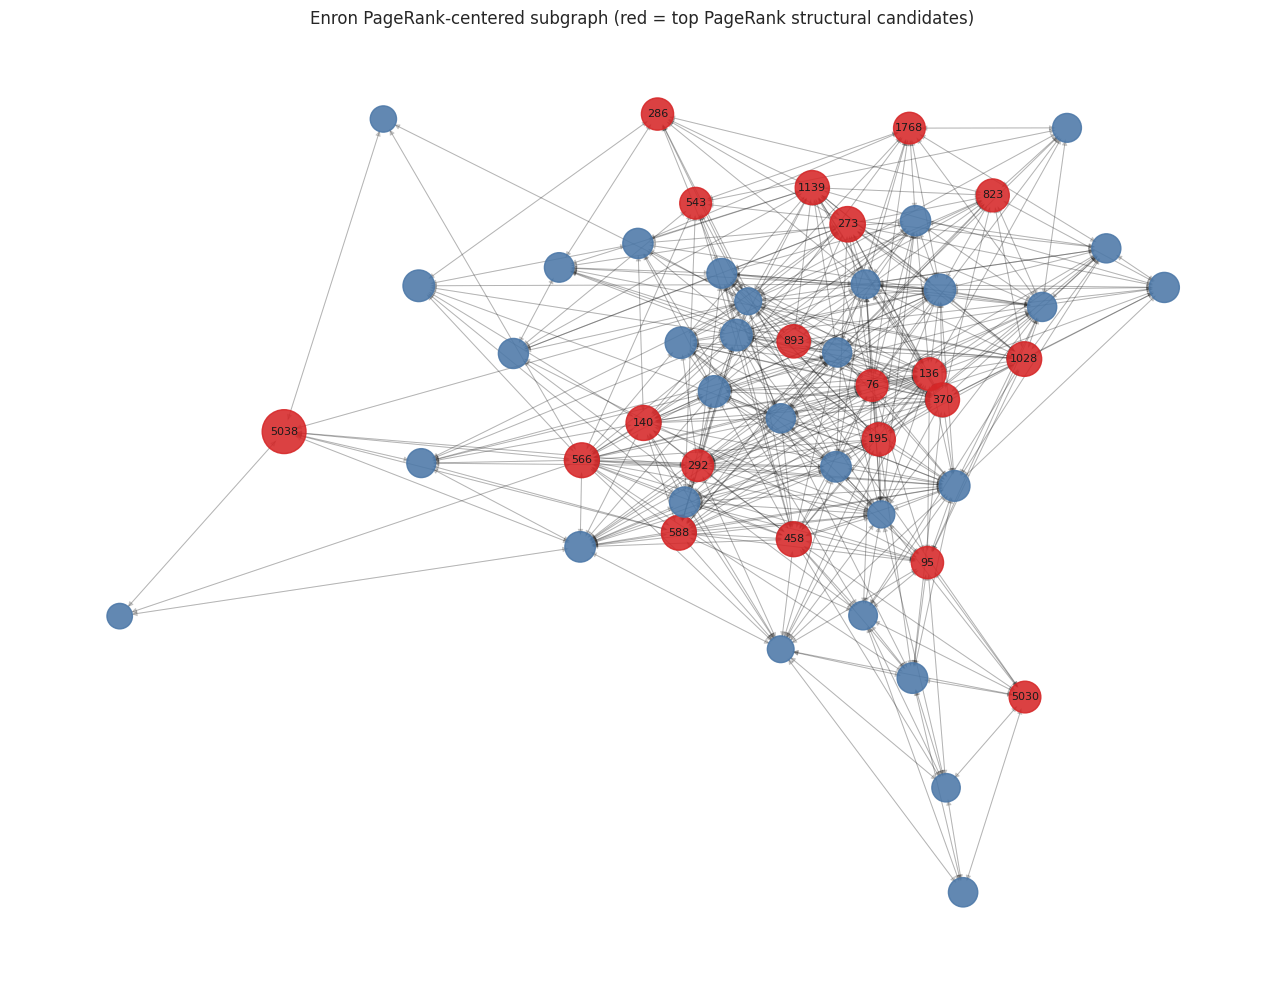

,full_graph_nodes,full_graph_edges,visualized_nodes,visualized_edges,top_pagerank_nodes_seeded,neighbors_per_top_node,figure_path
0,36692,367662,51,852,20,8,exports/figures/part_c_enron_pagerank_subgraph...


In [8]:
TOP_PAGERANK_FOR_VIS = 20
NEIGHBORS_PER_TOP_NODE = 8
pagerank_column = "pagerank"
top_pagerank_nodes = centrality_df.sort_values(pagerank_column, ascending=False).head(TOP_PAGERANK_FOR_VIS)["node_id"].tolist()
subgraph_nodes = set(top_pagerank_nodes)
for node in top_pagerank_nodes:
    neighbors = set(G.predecessors(node)) | set(G.successors(node))
    ranked_neighbors = sorted(neighbors, key=lambda n: G.degree(n), reverse=True)[:NEIGHBORS_PER_TOP_NODE]
    subgraph_nodes.update(ranked_neighbors)
vis_graph = G.subgraph(subgraph_nodes).copy()
vis_scores = centrality_df.set_index("node_id")[pagerank_column].to_dict()
node_sizes = [250 + 7000 * math.sqrt(vis_scores.get(node, 0.0)) for node in vis_graph.nodes()]
node_colors = ["#d62728" if node in top_pagerank_nodes else "#4c78a8" for node in vis_graph.nodes()]

plt.figure(figsize=(13, 10))
pos = nx.spring_layout(vis_graph.to_undirected(), seed=RANDOM_SEED, k=0.55)
nx.draw_networkx_edges(vis_graph, pos, alpha=0.18, arrows=True, arrowsize=8, width=0.7)
nx.draw_networkx_nodes(vis_graph, pos, node_size=node_sizes, node_color=node_colors, alpha=0.88)
labels = {node: str(node) for node in top_pagerank_nodes if node in vis_graph}
nx.draw_networkx_labels(vis_graph, pos, labels=labels, font_size=8)
plt.title("Enron PageRank-centered subgraph (red = top PageRank structural candidates)")
plt.axis("off")
vis_path = FIGURES_DIR / "part_c_enron_pagerank_subgraph.png"
plt.tight_layout()
plt.savefig(vis_path, dpi=180, bbox_inches="tight")
plt.show()

vis_summary = pd.DataFrame([
    {
        "full_graph_nodes": G.number_of_nodes(),
        "full_graph_edges": G.number_of_edges(),
        "visualized_nodes": vis_graph.number_of_nodes(),
        "visualized_edges": vis_graph.number_of_edges(),
        "top_pagerank_nodes_seeded": TOP_PAGERANK_FOR_VIS,
        "neighbors_per_top_node": NEIGHBORS_PER_TOP_NODE,
        "figure_path": str(vis_path.relative_to(PROJECT_ROOT)),
    }
])
display(vis_summary)


**Interpretation.** The visualization shows a PageRank-centered part of the Enron communication graph. Red nodes are structural manager candidates by PageRank, while blue nodes are nearby high-degree communication neighbors. This is a topology visualization, not proof of job title.

### How I solved this task

I selected the top PageRank nodes, added a fixed number of their strongest neighbors, drew the resulting subgraph, scaled node size by PageRank, and highlighted top PageRank nodes in red.

**Limitations.** The graph is anonymized numeric topology, so the visualization cannot show names or email addresses. The highlighted nodes are centrality candidates, not verified managers.


## C1.6 Discussion

**Requirement.** Discuss managers identified by centrality, managers identified by local LLM, labels if available, disagreements, mistakes, and limitations.

**Method.** I compare the three centrality rankings with the local LLM classifications and role summaries. Since manager labels are unavailable and the SNAP numeric node IDs cannot be mapped to maildir users, I focus on qualitative agreement, disagreement, and limitations rather than precision@10.

**Why this method.** A useful manager-detection notebook should not overclaim. Here, the strongest completed evidence is topology centrality; the email-content LLM workflow is prepared but blocked by missing local inference tooling.


In [9]:
centrality_top10_summary = []
for algorithm, table in top10_tables.items():
    centrality_top10_summary.append({
        "algorithm": algorithm,
        "top10_node_ids": table["node_id"].tolist(),
    })
centrality_top10_summary_df = pd.DataFrame(centrality_top10_summary)
classification_counts = llm_results_df["normalized_classification"].value_counts().rename_axis("normalized_classification").reset_index(name="count")
llm_status_summary = pd.DataFrame([
    {
        "local_llm_tool": LOCAL_LLM_TOOL,
        "local_llm_model": LOCAL_LLM_MODEL,
        "llm_outputs_loaded": len(llm_results_df),
        "users_analyzed_with_llm": llm_results_df["mailbox_user"].tolist(),
        "manager_like_users_from_llm": manager_like_users,
        "uncertain_users_from_llm": uncertain_users,
        "manager_labels_available": False,
        "precision_at_10_status": "not computed: no manager labels selected",
    }
])
display(centrality_top10_summary_df)
display(classification_counts)
display(llm_status_summary)

summary = {
    "enron_files_used": [str(ENRON_GRAPH_PATH.relative_to(PROJECT_ROOT)), str(ENRON_MAIL_ARCHIVE.relative_to(PROJECT_ROOT))],
    "centrality_algorithms_used": list(algorithm_map.keys()),
    "top10_results": {algorithm: table["node_id"].tolist() for algorithm, table in top10_tables.items()},
    "labels_available": False,
    "precision_at_10_status": "not computed because ENRON_MANAGER_LABELS_PATH_IF_AVAILABLE = NONE",
    "local_llm_tool": LOCAL_LLM_TOOL,
    "local_llm_model": LOCAL_LLM_MODEL,
    "llm_outputs_cache": str(llm_cache.relative_to(PROJECT_ROOT)),
    "llm_users_analyzed": llm_results_df["mailbox_user"].tolist(),
    "llm_normalized_classification_counts": classification_counts.to_dict(orient="records"),
    "llm_manager_like_users": manager_like_users,
    "llm_uncertain_users": uncertain_users,
    "figure": str(vis_path.relative_to(PROJECT_ROOT)),
}
summary_path = DATA_PROCESSED / "part_c_summary.json"
summary_path.write_text(json.dumps(summary, indent=2, default=str))
print(json.dumps(summary, indent=2, default=str))
print(f"Summary written to {summary_path.relative_to(PROJECT_ROOT)}")


,algorithm,top10_node_ids
0,PageRank,"[5038, 273, 140, 458, 588, 566, 1028, 1139, 37..."
1,Betweenness Centrality,"[5038, 140, 566, 823, 588, 273, 46, 893, 195, ..."
2,HITS Authority Score,"[136, 195, 76, 370, 1028, 273, 734, 416, 175, ..."


,normalized_classification,count
0,uncertain,5
1,non-manager,4
2,manager,1


,local_llm_tool,local_llm_model,llm_outputs_loaded,users_analyzed_with_llm,manager_like_users_from_llm,uncertain_users_from_llm,manager_labels_available,precision_at_10_status
0,Ollama,qwen2.5:7b-instruct,10,"[dasovich-j, kaminski-v, kean-s, jones-t, mann...",[kean-s],"[dasovich-j, mann-k, shackleton-s, taylor-m, n...",False,not computed: no manager labels selected


{
  "enron_files_used": [
    "data/raw/enron/email-Enron.txt.gz",
    "data/raw/enron/enron_mail_20150507.tar.gz"
  ],
  "centrality_algorithms_used": [
    "PageRank",
    "Betweenness Centrality",
    "HITS Authority Score"
  ],
  "top10_results": {
    "PageRank": [
      5038,
      273,
      140,
      458,
      588,
      566,
      1028,
      1139,
      370,
      893
    ],
    "Betweenness Centrality": [
      5038,
      140,
      566,
      823,
      588,
      273,
      46,
      893,
      195,
      1139
    ],
    "HITS Authority Score": [
      136,
      195,
      76,
      370,
      1028,
      273,
      734,
      416,
      175,
      292
    ]
  },
  "labels_available": false,
  "precision_at_10_status": "not computed because ENRON_MANAGER_LABELS_PATH_IF_AVAILABLE = NONE",
  "local_llm_tool": "Ollama",
  "local_llm_model": "qwen2.5:7b-instruct",
  "llm_outputs_cache": "data/processed/part_c_llm_outputs.json",
  "llm_users_analyzed": [
    "dasovich-j",
 

**Interpretation.** PageRank, approximate betweenness, and HITS authority produce structural candidate lists from the anonymized SNAP topology graph. The local LLM outputs provide separate mailbox-level evidence about likely managerial behavior and roles. Because manager labels are unavailable, these methods cannot be scored with precision@10. Because graph node IDs cannot be mapped to mailbox users, centrality and LLM evidence should be compared qualitatively rather than treated as the same ranked list.

### How I solved this task

I collected the top-10 results from each centrality algorithm, recorded the label status, loaded local Ollama classification and role-summary outputs for selected mailbox users, saved a compact summary JSON, and stated the mapping and label limitations clearly.

**Limitations.** The largest limitation is the missing identity mapping between SNAP numeric nodes and maildir users. The second is missing ground-truth manager labels, which prevents precision@10 and makes the LLM analysis qualitative.

# Optional Practice - Components, Reciprocity, Communities, and Chess Reference

# Optional Practice - Components, Reciprocity, Communities, and Chess Reference

This notebook implements the optional practice tasks using the manual selections in `docs/optional_practice_instructions.md`:

- Connected components: Bitcoin Network (Part B)
- Maximal strongly connected component: Bitcoin Network (Part B)
- Reciprocal links: Bitcoin Network (Part B)
- Communities: The Wolf of Wall Street Character Network (Part A)
- Community detection method: Greedy Modularity Communities
- Chess extension: already completed in Part A

I reuse the processed Part B Bitcoin edge cache and the Part A Movie Dynamics loader approach so I do not rerun expensive preprocessing pipelines. The Bitcoin analysis uses the same sampled working graph created in Part B: directed links among the 5,000 most active endpoint IDs from the first 250,000 streamed Bitcoin rows. That means all Bitcoin results below describe the Part B working graph, not the complete raw Bitcoin archive.


## Setup and shared helpers

This cell imports the libraries, defines project paths, checks that the required cached files exist, and loads the two selected networks. The Bitcoin graph is directed because each edge has a source and destination. The movie graph is undirected because character interactions do not have a direction in the Movie Dynamics JSON.


In [1]:
from pathlib import Path
import json
import math
import zipfile

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from networkx.readwrite import json_graph

def graph_with_export_safe_attributes(graph):
    export_graph = graph.copy()
    for _, _, attrs in export_graph.edges(data=True):
        for key, value in list(attrs.items()):
            if isinstance(value, pd.Timestamp):
                attrs[key] = value.isoformat() if not pd.isna(value) else ""
    return export_graph

RANDOM_SEED = 42
ROOT = Path.cwd()
if not (ROOT / "AGENTS.md").exists():
    ROOT = ROOT.parent
DATA_PROCESSED = ROOT / "data" / "processed"
DATA_RAW = ROOT / "data" / "raw"
FIGURES = ROOT / "exports" / "figures"
CYTOSCAPE = ROOT / "exports" / "cytoscape"
GEPHI = ROOT / "exports" / "gephi"

for folder in [FIGURES, CYTOSCAPE, GEPHI]:
    folder.mkdir(parents=True, exist_ok=True)

bitcoin_edges_cache = DATA_PROCESSED / "part_b_bitcoin_top5000_model_edges.parquet"
movie_zip_path = DATA_RAW / "movie_dynamics" / "movie-dynamics.zip"
wolf_member = "moviedynamics/2013_The_Wolf_of_Wall_Street.json"

missing = [str(path) for path in [bitcoin_edges_cache, movie_zip_path] if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required optional practice inputs:\n" + "\n".join(missing))

bitcoin_edges = pd.read_parquet(bitcoin_edges_cache).copy()
bitcoin_edges["src"] = bitcoin_edges["src"].astype(str)
bitcoin_edges["dst"] = bitcoin_edges["dst"].astype(str)

bitcoin_graph = nx.from_pandas_edgelist(
    bitcoin_edges,
    source="src",
    target="dst",
    edge_attr=["count", "mindate", "maxdate"],
    create_using=nx.DiGraph(),
)

with zipfile.ZipFile(movie_zip_path) as zf:
    with zf.open(wolf_member) as fp:
        wolf_data = json.load(fp)
wolf_graph = json_graph.node_link_graph(wolf_data, edges="links")
if wolf_graph.is_directed():
    wolf_graph = wolf_graph.to_undirected()

summary = pd.DataFrame([
    {
        "network": "Bitcoin Network working graph from Part B",
        "local_input": str(bitcoin_edges_cache.relative_to(ROOT)),
        "nodes": bitcoin_graph.number_of_nodes(),
        "edges": bitcoin_graph.number_of_edges(),
        "directed": nx.is_directed(bitcoin_graph),
    },
    {
        "network": "The Wolf of Wall Street character network from Part A",
        "local_input": f"{movie_zip_path.relative_to(ROOT)}::{wolf_member}",
        "nodes": wolf_graph.number_of_nodes(),
        "edges": wolf_graph.number_of_edges(),
        "directed": nx.is_directed(wolf_graph),
    },
])
display(summary)
print(f"Bitcoin cache loaded: {bitcoin_edges_cache.relative_to(ROOT)}")
print(f"Movie graph loaded: {wolf_member}")


,network,local_input,nodes,edges,directed
0,Bitcoin Network working graph from Part B,data/processed/part_b_bitcoin_top5000_model_ed...,3462,6294,True
1,The Wolf of Wall Street character network from...,data/raw/movie_dynamics/movie-dynamics.zip::mo...,49,297,False


Bitcoin cache loaded: data/processed/part_b_bitcoin_top5000_model_edges.parquet
Movie graph loaded: moviedynamics/2013_The_Wolf_of_Wall_Street.json


## 1. Connected Components Distribution - Bitcoin Network

**Requirement.** Use the selected Bitcoin network, compute and visualize the component size distribution, and explain giant-component behavior.

**Method.** The Bitcoin graph is directed, so there are two possible meanings of connected component. For this task I use **weakly connected components**: I temporarily ignore edge direction and ask which nodes are connected by any chain of transactions. This is the right view for giant-component behavior because it measures whether the sampled transaction network is mostly one connected mass, even if money does not flow both ways along every path.

**Why this method.** Strong components are stricter and are handled in the next task. Weak components give a clearer answer to the optional question: whether most nodes belong to one large component or whether the graph is fragmented into many islands.


,number_of_weak_components,largest_component_size,total_nodes,largest_component_share,median_component_size,single_node_components
0,51,3346,3462,0.966493,2.0,0


,component_size,component_count
0,2,42
1,3,5
2,5,2
3,7,1
4,3346,1


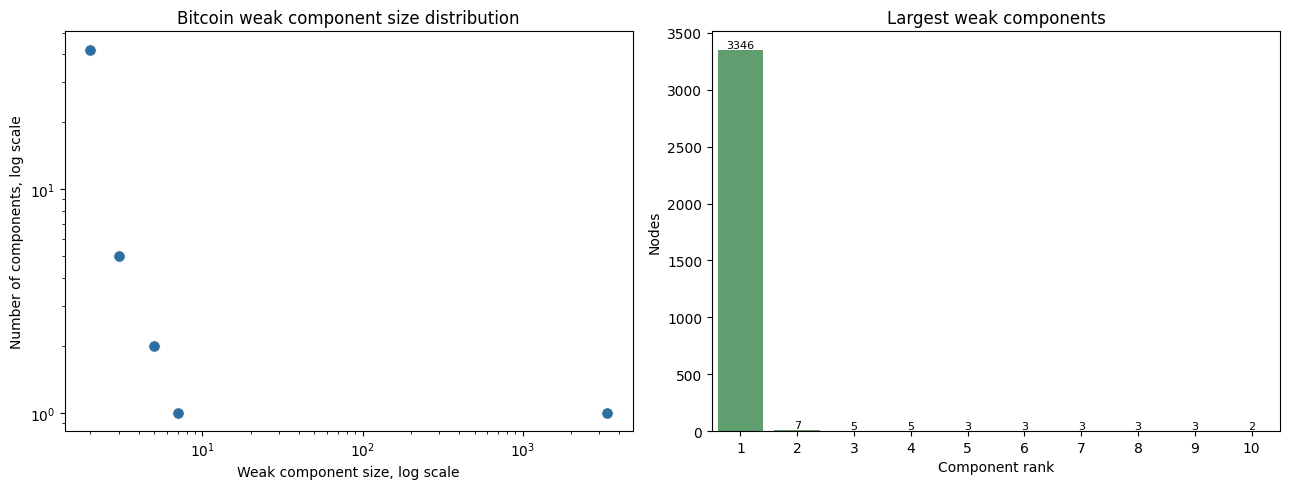

Saved figure: exports/figures/optional_bitcoin_weak_component_distribution.png


In [2]:
weak_components = sorted(nx.weakly_connected_components(bitcoin_graph), key=len, reverse=True)
weak_sizes = pd.Series([len(component) for component in weak_components], name="component_size")
weak_summary = pd.DataFrame({
    "number_of_weak_components": [len(weak_components)],
    "largest_component_size": [int(weak_sizes.iloc[0])],
    "total_nodes": [bitcoin_graph.number_of_nodes()],
    "largest_component_share": [float(weak_sizes.iloc[0] / bitcoin_graph.number_of_nodes())],
    "median_component_size": [float(weak_sizes.median())],
    "single_node_components": [int((weak_sizes == 1).sum())],
})

display(weak_summary)
display(weak_sizes.value_counts().sort_index().rename_axis("component_size").reset_index(name="component_count").head(20))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_sizes = weak_sizes.value_counts().sort_index().reset_index()
plot_sizes.columns = ["component_size", "component_count"]
sns.scatterplot(data=plot_sizes, x="component_size", y="component_count", ax=axes[0], s=70, color="#2f6f9f")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Bitcoin weak component size distribution")
axes[0].set_xlabel("Weak component size, log scale")
axes[0].set_ylabel("Number of components, log scale")

top_count = min(10, len(weak_sizes))
top_weak = pd.DataFrame({"rank": range(1, top_count + 1), "component_size": weak_sizes.head(top_count).to_list()})
sns.barplot(data=top_weak, x="rank", y="component_size", ax=axes[1], color="#55a868")
axes[1].set_title("Largest weak components")
axes[1].set_xlabel("Component rank")
axes[1].set_ylabel("Nodes")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.0f", fontsize=8)

fig.tight_layout()
components_fig = FIGURES / "optional_bitcoin_weak_component_distribution.png"
fig.savefig(components_fig, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved figure: {components_fig.relative_to(ROOT)}")


**Interpretation.** The weak component distribution is dominated by one giant component. In this Part B working graph, the largest weak component contains almost all nodes, while the remaining components are tiny. That means the sampled Bitcoin transaction network has one main connected transaction region plus a long tail of small disconnected groups. This is common in transaction and communication networks: once direction is ignored, many accounts become connected through shared transaction chains.

### How I solved this task

I loaded the cached Part B Bitcoin edge table, built a directed NetworkX graph, computed weakly connected components with `nx.weakly_connected_components`, summarized their sizes, and saved a log-scale component-size plot. I used the cached Part B working graph to avoid rerunning the expensive archive streaming and active-node filtering.

**Limitations.** This is not the full Bitcoin network. It is the Part B sampled working graph, so the giant component share can be affected by the active-node filtering and by using only the first streamed rows from the archive. Weak components also ignore edge direction, so they do not prove that value or influence can travel both ways.


## 2. Maximal Strongly Connected Component - Bitcoin Network

**Requirement.** Use the selected Bitcoin network, extract the largest strongly connected component, visualize it, and export it if appropriate.

**Method.** A strongly connected component in a directed graph is a set of nodes where every node can reach every other node by following directed edges. I compute all strongly connected components and then select the largest one. This largest SCC is the maximal mutually reachable core of the sampled Bitcoin graph.

**Why this method.** The SCC view is stricter than the weak component view. It tells us whether directed transaction paths form a cycle-rich core or whether most links are one-way and acyclic. Since the largest SCC here is small enough to inspect, I visualize and export the whole SCC.


,number_of_strong_components,largest_scc_size,largest_scc_edges,largest_scc_share_of_nodes,single_node_sccs
0,3443,17,23,0.00491,3439


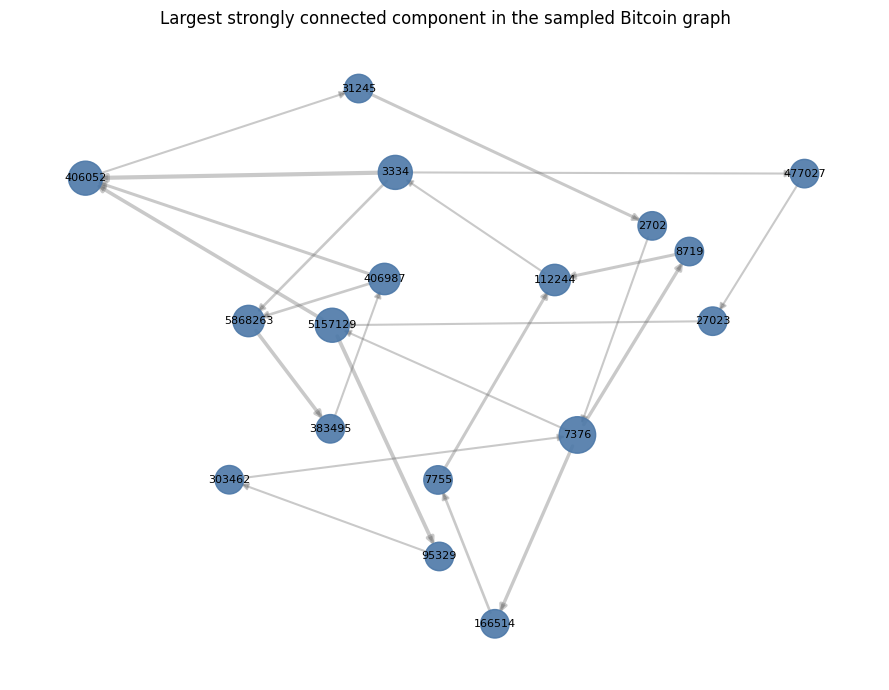

Saved figure: exports/figures/optional_bitcoin_largest_scc.png
Exported GraphML: exports/cytoscape/optional_bitcoin_largest_scc.graphml
Exported GEXF: exports/gephi/optional_bitcoin_largest_scc.gexf


In [3]:
strong_components = sorted(nx.strongly_connected_components(bitcoin_graph), key=len, reverse=True)
largest_scc_nodes = strong_components[0]
largest_scc = bitcoin_graph.subgraph(largest_scc_nodes).copy()

scc_sizes = pd.Series([len(component) for component in strong_components], name="scc_size")
scc_summary = pd.DataFrame({
    "number_of_strong_components": [len(strong_components)],
    "largest_scc_size": [largest_scc.number_of_nodes()],
    "largest_scc_edges": [largest_scc.number_of_edges()],
    "largest_scc_share_of_nodes": [largest_scc.number_of_nodes() / bitcoin_graph.number_of_nodes()],
    "single_node_sccs": [int((scc_sizes == 1).sum())],
})

display(scc_summary)

deg = dict(largest_scc.degree())
weighted = dict(largest_scc.degree(weight="count"))
for node in largest_scc.nodes:
    largest_scc.nodes[node]["degree"] = int(deg.get(node, 0))
    largest_scc.nodes[node]["weighted_degree"] = float(weighted.get(node, 0))
    largest_scc.nodes[node]["label"] = str(node)

scc_export_graph = graph_with_export_safe_attributes(largest_scc)
scc_graphml = CYTOSCAPE / "optional_bitcoin_largest_scc.graphml"
scc_gexf = GEPHI / "optional_bitcoin_largest_scc.gexf"
nx.write_graphml(scc_export_graph, scc_graphml)
nx.write_gexf(scc_export_graph, scc_gexf)

fig, ax = plt.subplots(figsize=(9, 7))
pos = nx.spring_layout(largest_scc, seed=RANDOM_SEED, k=0.9)
node_sizes = [240 + 90 * deg.get(node, 0) for node in largest_scc.nodes]
edge_widths = [0.8 + math.log1p(largest_scc.edges[edge].get("count", 1)) for edge in largest_scc.edges]
nx.draw_networkx_edges(largest_scc, pos, ax=ax, alpha=0.35, arrows=True, arrowsize=10, width=edge_widths, edge_color="#666666")
nx.draw_networkx_nodes(largest_scc, pos, ax=ax, node_size=node_sizes, node_color="#4c78a8", alpha=0.9)
nx.draw_networkx_labels(largest_scc, pos, ax=ax, font_size=8)
ax.set_title("Largest strongly connected component in the sampled Bitcoin graph")
ax.axis("off")
fig.tight_layout()
scc_fig = FIGURES / "optional_bitcoin_largest_scc.png"
fig.savefig(scc_fig, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved figure: {scc_fig.relative_to(ROOT)}")
print(f"Exported GraphML: {scc_graphml.relative_to(ROOT)}")
print(f"Exported GEXF: {scc_gexf.relative_to(ROOT)}")


**Interpretation.** The largest weak component is very large, but the largest strongly connected component is much smaller. This means the graph is connected mainly through one-way transaction paths. Only a small core has full directed reachability, where each selected node can reach the others by following transaction directions.

### How I solved this task

I computed strongly connected components with `nx.strongly_connected_components`, selected the largest component, made a subgraph, added simple degree attributes, drew it with a spring layout, and exported it to GraphML and GEXF for Cytoscape or Gephi. I exported the whole largest SCC because it is small enough to handle directly.

**Limitations.** Strong reachability depends on the sampled edge set. Missing earlier/later transactions from the full archive can break directed cycles, so the SCC size should be interpreted as a property of the Part B working graph rather than the complete Bitcoin network.


## 3. Reciprocal Links - Bitcoin Network

**Requirement.** Use the selected Bitcoin network, construct a reciprocal-links subgraph, provide summary statistics, and visualize it.

**Method.** A reciprocal directed link exists when both `(u, v)` and `(v, u)` appear in the graph. I find every unordered node pair with edges in both directions and keep both directed edges in a reciprocal subgraph.

**Why this method.** Reciprocity is useful in directed transaction networks because it separates one-way interactions from pairs with repeated two-way exchange. A reciprocal subgraph can reveal small relationship structures that are hidden in the larger directed network.


,reciprocal_node_count,reciprocal_directed_edge_count,reciprocal_pair_count,share_of_all_directed_edges_in_reciprocal_pairs
0,6,6,3,0.000953


,src,dst,count,mindate,maxdate
3,1906,365,10,2012-09-24 03:58:35,2013-04-08 00:13:48
1,2169,71,24,2012-10-29 07:39:00,2013-04-08 18:23:33
5,3529838,9635,1,2012-12-28 17:26:14,2012-12-28 17:26:14
2,365,1906,1,2013-04-10 05:19:34,2013-04-10 05:19:34
0,71,2169,51,2012-10-27 16:30:47,2013-04-09 20:10:30
4,9635,3529838,1,2013-01-01 22:01:16,2013-01-01 22:01:16


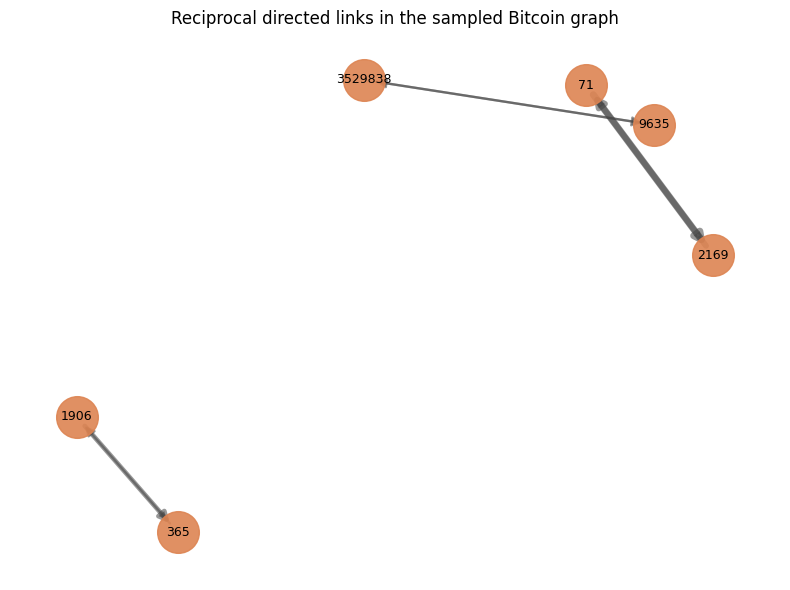

Saved figure: exports/figures/optional_bitcoin_reciprocal_links.png
Exported GraphML: exports/cytoscape/optional_bitcoin_reciprocal_links.graphml
Exported GEXF: exports/gephi/optional_bitcoin_reciprocal_links.gexf


In [4]:
reciprocal_pairs = []
seen_pairs = set()
for u, v in bitcoin_graph.edges():
    pair_key = tuple(sorted([u, v]))
    if u != v and pair_key not in seen_pairs and bitcoin_graph.has_edge(v, u):
        reciprocal_pairs.append((u, v))
        seen_pairs.add(pair_key)

reciprocal_graph = nx.DiGraph()
for u, v in reciprocal_pairs:
    reciprocal_graph.add_node(u)
    reciprocal_graph.add_node(v)
    reciprocal_graph.add_edge(u, v, **bitcoin_graph.edges[u, v])
    reciprocal_graph.add_edge(v, u, **bitcoin_graph.edges[v, u])

reciprocal_stats = pd.DataFrame({
    "reciprocal_node_count": [reciprocal_graph.number_of_nodes()],
    "reciprocal_directed_edge_count": [reciprocal_graph.number_of_edges()],
    "reciprocal_pair_count": [len(reciprocal_pairs)],
    "share_of_all_directed_edges_in_reciprocal_pairs": [reciprocal_graph.number_of_edges() / bitcoin_graph.number_of_edges()],
})
display(reciprocal_stats)

reciprocal_edge_rows = []
for u, v in reciprocal_graph.edges():
    reciprocal_edge_rows.append({
        "src": u,
        "dst": v,
        "count": reciprocal_graph.edges[u, v].get("count", np.nan),
        "mindate": reciprocal_graph.edges[u, v].get("mindate", pd.NaT),
        "maxdate": reciprocal_graph.edges[u, v].get("maxdate", pd.NaT),
    })
display(pd.DataFrame(reciprocal_edge_rows).sort_values(["src", "dst"]))

for node in reciprocal_graph.nodes:
    reciprocal_graph.nodes[node]["label"] = str(node)
    reciprocal_graph.nodes[node]["degree"] = int(reciprocal_graph.degree(node))

reciprocal_export_graph = graph_with_export_safe_attributes(reciprocal_graph)
reciprocal_graphml = CYTOSCAPE / "optional_bitcoin_reciprocal_links.graphml"
reciprocal_gexf = GEPHI / "optional_bitcoin_reciprocal_links.gexf"
nx.write_graphml(reciprocal_export_graph, reciprocal_graphml)
nx.write_gexf(reciprocal_export_graph, reciprocal_gexf)

fig, ax = plt.subplots(figsize=(8, 6))
if reciprocal_graph.number_of_nodes() > 0:
    pos = nx.spring_layout(reciprocal_graph, seed=RANDOM_SEED, k=1.2)
    widths = [1.0 + math.log1p(reciprocal_graph.edges[edge].get("count", 1)) for edge in reciprocal_graph.edges]
    nx.draw_networkx_edges(reciprocal_graph, pos, ax=ax, arrows=True, arrowsize=14, width=widths, alpha=0.55, edge_color="#444444")
    nx.draw_networkx_nodes(reciprocal_graph, pos, ax=ax, node_size=900, node_color="#dd8452", alpha=0.9)
    nx.draw_networkx_labels(reciprocal_graph, pos, ax=ax, font_size=9)
else:
    ax.text(0.5, 0.5, "No reciprocal links found", ha="center", va="center")
ax.set_title("Reciprocal directed links in the sampled Bitcoin graph")
ax.axis("off")
fig.tight_layout()
reciprocal_fig = FIGURES / "optional_bitcoin_reciprocal_links.png"
fig.savefig(reciprocal_fig, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved figure: {reciprocal_fig.relative_to(ROOT)}")
print(f"Exported GraphML: {reciprocal_graphml.relative_to(ROOT)}")
print(f"Exported GEXF: {reciprocal_gexf.relative_to(ROOT)}")


**Interpretation.** The reciprocal subgraph is very small compared with the full sampled Bitcoin graph. Most directed Bitcoin links in this working graph do not have a matching reverse edge, which is consistent with a transaction network where many source-destination relationships are one-way in the sampled period.

### How I solved this task

I checked every directed Bitcoin edge for the reverse edge, kept each reciprocal pair once, then added both directions to a new directed subgraph. I displayed summary statistics, listed the reciprocal edges, drew the subgraph, and exported it for external graph tools.

**Limitations.** A missing reverse edge in the sample does not prove the pair never transacted in both directions in the full dataset. It only means the reverse direction is absent from the Part B working graph after sampling and active-node filtering.


## 4. Communities - The Wolf of Wall Street Character Network

**Requirement.** Use the selected Wolf of Wall Street character network, apply **Greedy Modularity Communities exactly**, identify the second most central vertex in every detected community, and explain why the result is meaningful.

**Method.** Greedy modularity communities start with each node in its own community and repeatedly merge communities when the merge improves modularity. Modularity is high when there are many edges inside communities and fewer edges between communities than expected by chance. After detecting communities, I compute weighted PageRank inside each community subgraph and select the second-ranked character.

**Why this method.** The assignment selected Greedy Modularity Communities exactly. It is appropriate here because the movie graph is small, undirected, and dense enough for community detection. The second most central character is useful because it avoids simply naming the obvious lead character in each group and instead highlights another important character in that local story cluster.


,community_id,size,internal_edges,density,most_central_vertex,most_central_pagerank,second_most_central_vertex,second_most_central_pagerank
0,1,24,91,0.329710,Jordan Belfort,0.291596,Donnie Azoff,0.156596
1,2,13,34,0.435897,Max Belfort,0.168943,Stratton Broker #2,0.128785
2,3,7,10,0.476190,Alden Kupferberg ('Sea Otter'),0.263966,SEC Attorney #1,0.208531
3,4,5,10,1.000000,Mark Hanna,0.244152,Brookville Police Officer #1,0.208886


Detected 4 communities with weighted modularity 0.068


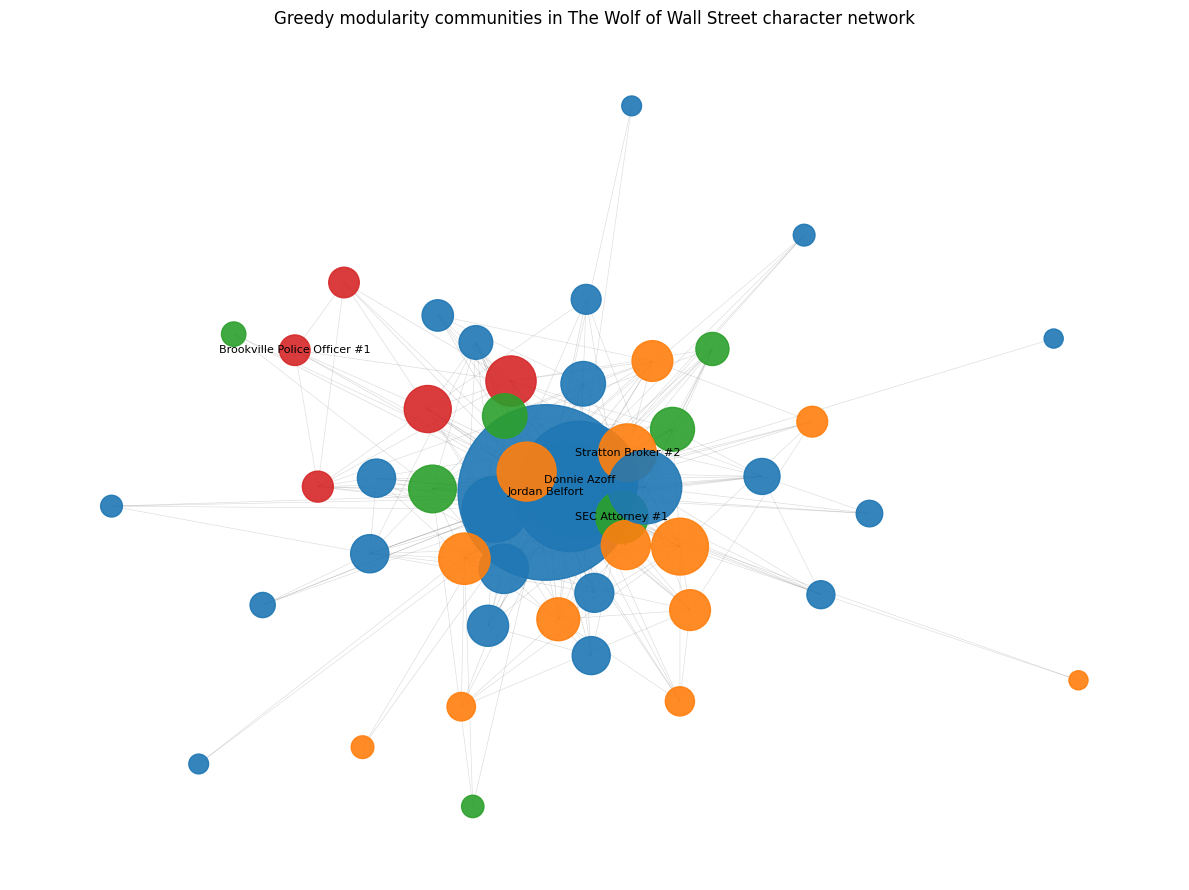

Saved figure: exports/figures/optional_wolf_greedy_modularity_communities.png
Exported GraphML: exports/cytoscape/optional_wolf_greedy_modularity_communities.graphml
Exported GEXF: exports/gephi/optional_wolf_greedy_modularity_communities.gexf


In [5]:
communities = list(nx.algorithms.community.greedy_modularity_communities(wolf_graph, weight="weight"))
communities = sorted(communities, key=len, reverse=True)

community_records = []
node_to_community = {}
for community_id, nodes in enumerate(communities, start=1):
    subgraph = wolf_graph.subgraph(nodes).copy()
    if subgraph.number_of_nodes() == 1:
        centrality = {next(iter(subgraph.nodes)): 1.0}
    else:
        centrality = nx.pagerank(subgraph, weight="weight")
    ranked = sorted(centrality.items(), key=lambda item: item[1], reverse=True)
    first = ranked[0]
    second = ranked[1] if len(ranked) > 1 else (None, np.nan)
    internal_edges = subgraph.number_of_edges()
    possible_edges = subgraph.number_of_nodes() * (subgraph.number_of_nodes() - 1) / 2
    density = internal_edges / possible_edges if possible_edges else 0.0
    community_records.append({
        "community_id": community_id,
        "size": subgraph.number_of_nodes(),
        "internal_edges": internal_edges,
        "density": density,
        "most_central_vertex": first[0],
        "most_central_pagerank": first[1],
        "second_most_central_vertex": second[0],
        "second_most_central_pagerank": second[1],
    })
    for node in nodes:
        node_to_community[node] = community_id

community_df = pd.DataFrame(community_records)
display(community_df)

modularity = nx.algorithms.community.modularity(wolf_graph, communities, weight="weight")
print(f"Detected {len(communities)} communities with weighted modularity {modularity:.3f}")

community_graph = wolf_graph.copy()
weighted_degree = dict(community_graph.degree(weight="weight"))
for node in community_graph.nodes:
    community_graph.nodes[node]["community"] = int(node_to_community[node])
    community_graph.nodes[node]["weighted_degree"] = float(weighted_degree.get(node, 0))
    community_graph.nodes[node]["label"] = str(node)

community_graphml = CYTOSCAPE / "optional_wolf_greedy_modularity_communities.graphml"
community_gexf = GEPHI / "optional_wolf_greedy_modularity_communities.gexf"
nx.write_graphml(community_graph, community_graphml)
nx.write_gexf(community_graph, community_gexf)

palette = sns.color_palette("tab10", n_colors=max(3, len(communities)))
node_colors = [palette[node_to_community[node] - 1] for node in wolf_graph.nodes]
node_sizes = [140 + 7 * weighted_degree.get(node, 0) for node in wolf_graph.nodes]
pos = nx.spring_layout(wolf_graph, seed=RANDOM_SEED, weight="weight", k=0.55)

fig, ax = plt.subplots(figsize=(12, 9))
edge_widths = [0.35 + 0.04 * math.log1p(wolf_graph.edges[edge].get("weight", 1)) for edge in wolf_graph.edges]
nx.draw_networkx_edges(wolf_graph, pos, ax=ax, width=edge_widths, alpha=0.22, edge_color="#555555")
nx.draw_networkx_nodes(wolf_graph, pos, ax=ax, node_size=node_sizes, node_color=node_colors, alpha=0.90)

labels = {}
important_nodes = set(community_df["second_most_central_vertex"].dropna()) | {"Jordan Belfort"}
for node in wolf_graph.nodes:
    if node in important_nodes:
        labels[node] = node
nx.draw_networkx_labels(wolf_graph, pos, labels=labels, ax=ax, font_size=8)

ax.set_title("Greedy modularity communities in The Wolf of Wall Street character network")
ax.axis("off")
fig.tight_layout()
community_fig = FIGURES / "optional_wolf_greedy_modularity_communities.png"
fig.savefig(community_fig, dpi=160, bbox_inches="tight")
plt.show()

print(f"Saved figure: {community_fig.relative_to(ROOT)}")
print(f"Exported GraphML: {community_graphml.relative_to(ROOT)}")
print(f"Exported GEXF: {community_gexf.relative_to(ROOT)}")


**Interpretation.** Greedy modularity separates the movie network into groups of characters that interact more heavily with one another than with the rest of the cast. The second most central vertex in each community is meaningful because it points to an important supporting character within that local group. For example, if the main character dominates one community, the second-ranked character helps explain who else anchors that part of the interaction structure.

### How I solved this task

I loaded the same Wolf of Wall Street graph used in Part A, ran `nx.algorithms.community.greedy_modularity_communities` with edge weights, calculated PageRank inside each detected community, and selected the second-highest PageRank node in each community. I then saved a community-colored visualization and exported the graph with a `community` node attribute.

**Limitations.** Greedy modularity is a structural algorithm, not a story-aware method. It only sees interaction edges and weights, so the detected communities may reflect scene co-appearance patterns rather than formal plot groups. Very small communities also make the idea of a second most central vertex less informative.


## 5. Chess Extension Reference

**Requirement.** Do not duplicate the Part A chess analysis. Briefly explain that the chess extension was already completed in Part A and reference that work.

**Explanation.** The manual selection says `DO_CHESS_EXTENSION_HERE_OR_IN_PART_A = PART_A`. I therefore do not rerun the large FICS chess analysis in this optional notebook. Part A already handled the large-graph safety requirement by streaming the first 200,000 chess interaction rows from `data/raw/chess/fics.tar.gz`, caching the sample at `data/processed/fics_interactions_first_200000.parquet`, identifying the top sampled players by interaction count, visualizing a small neighborhood subgraph, and exporting GraphML/GEXF files.

The relevant Part A outputs are:

- Figure: `exports/figures/a6_fics_sampled_top_players.png`
- Cytoscape export: `exports/cytoscape/fics_sampled_top_players.graphml`
- Gephi export: `exports/gephi/fics_sampled_top_players.gexf`

### How I solved this task

I followed the manual selection and treated chess as already completed in Part A. This avoids duplicating an expensive large-graph workflow and keeps this notebook focused on the optional Bitcoin and movie-network tasks.

**Limitations.** This section does not add new chess results. It only documents where the completed Part A chess extension can be found.


## Optional Practice Output Summary

This final cell records the generated figures and exports so the grader can find the outputs quickly.


In [6]:
created_outputs = [
    {"type": "figure", "path": FIGURES / "optional_bitcoin_weak_component_distribution.png"},
    {"type": "figure", "path": FIGURES / "optional_bitcoin_largest_scc.png"},
    {"type": "figure", "path": FIGURES / "optional_bitcoin_reciprocal_links.png"},
    {"type": "figure", "path": FIGURES / "optional_wolf_greedy_modularity_communities.png"},
    {"type": "cytoscape_export", "path": CYTOSCAPE / "optional_bitcoin_largest_scc.graphml"},
    {"type": "cytoscape_export", "path": CYTOSCAPE / "optional_bitcoin_reciprocal_links.graphml"},
    {"type": "cytoscape_export", "path": CYTOSCAPE / "optional_wolf_greedy_modularity_communities.graphml"},
    {"type": "gephi_export", "path": GEPHI / "optional_bitcoin_largest_scc.gexf"},
    {"type": "gephi_export", "path": GEPHI / "optional_bitcoin_reciprocal_links.gexf"},
    {"type": "gephi_export", "path": GEPHI / "optional_wolf_greedy_modularity_communities.gexf"},
]
output_df = pd.DataFrame([
    {"type": item["type"], "path": str(item["path"].relative_to(ROOT)), "exists": item["path"].exists()}
    for item in created_outputs
])
display(output_df)

optional_summary = {
    "bitcoin_input_cache": str(bitcoin_edges_cache.relative_to(ROOT)),
    "bitcoin_nodes": bitcoin_graph.number_of_nodes(),
    "bitcoin_edges": bitcoin_graph.number_of_edges(),
    "weak_components": len(weak_components),
    "largest_weak_component_size": int(weak_sizes.iloc[0]),
    "largest_scc_size": largest_scc.number_of_nodes(),
    "reciprocal_pair_count": len(reciprocal_pairs),
    "wolf_graph_member": wolf_member,
    "wolf_communities": len(communities),
    "wolf_modularity": float(modularity),
    "outputs": output_df.to_dict(orient="records"),
}
summary_path = DATA_PROCESSED / "optional_practice_summary.json"
summary_path.write_text(json.dumps(optional_summary, indent=2))
print(f"Summary written to {summary_path.relative_to(ROOT)}")


,type,path,exists
0,figure,exports/figures/optional_bitcoin_weak_componen...,True
1,figure,exports/figures/optional_bitcoin_largest_scc.png,True
2,figure,exports/figures/optional_bitcoin_reciprocal_li...,True
3,figure,exports/figures/optional_wolf_greedy_modularit...,True
4,cytoscape_export,exports/cytoscape/optional_bitcoin_largest_scc...,True
5,cytoscape_export,exports/cytoscape/optional_bitcoin_reciprocal_...,True
6,cytoscape_export,exports/cytoscape/optional_wolf_greedy_modular...,True
7,gephi_export,exports/gephi/optional_bitcoin_largest_scc.gexf,True
8,gephi_export,exports/gephi/optional_bitcoin_reciprocal_link...,True
9,gephi_export,exports/gephi/optional_wolf_greedy_modularity_...,True


Summary written to data/processed/optional_practice_summary.json
